In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt



import joblib
from sklearn.preprocessing import MinMaxScaler

2026-02-05 06:55:41.124231: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770303341.348371 1254147 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770303341.403001 1254147 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770303342.043086 1254147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770303342.043122 1254147 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770303342.043126 1254147 computation_placer.cc:177] computation placer alr

In [2]:

model_samp = str(240700000)
print("modules loaded")


modules loaded


In [3]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    ref_d = file['density'][:]

In [4]:
#### test file #######
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_dmc_mix_mean_0000081895.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [5]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [6]:
def encode_voxel_to_rgb(test_d, save_path='slice_scalers.npz'):
    """
    Normalize each XY slice independently and encode to RGB (repeated channels).
    Saves (min, max) for each slice for reconstruction.
    
    Returns:
        rgb_volume: (64, 64, 64, 3)
    """
    rgb_volume = np.zeros((64, 64, 64, 3), dtype=np.float32)
    mins = []
    maxs = []

    for i in range(64):
        slice_2d = test_d[i, :, :]
        s_min = float(slice_2d.min())
        s_max = float(slice_2d.max())

        if s_max == s_min:
            s_max = s_min + 1e-6  # Avoid divide-by-zero for flat slices

        normed = (slice_2d - s_min) / (s_max - s_min)
        rgb_volume[i, :, :, :] = np.stack([normed]*3, axis=-1)  # (64, 64, 3)

        mins.append(s_min)
        maxs.append(s_max)

    np.savez(save_path, mins=np.array(mins), maxs=np.array(maxs))
    return rgb_volume  # shape: (64, 64, 64, 3)


In [7]:
def decode_rgb_to_voxel(rgb_volume, save_path='slice_scalers.npz'):
    """
    Decode per-slice normalized RGB volume back into scalar 3D volume.
    Assumes all RGB channels are identical.
    
    Args:
        rgb_volume: shape (64, 64, 64, 3)
    """
    data = np.load(save_path)
    mins = data['mins']
    maxs = data['maxs']

    test_d = np.zeros((64, 64, 64), dtype=np.float32)

    for i in range(64):
        rgb_slice = rgb_volume[i]  # (64, 64, 3)
        gray = rgb_slice[:, :, 0]
        restored = gray * (maxs[i] - mins[i]) + mins[i]
        test_d[i] = restored

    return test_d


In [8]:
# Fully working 

################# CAE_full_3D #############
from keras.models import load_model
import keras

############# Nature #####################
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class RenormalizeToEight(tf.keras.layers.Layer):
    def call(self, x):
        total = tf.reduce_sum(x, axis=[1, 2, 3, 4], keepdims=True)
        return x / (total + 1e-8) * 8.0


@tf.keras.utils.register_keras_serializable()
def jensen_shannon_divergence_loss(y_true, y_pred):
    y_t = tf.cast(y_true, tf.float32)
    y_p = tf.cast(y_pred, tf.float32)

    y_t = tf.reshape(y_t, [tf.shape(y_t)[0], -1])
    y_p = tf.reshape(y_p, [tf.shape(y_p)[0], -1])

    y_t /= tf.reduce_sum(y_t, axis=1, keepdims=True) + 1e-8
    y_p /= tf.reduce_sum(y_p, axis=1, keepdims=True) + 1e-8

    m = 0.5 * (y_t + y_p)
    kl_true = tf.reduce_sum(y_t * tf.math.log((y_t + 1e-8) / (m + 1e-8)), axis=1)
    kl_pred = tf.reduce_sum(y_p * tf.math.log((y_p + 1e-8) / (m + 1e-8)), axis=1)
    return tf.reduce_mean(0.5 * (kl_true + kl_pred))
    
from keras.models import load_model
import keras
keras.config.enable_unsafe_deserialization()


def CAE_3D_test_pipeline(test_d, ref_d):
    # Encode
    test_rgb = test_d
    ref_rgb  = ref_d
    reshaped_arr = test_rgb.reshape(1,64, 64, 64, 1)
    
    denoised_rgb = CAE_3D_mod.predict(reshaped_arr)  # shape: (H, W, 3)
    



    # Reconstruct full 3D volume
    denoised_d = denoised_rgb.reshape(64,64,64)

    # --- Evaluation ---
    print("\n>>> Evaluation Metrics")
    jsd_noisy = jensen_shannon_divergence_loss(test_d,
        ref_d
    )
    jsd_denoised = jensen_shannon_divergence_loss(
        denoised_d,
        ref_d
    )

    norm_noisy = np.linalg.norm(test_d - ref_d)
    norm_denoised = np.linalg.norm(denoised_d - ref_d)

    print(f"2-norm (noisy vs ref):     {norm_noisy:.4f}")
    print(f"2-norm (denoised vs ref): {norm_denoised:.4f}")
    print(f"JSD   (noisy vs ref):     {jsd_noisy:.6f}")
    print(f"JSD   (denoised vs ref):  {jsd_denoised:.6f}")

    print(test_d.shape,denoised_d.shape,ref_d.shape)

    # --- Plot example slices ---
    slice_idx = 32
    plt.figure(figsize=(12, 6))
    titles = ['Noisy', 'Denoised', 'Reference']
    data = [test_d[slice_idx], denoised_d[slice_idx], ref_d[slice_idx]]
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(data[i], cmap='viridis')
        plt.title(f"{titles[i]} (z={slice_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
    return(denoised_d,jsd_denoised)


In [9]:
print("IMG 3D loaded")

IMG 3D loaded


In [10]:
model_sizes = [ 2385000 , 23930000, 240700000, 2336000000]

Found 33 noisy files.
Found 6 CAE_3D models.

=== Running model: 2336000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000121
(64, 64, 64) (64, 64, 64) (64, 64, 64)


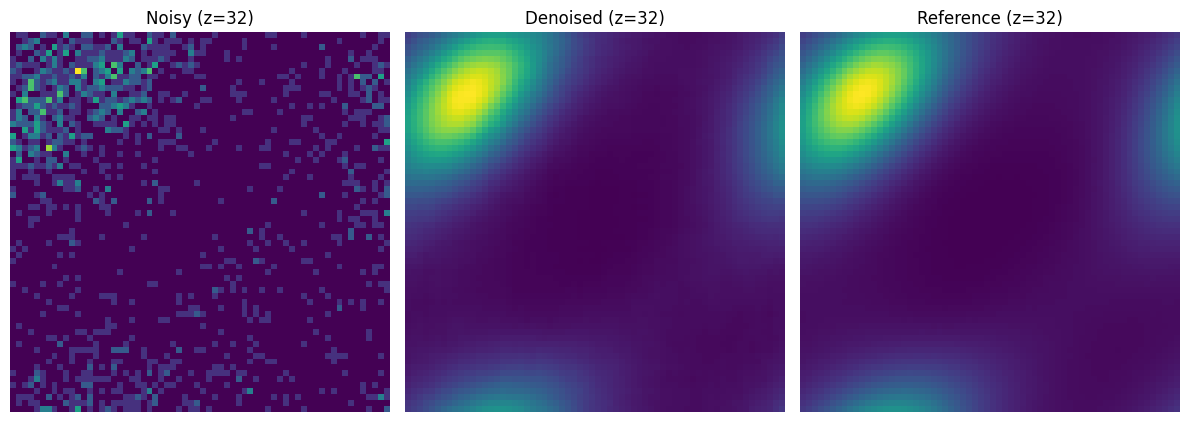

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000120
(64, 64, 64) (64, 64, 64) (64, 64, 64)


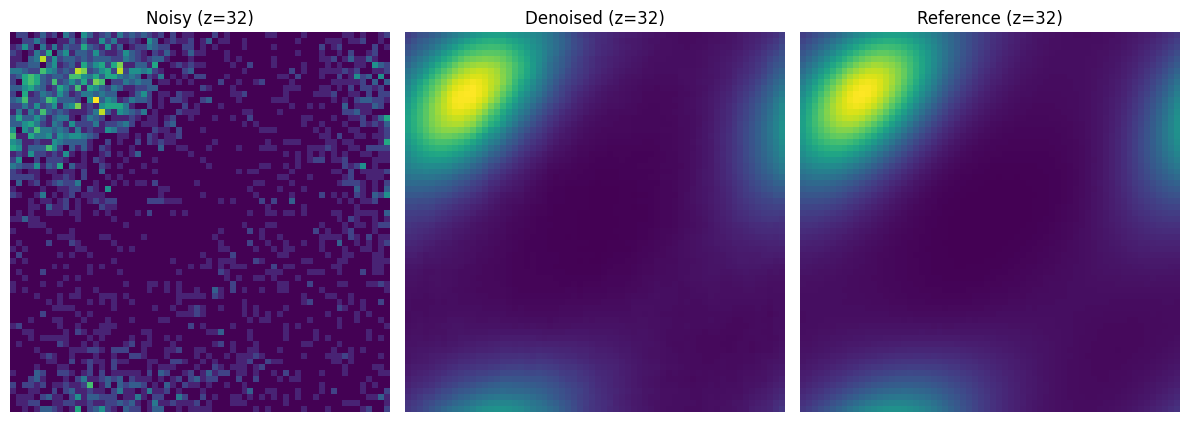

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


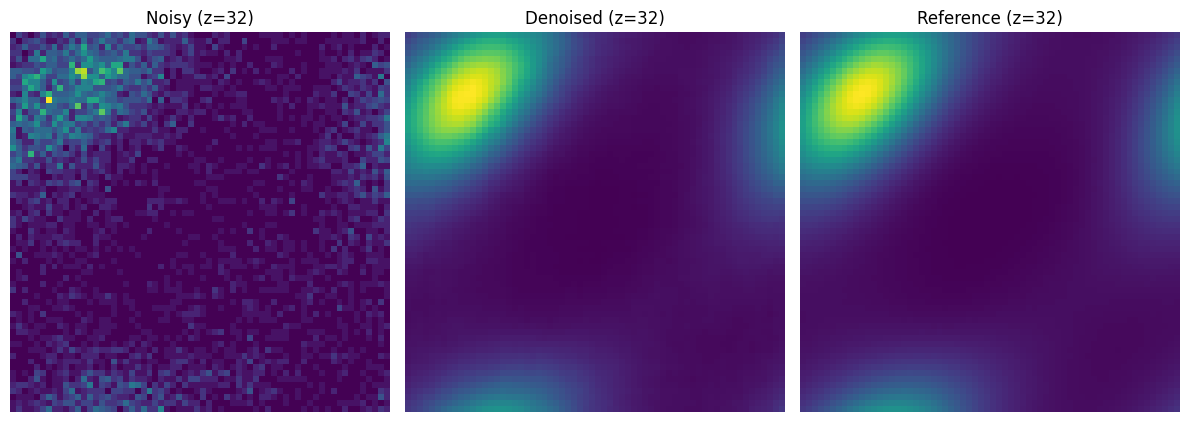

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


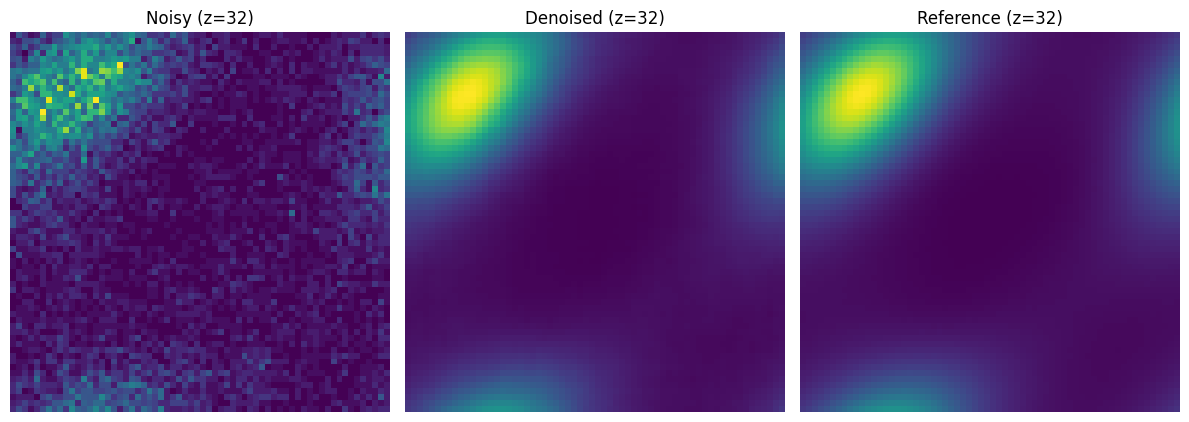

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


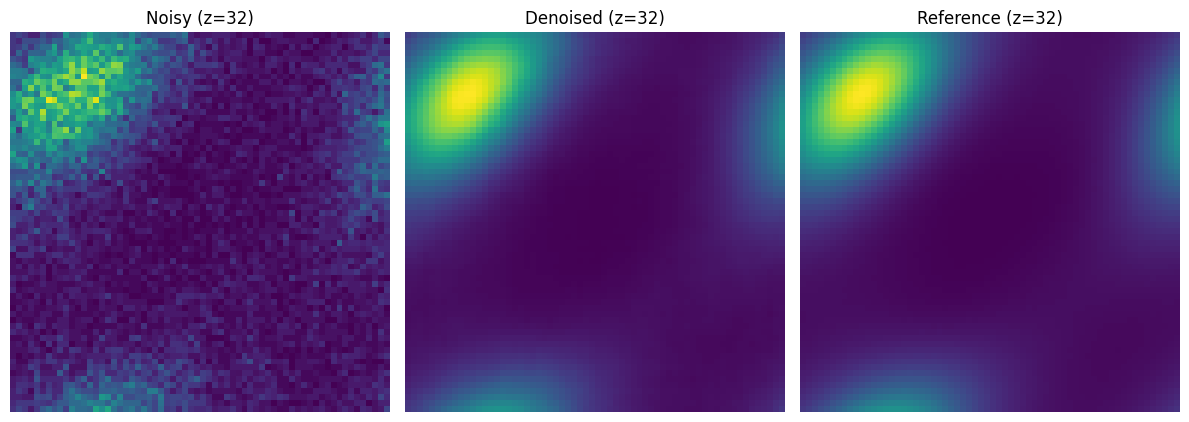

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


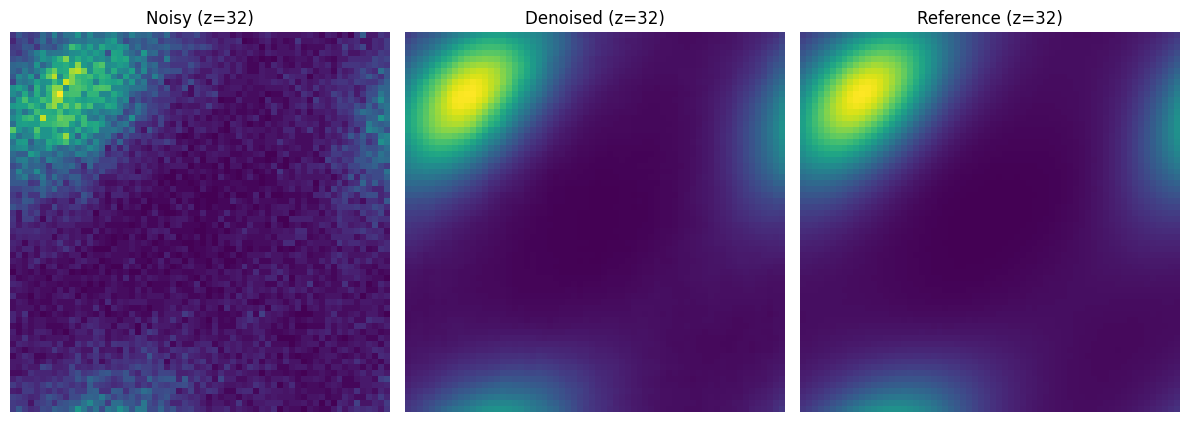

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


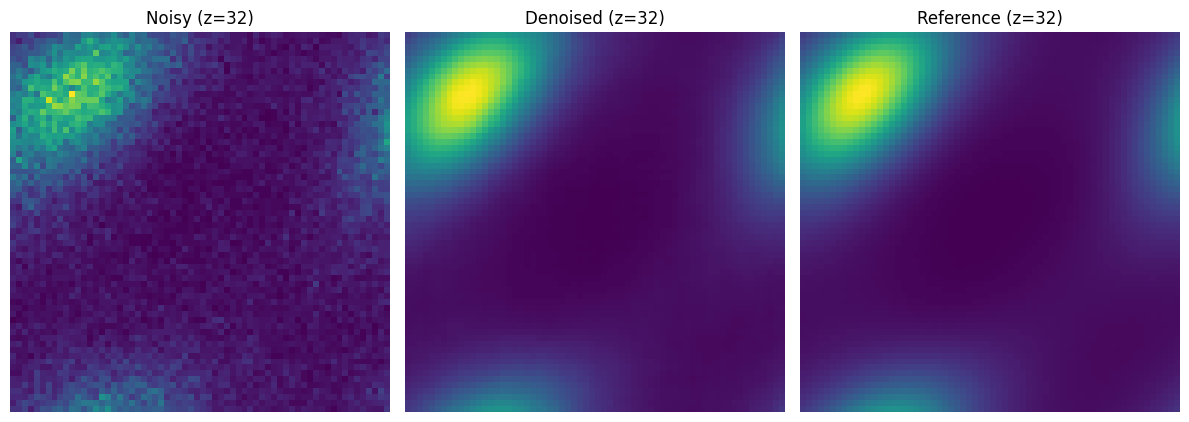

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


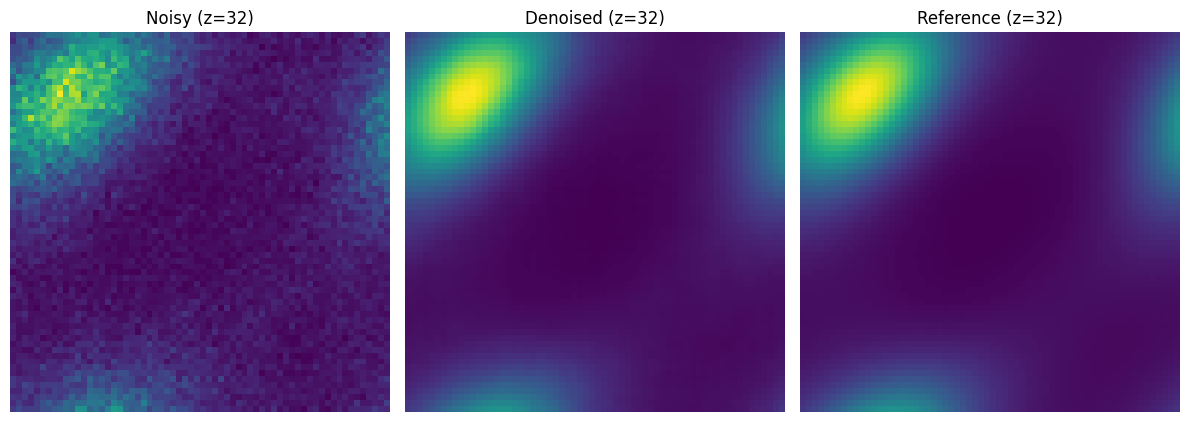

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


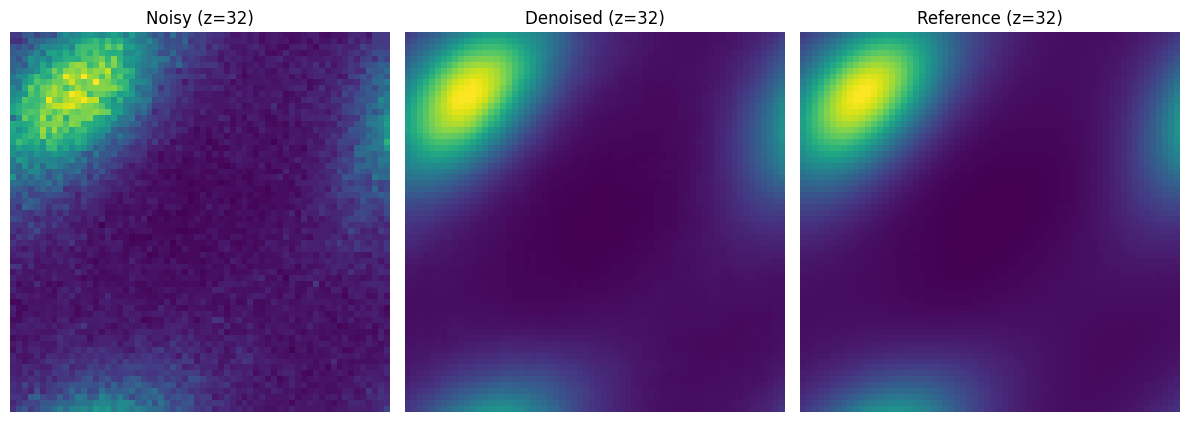

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


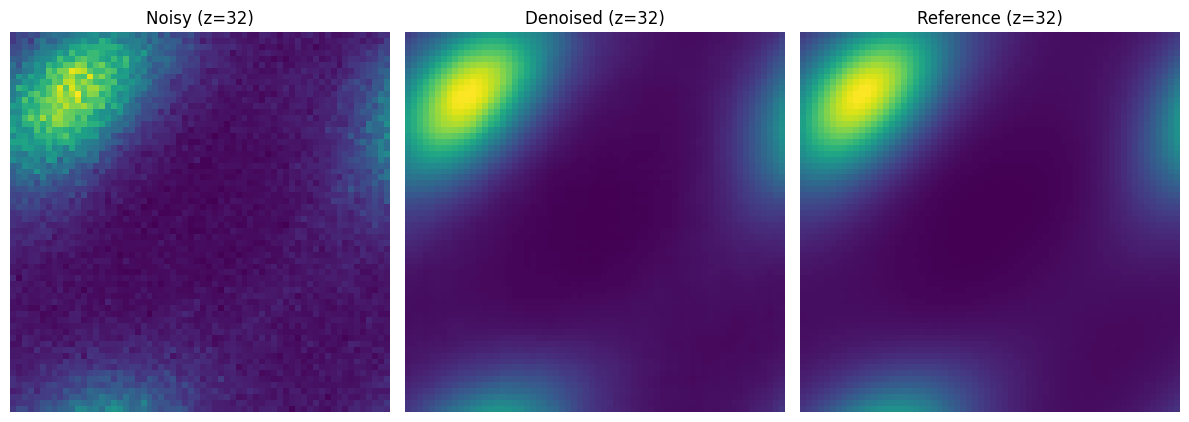

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


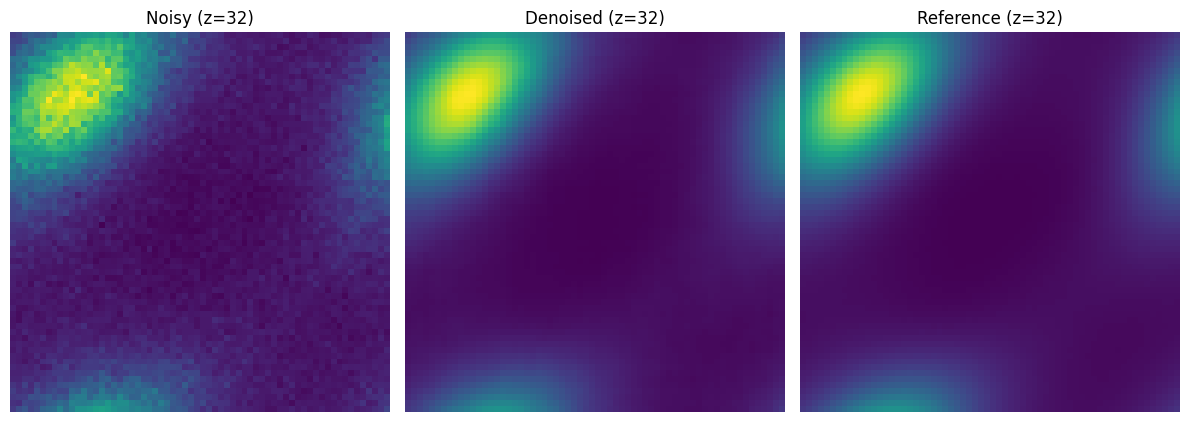

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


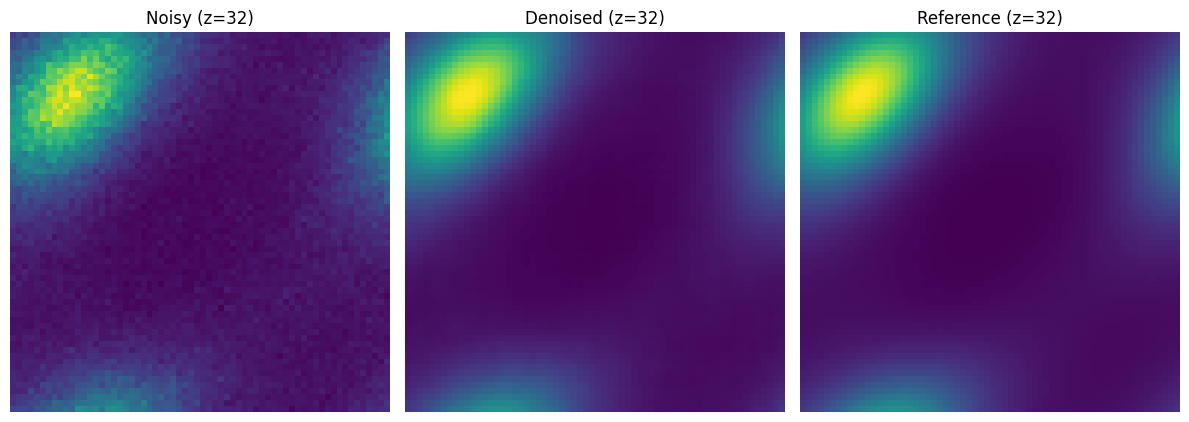

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


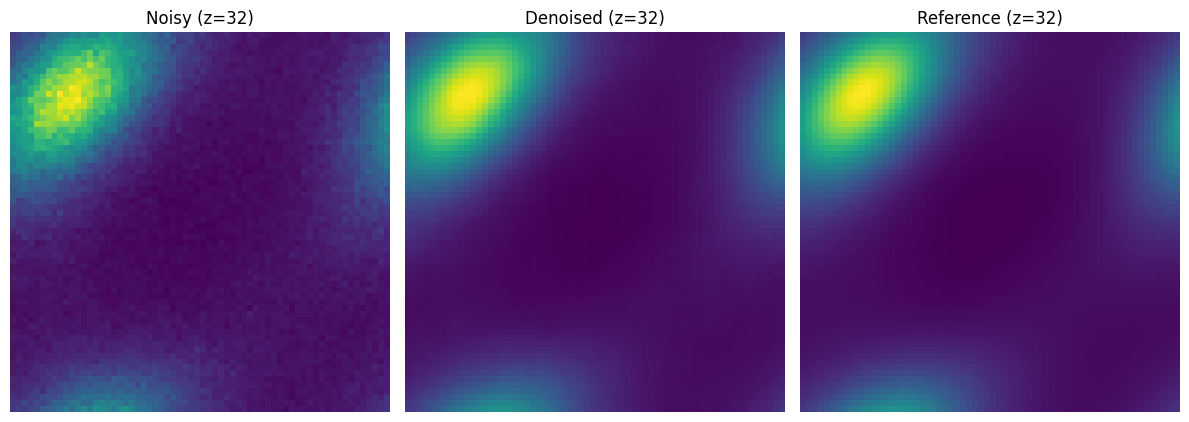

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


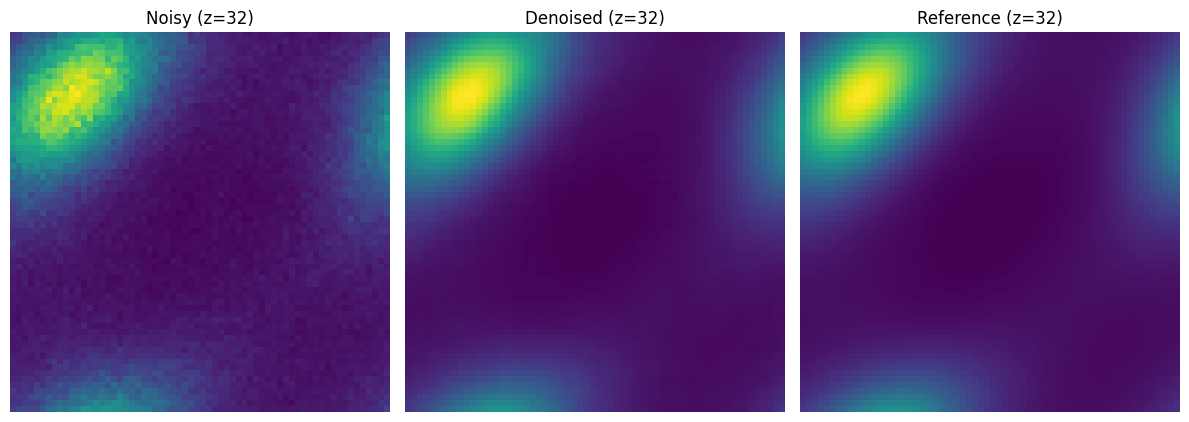

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


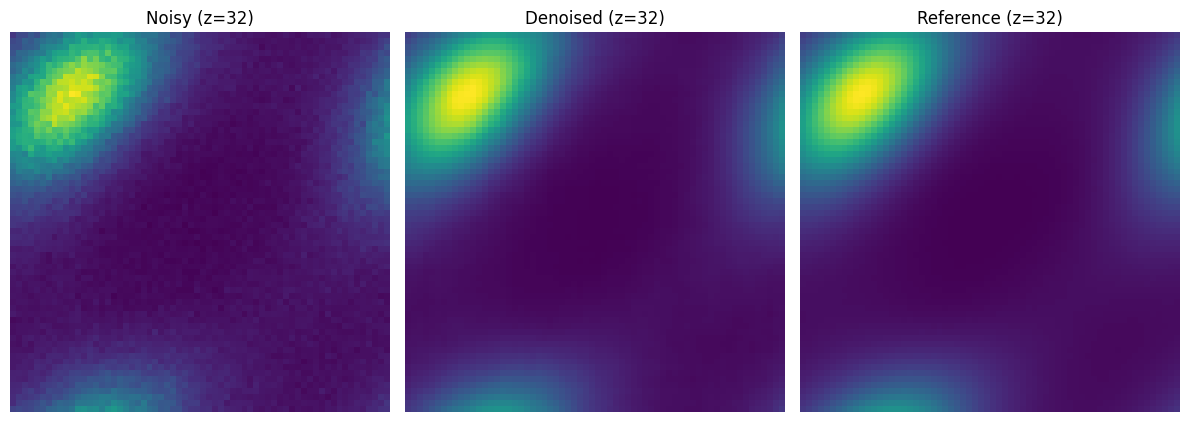

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


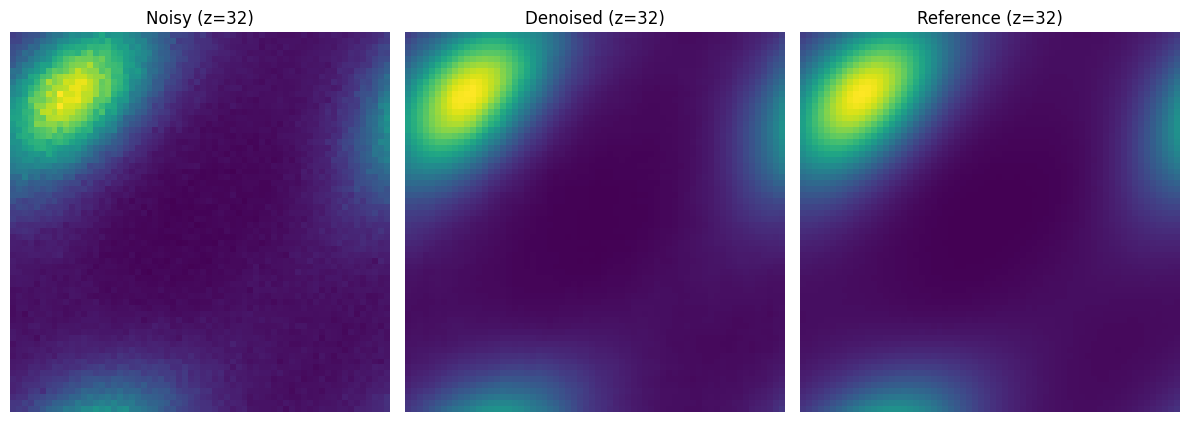

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


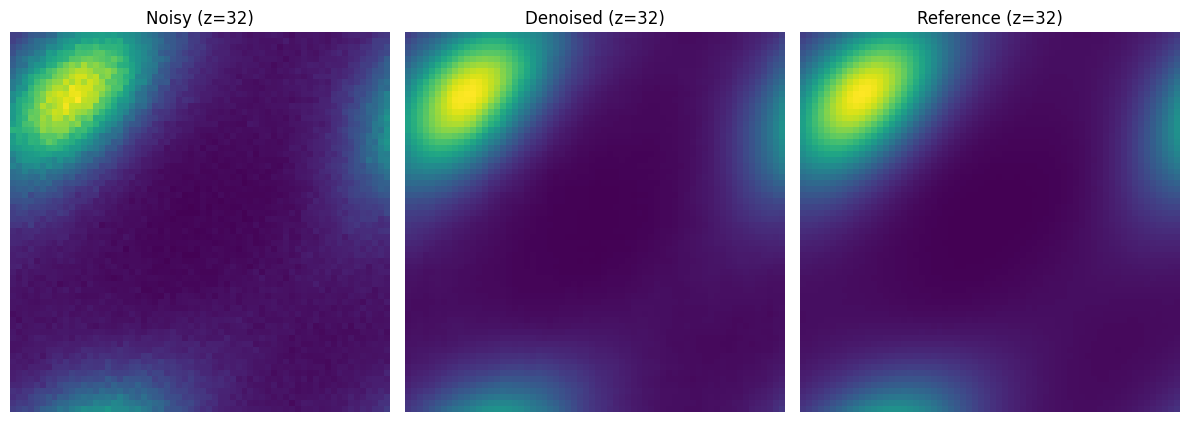

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


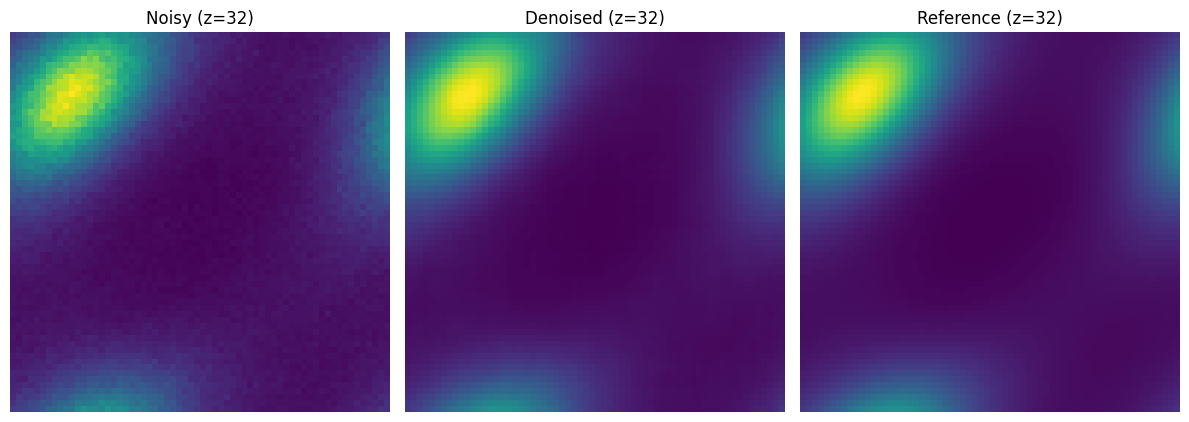

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


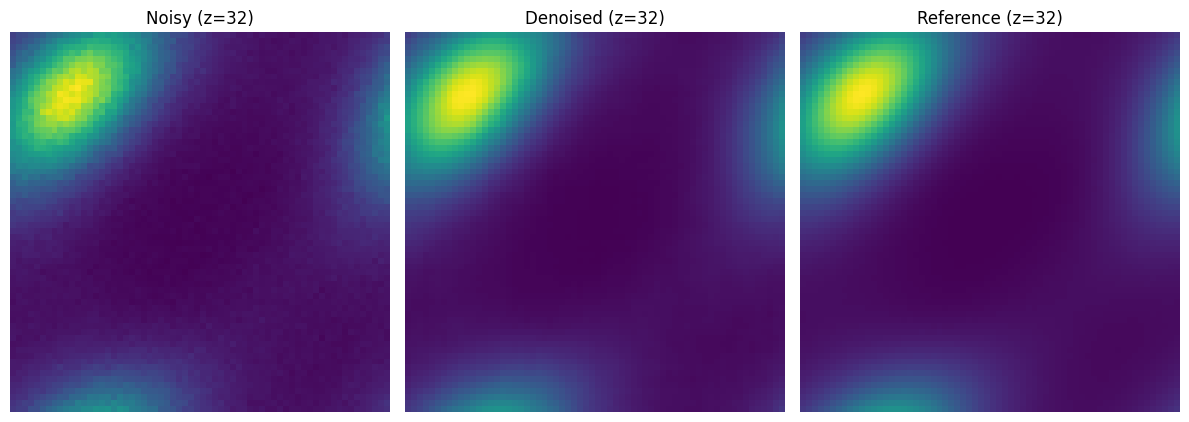

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


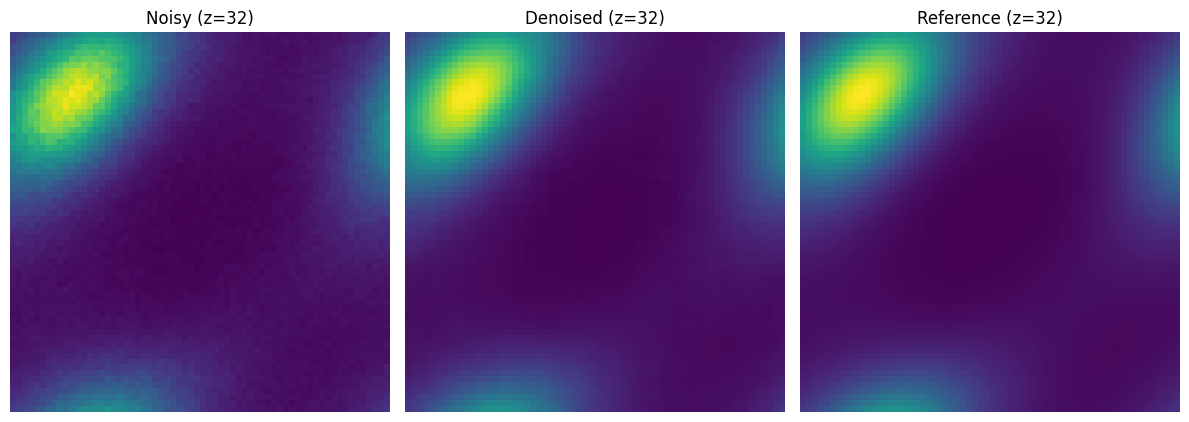

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


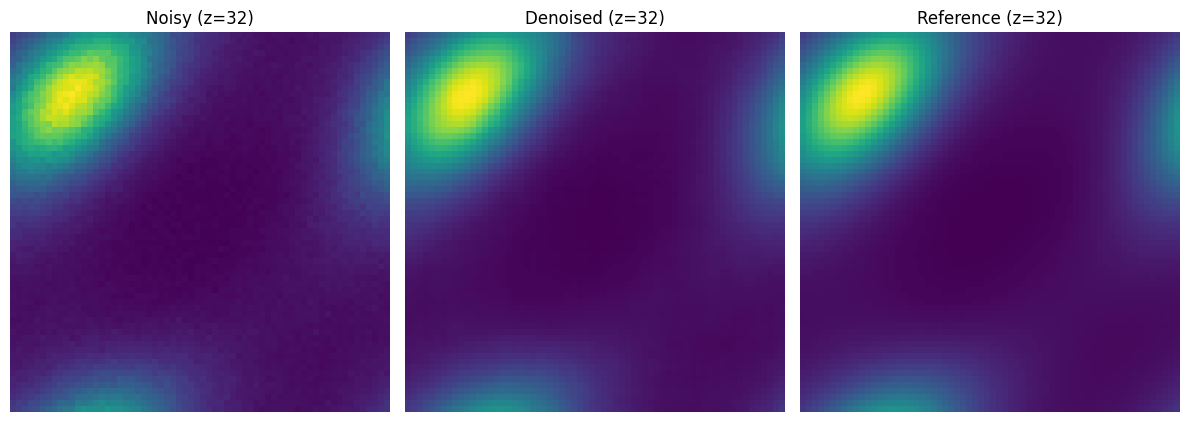

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


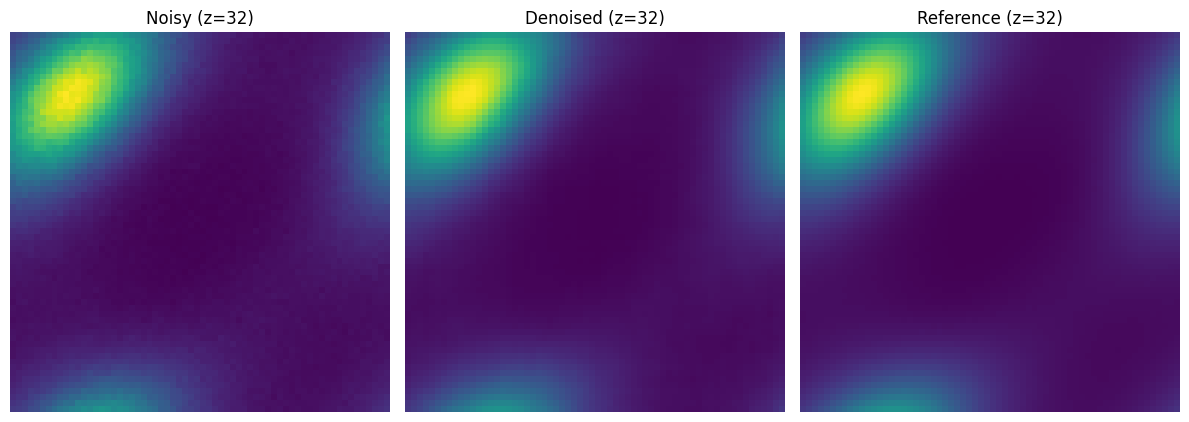

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


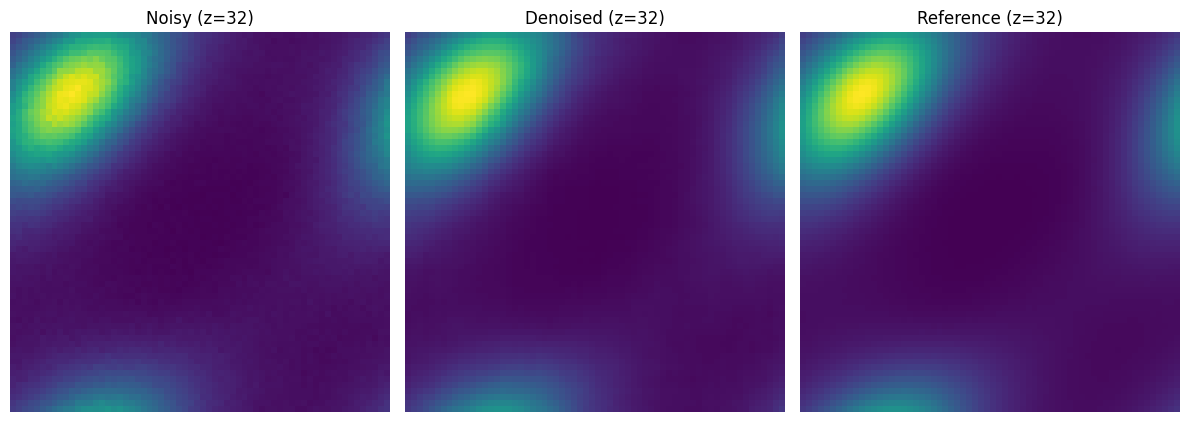

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


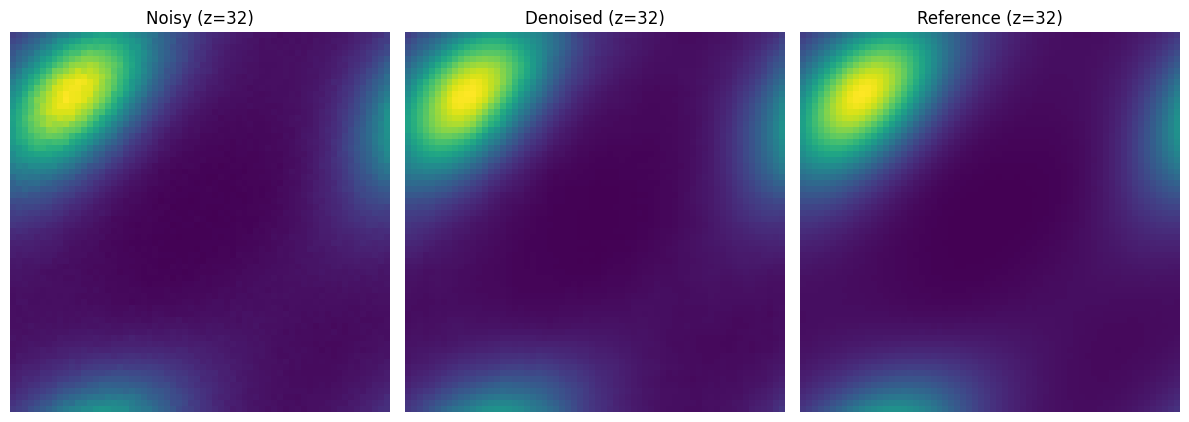

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


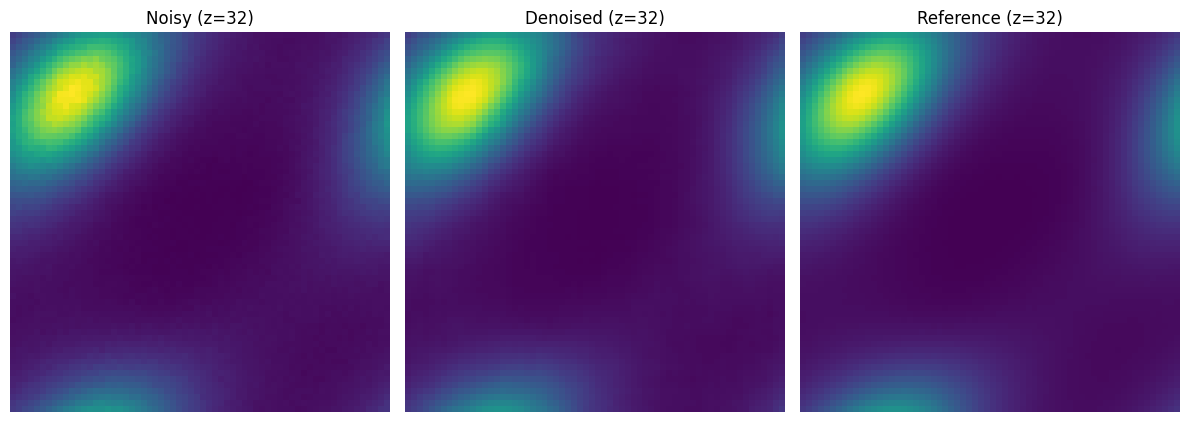

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


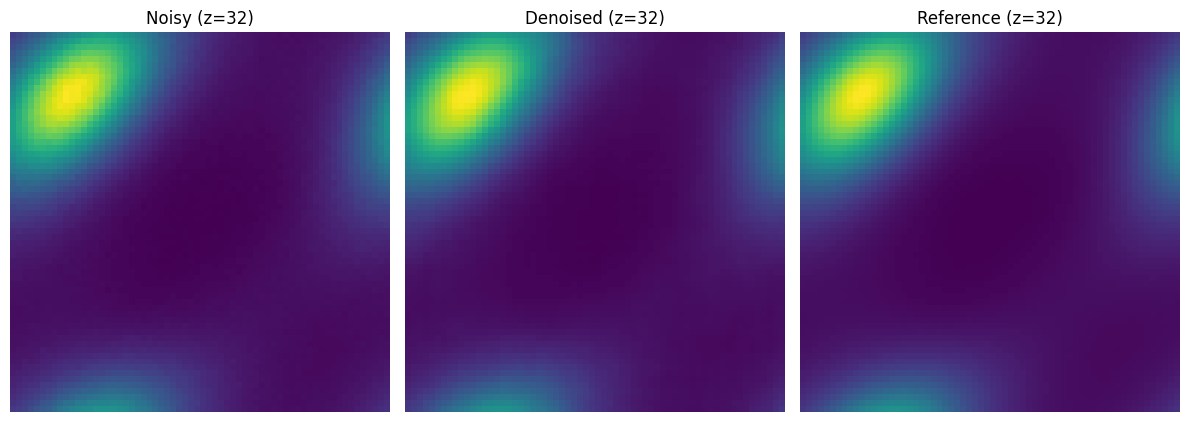

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


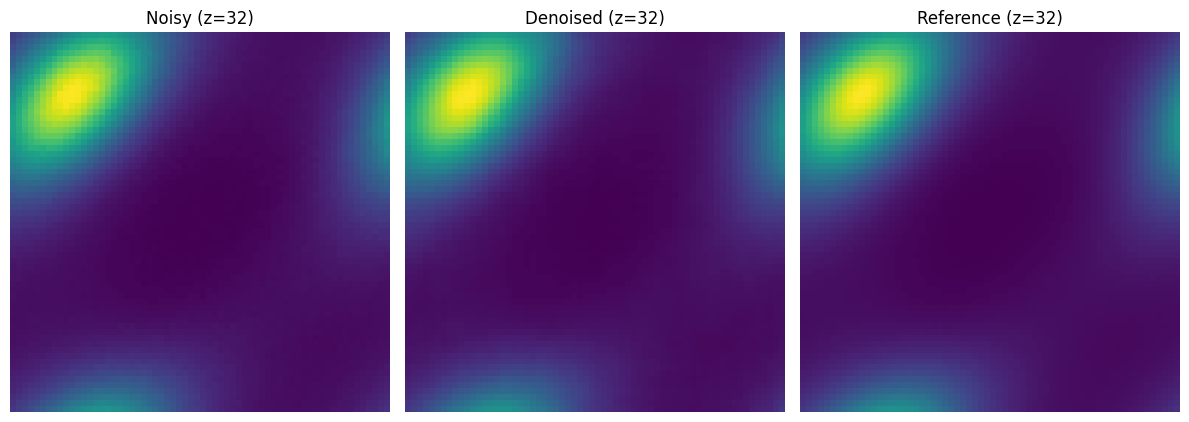

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


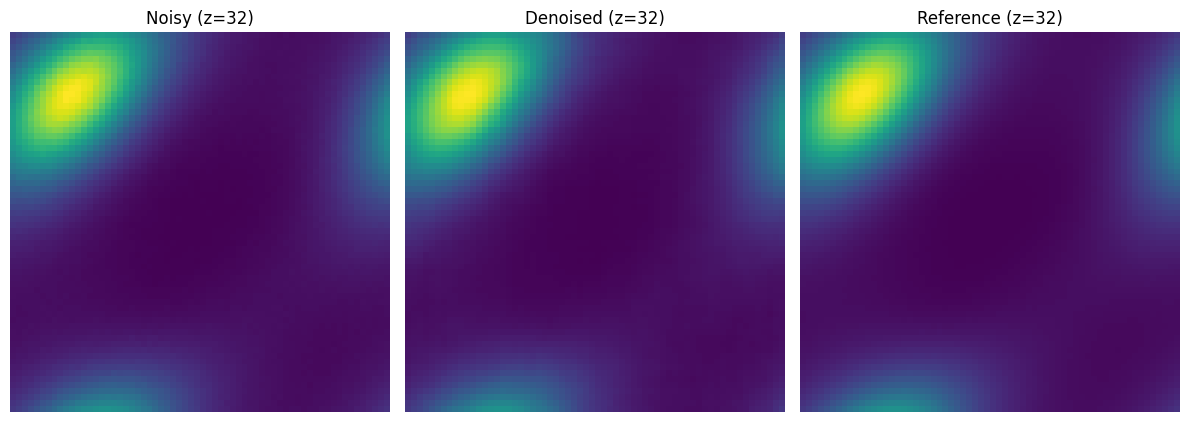

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000119
(64, 64, 64) (64, 64, 64) (64, 64, 64)


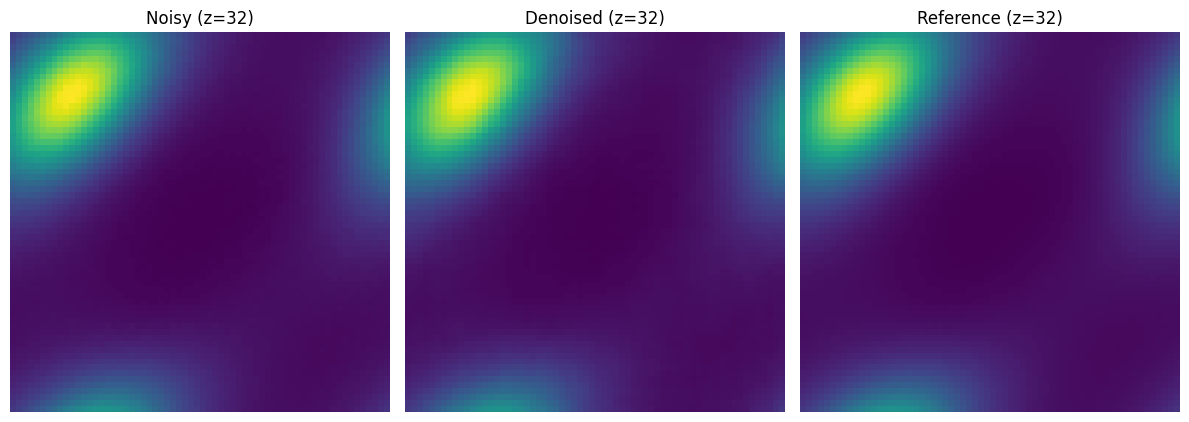

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


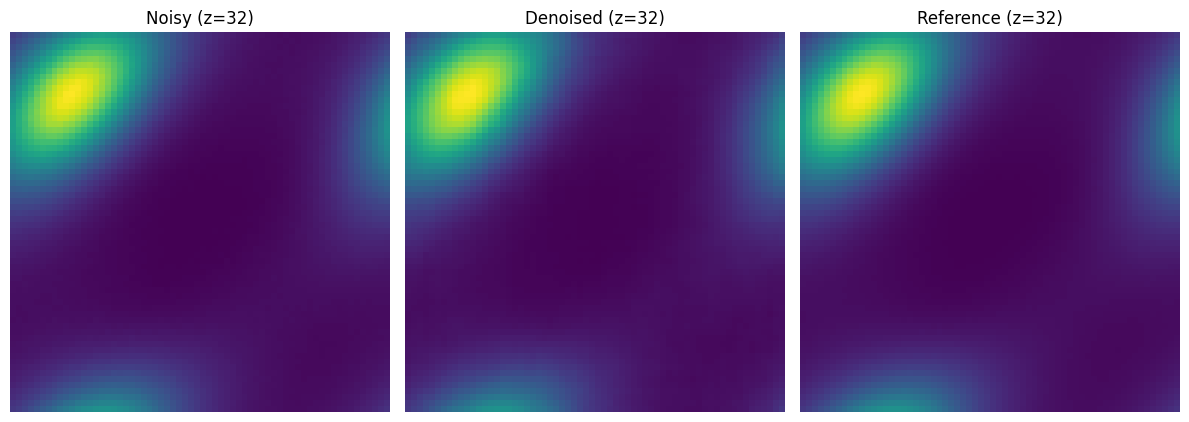

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


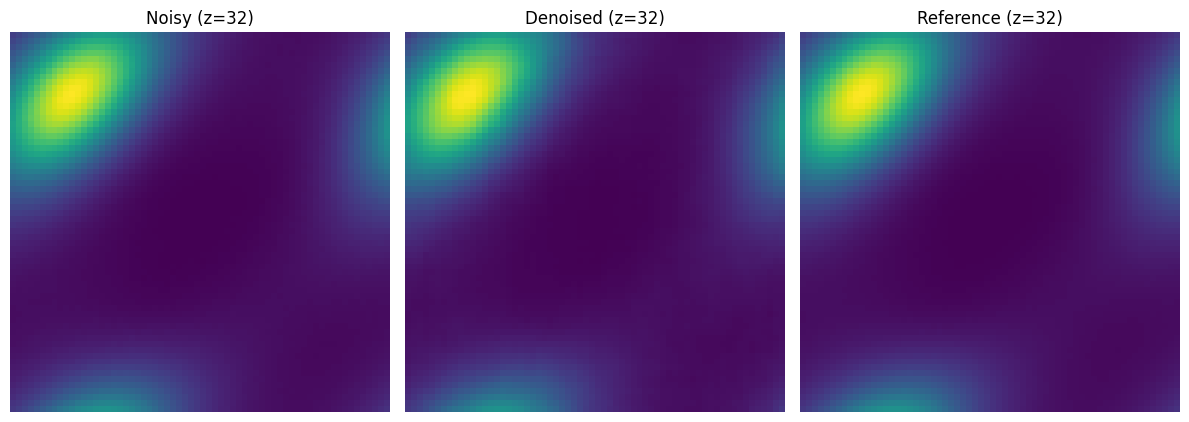

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


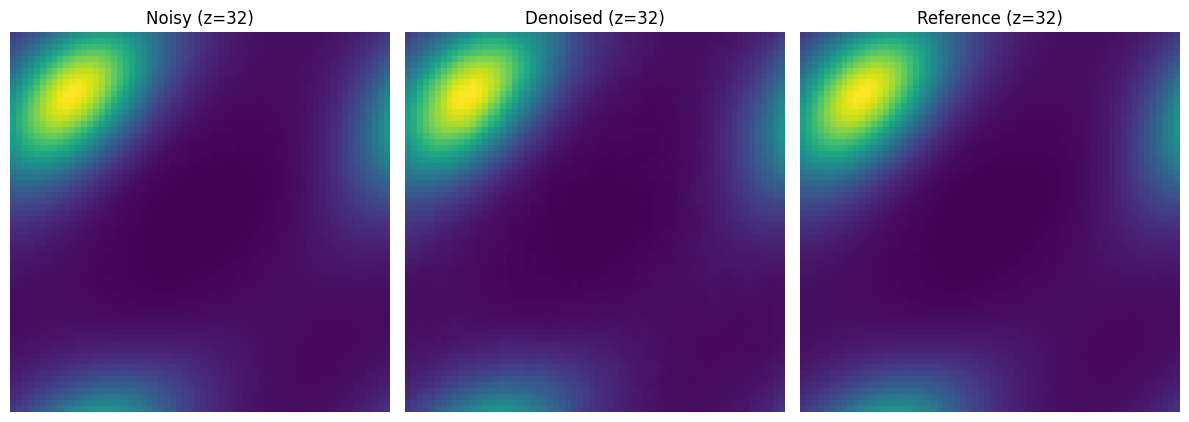

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000118
(64, 64, 64) (64, 64, 64) (64, 64, 64)


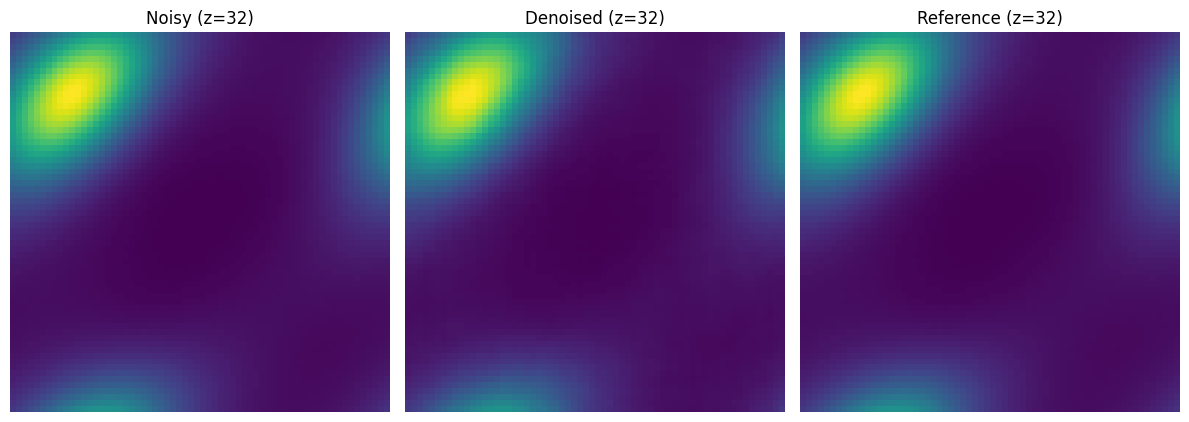


=== Running model: 2385000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000892
(64, 64, 64) (64, 64, 64) (64, 64, 64)


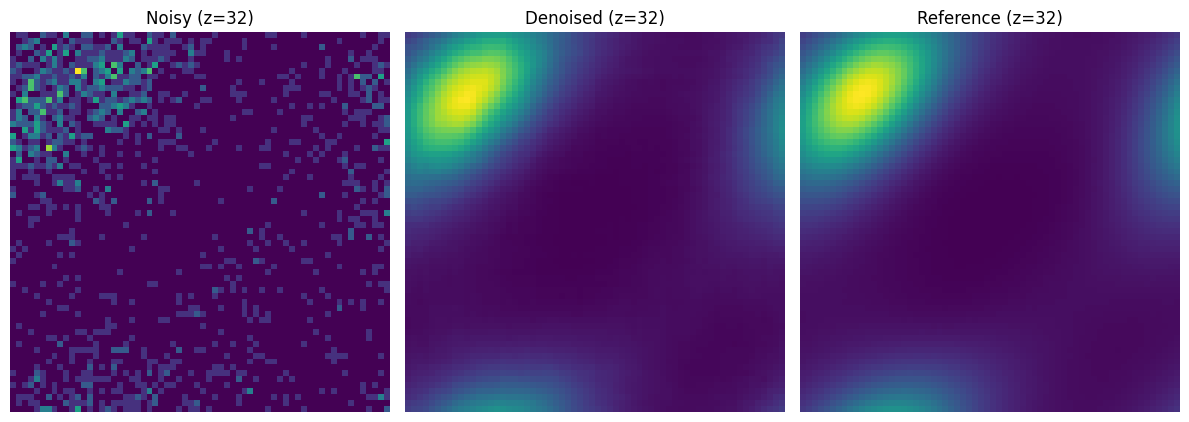

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000880
(64, 64, 64) (64, 64, 64) (64, 64, 64)


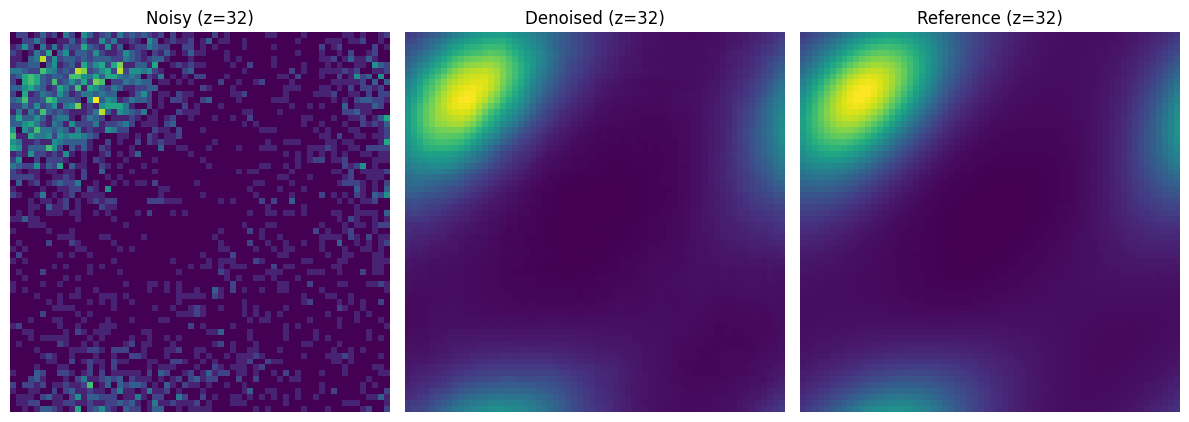

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000874
(64, 64, 64) (64, 64, 64) (64, 64, 64)


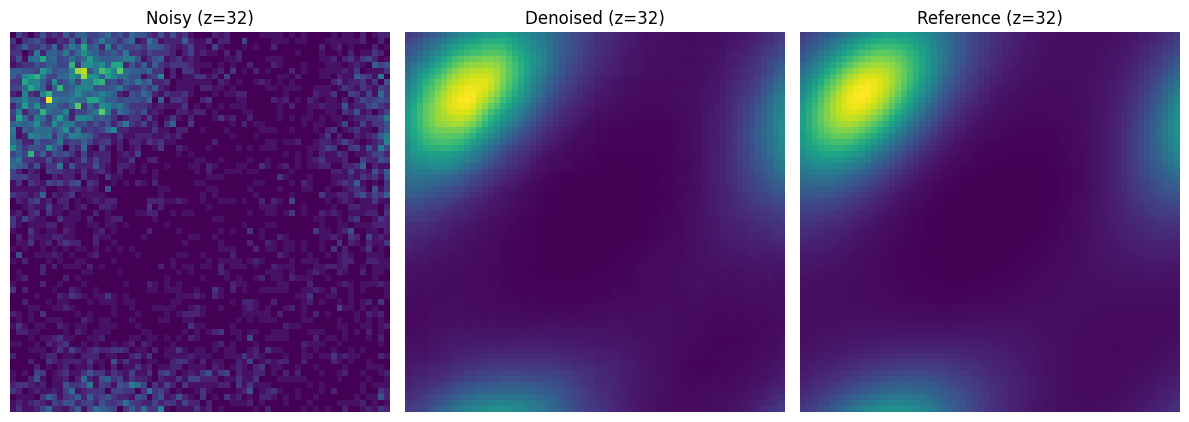

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000868
(64, 64, 64) (64, 64, 64) (64, 64, 64)


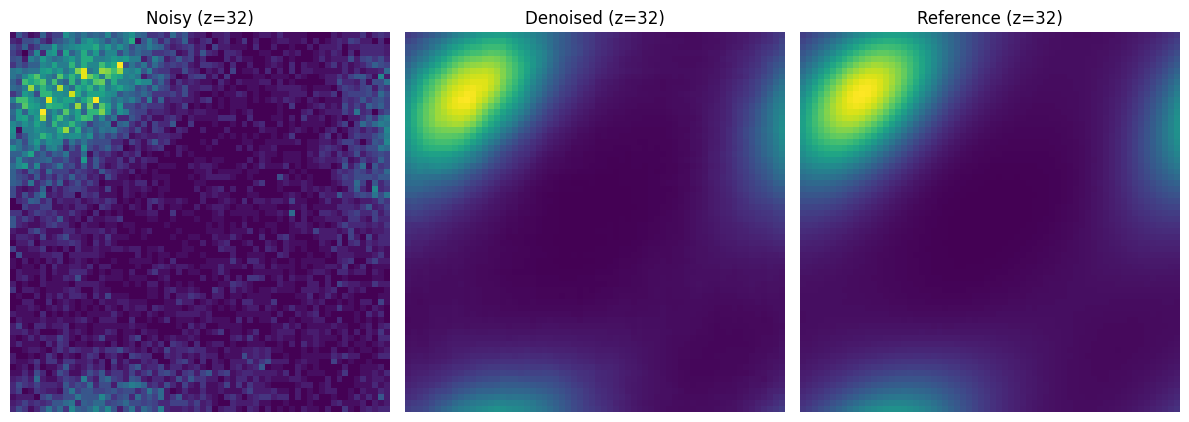

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000866
(64, 64, 64) (64, 64, 64) (64, 64, 64)


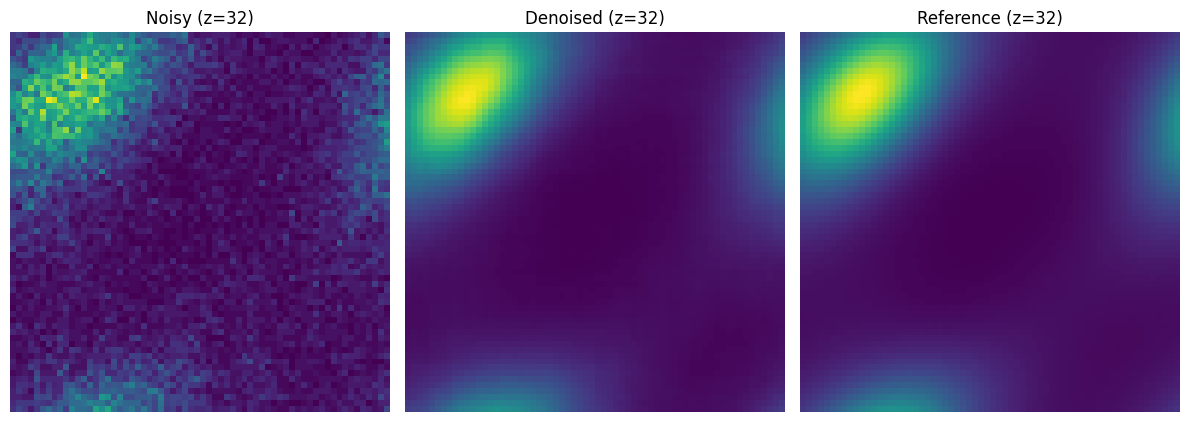

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000863
(64, 64, 64) (64, 64, 64) (64, 64, 64)


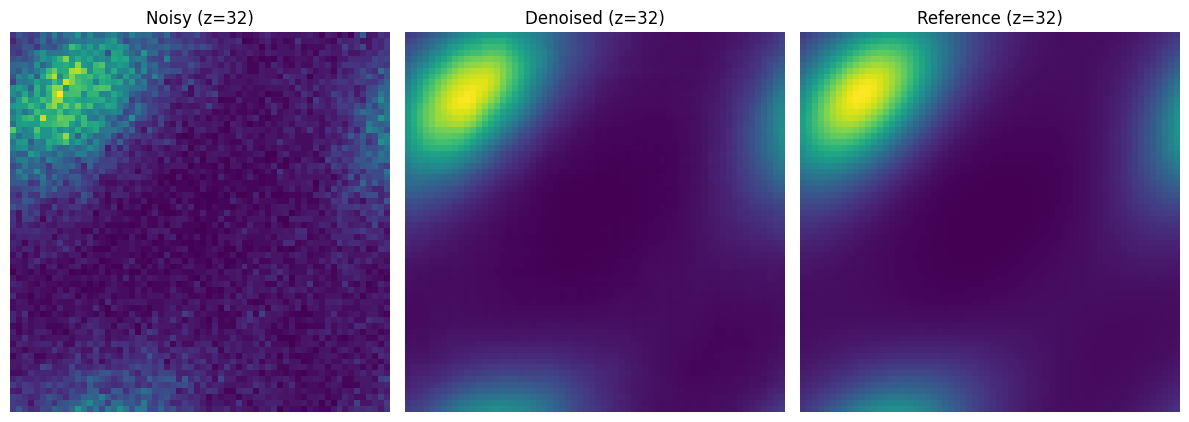

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000862
(64, 64, 64) (64, 64, 64) (64, 64, 64)


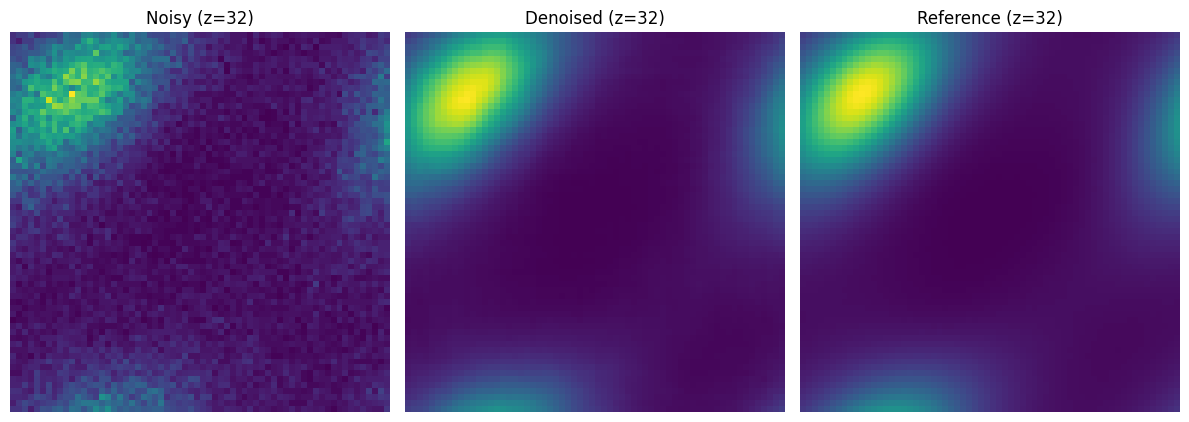

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000862
(64, 64, 64) (64, 64, 64) (64, 64, 64)


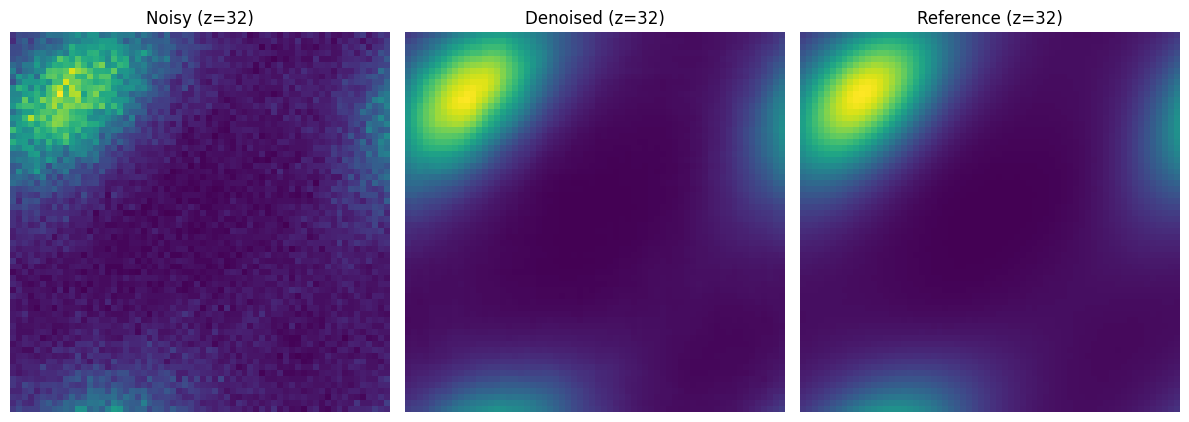

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


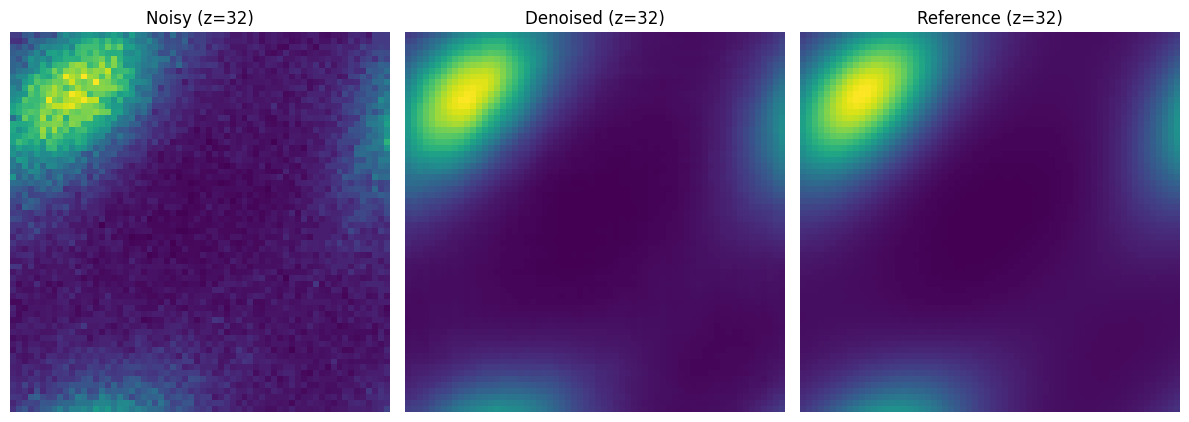

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000862
(64, 64, 64) (64, 64, 64) (64, 64, 64)


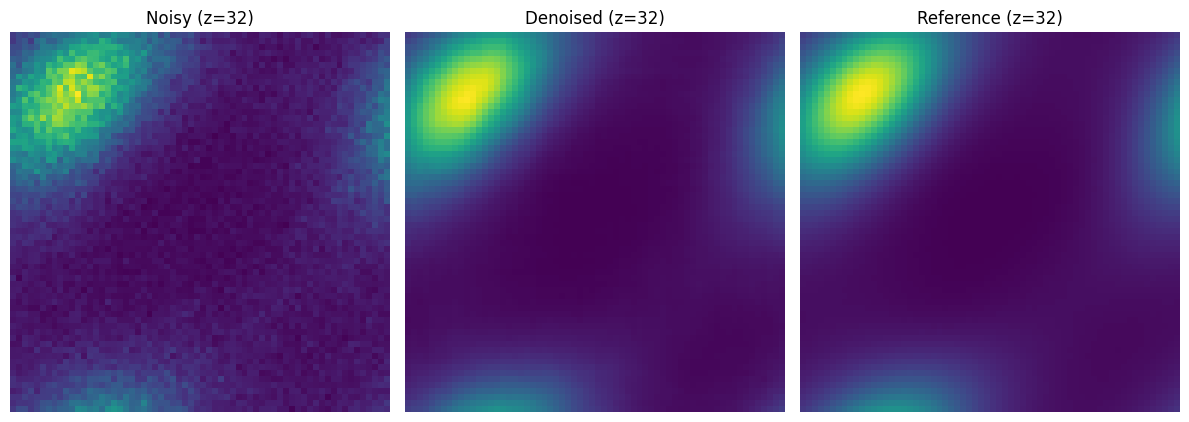

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000862
(64, 64, 64) (64, 64, 64) (64, 64, 64)


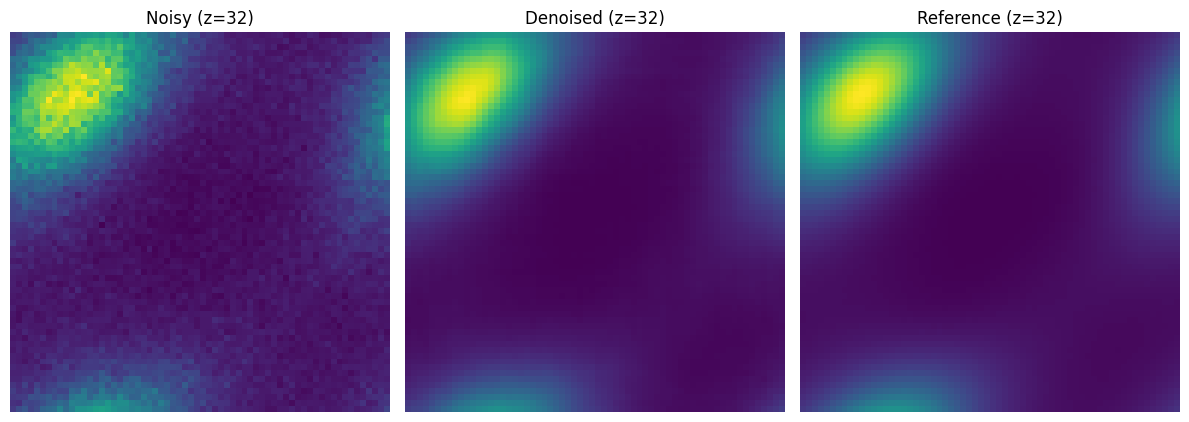

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


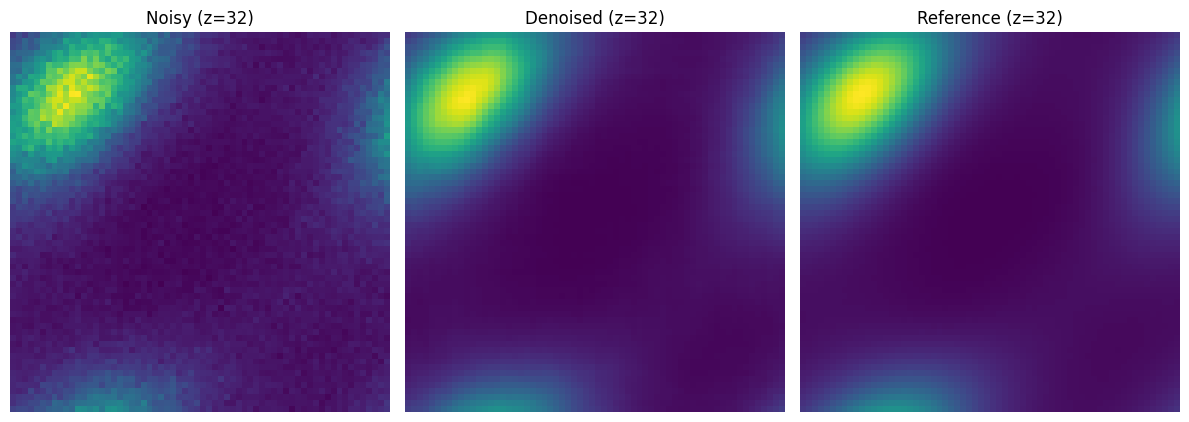

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


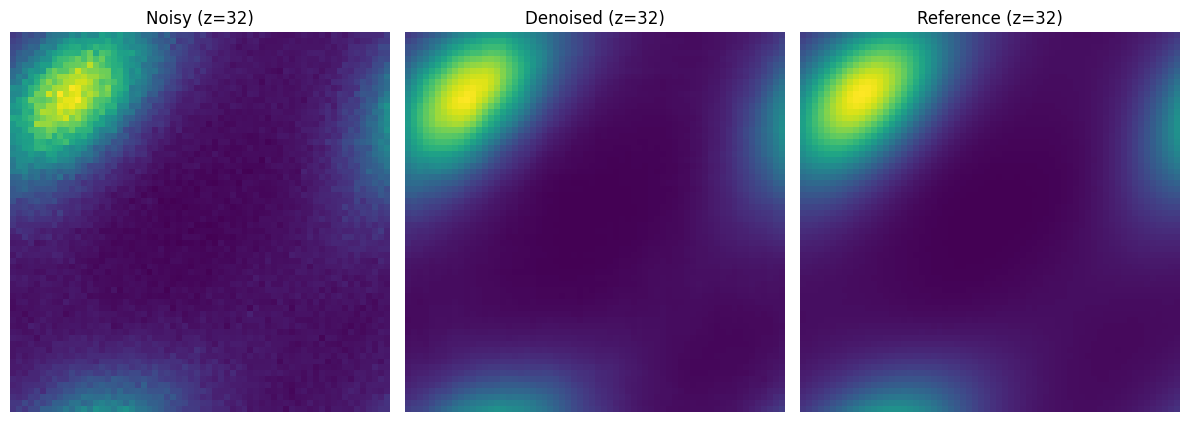

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


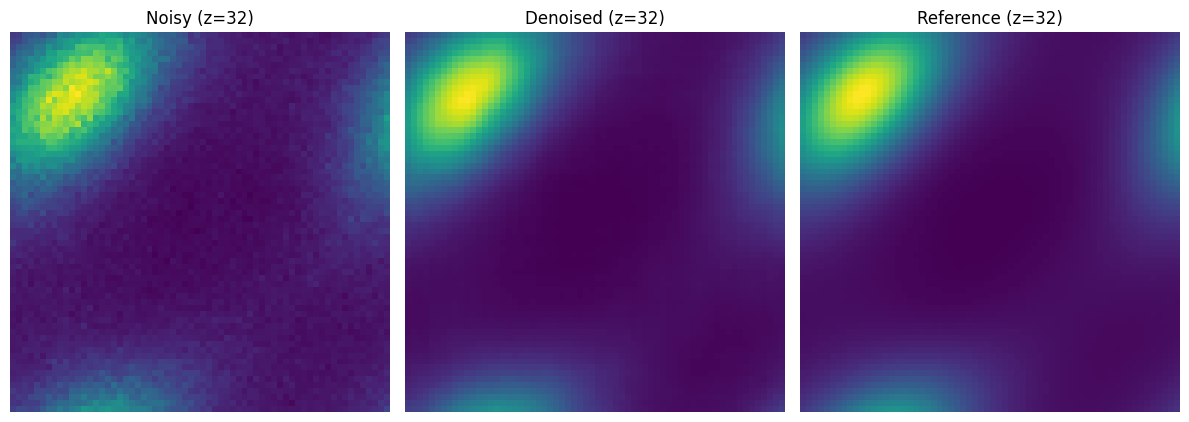

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


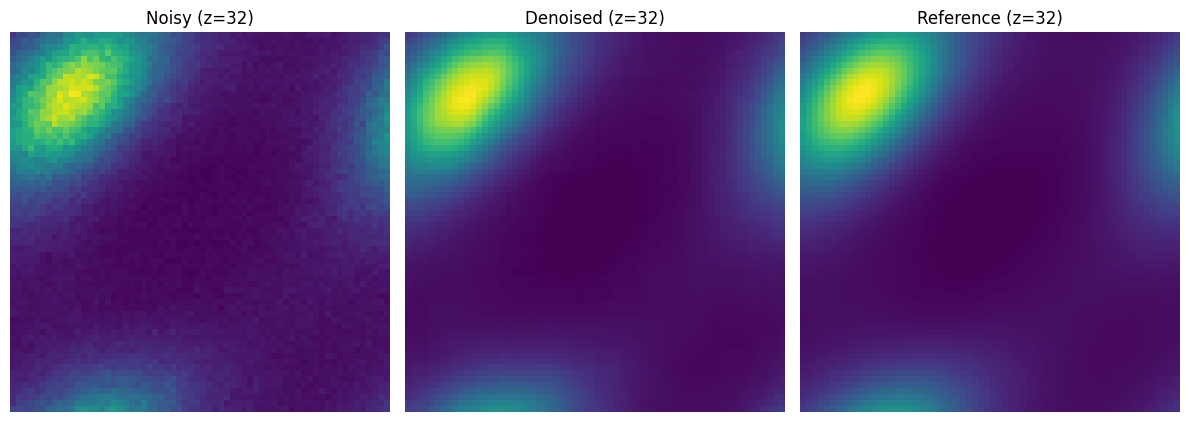

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


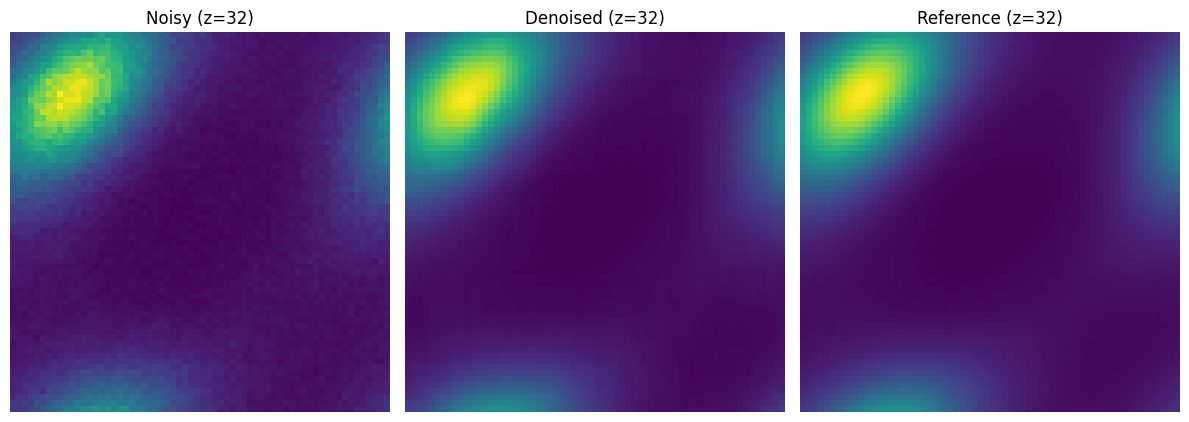

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


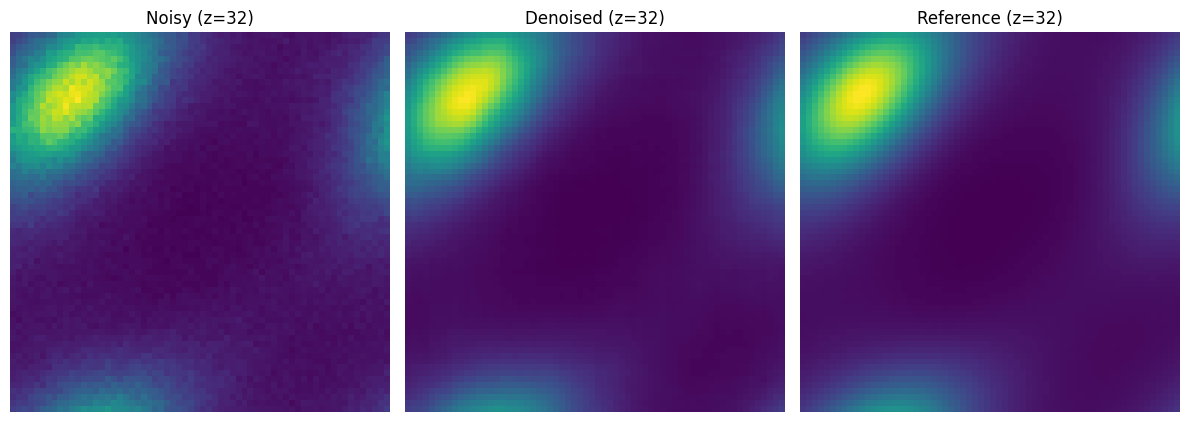

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


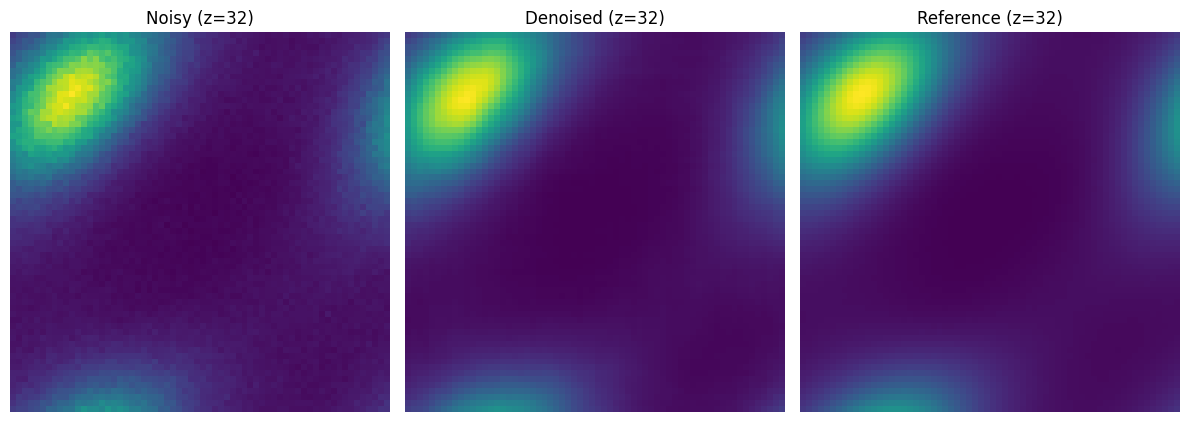

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


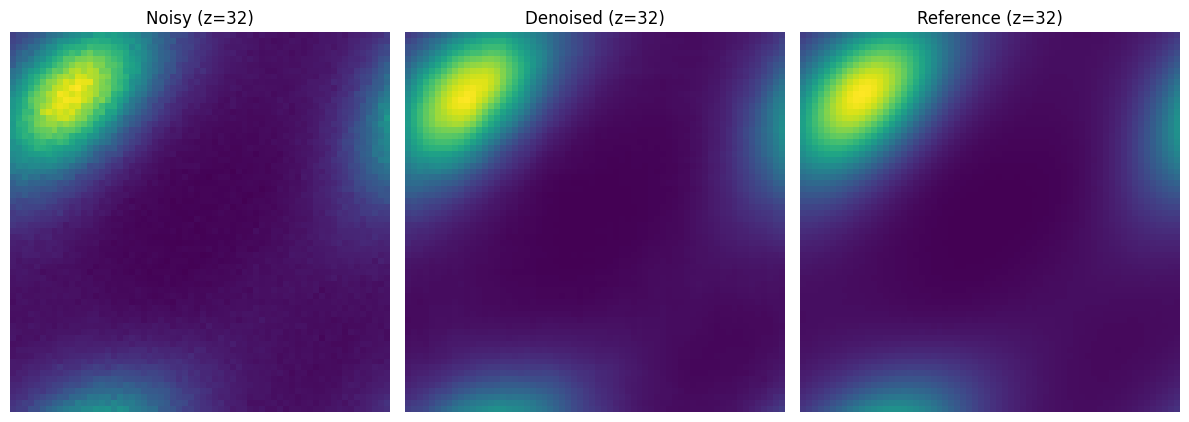

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


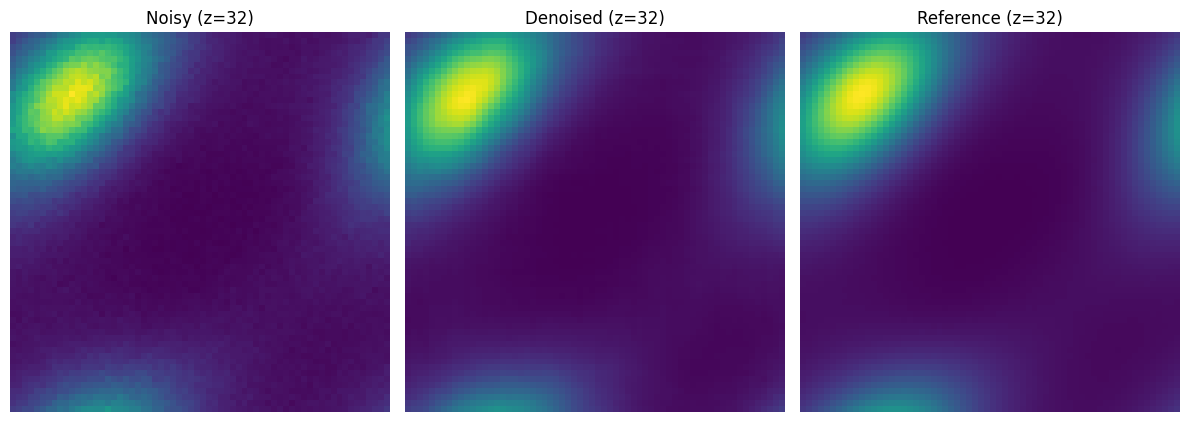

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


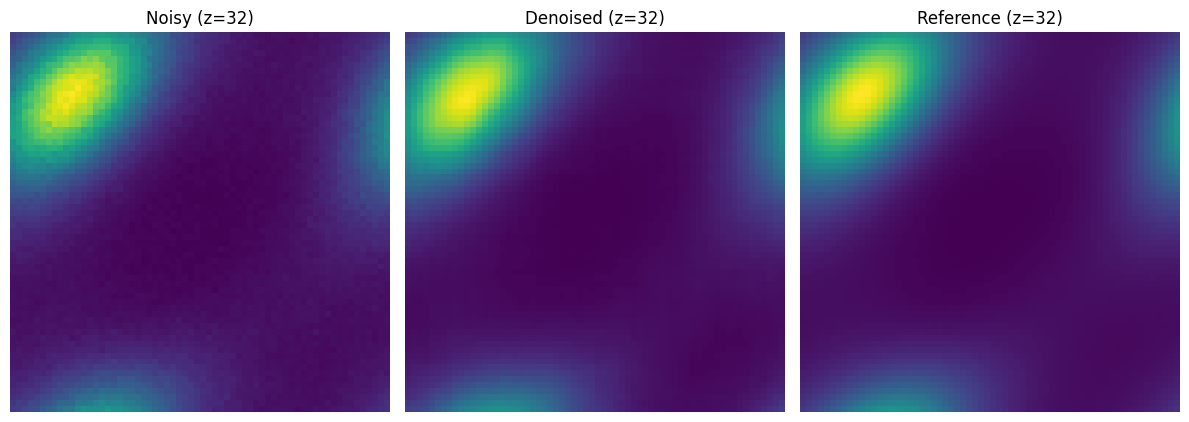

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


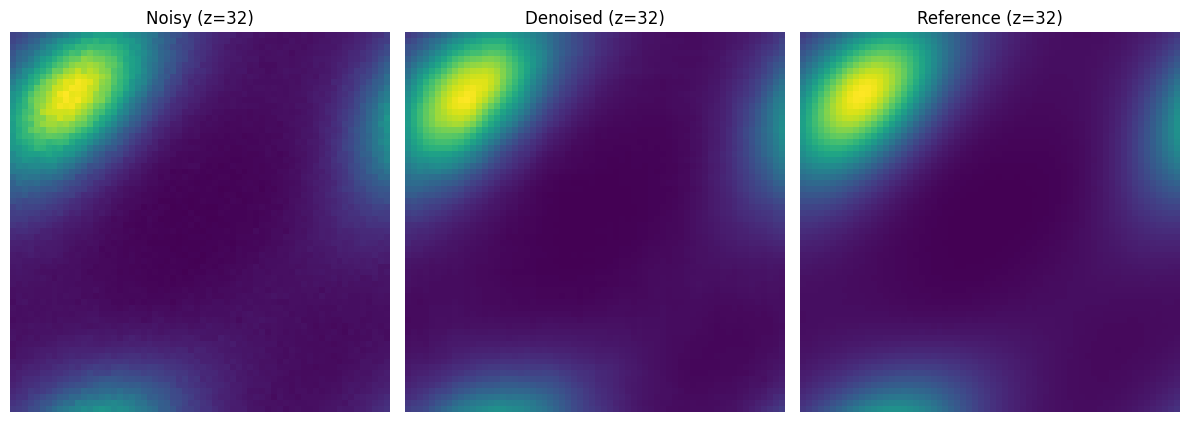

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


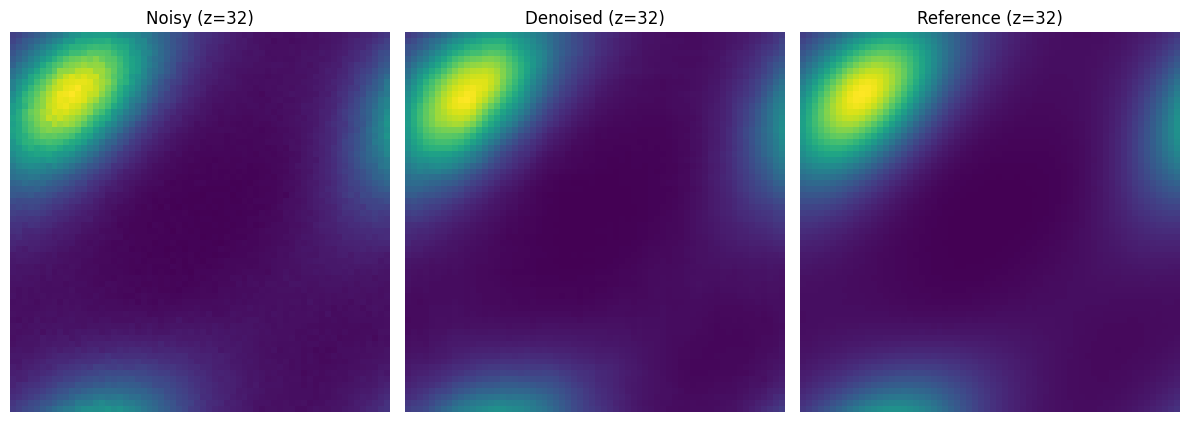

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


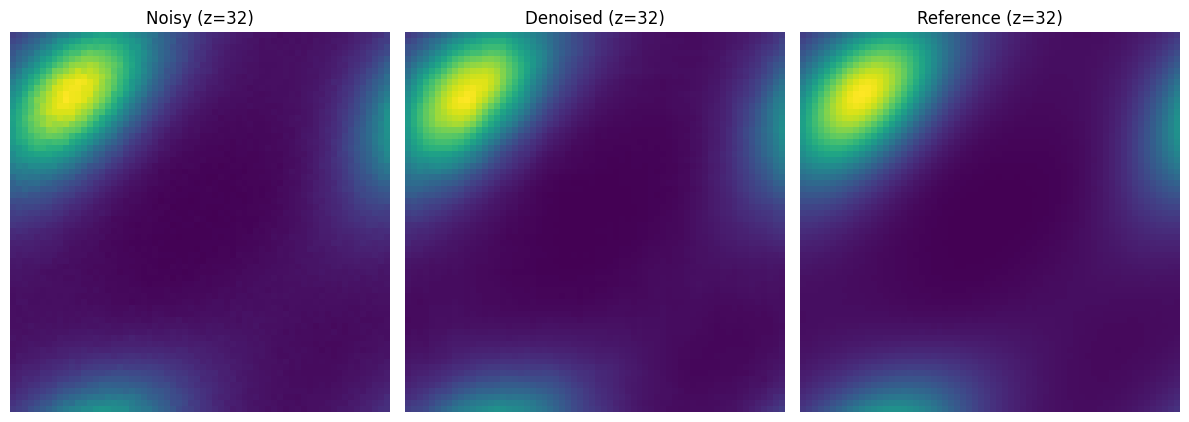

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


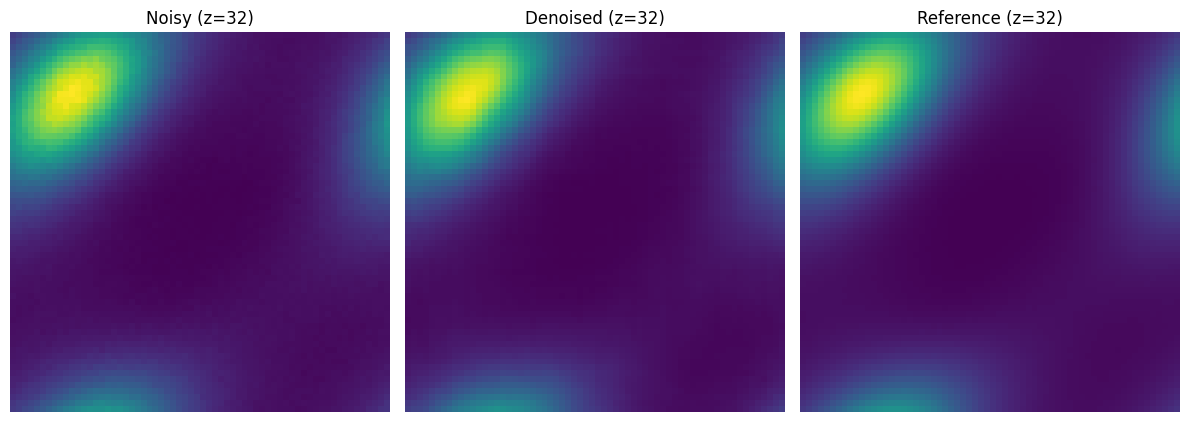

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


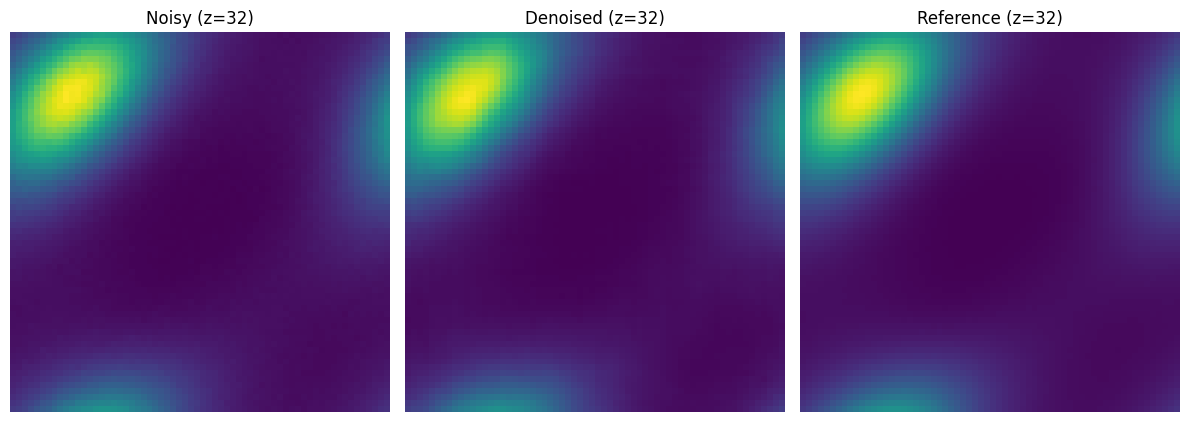

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


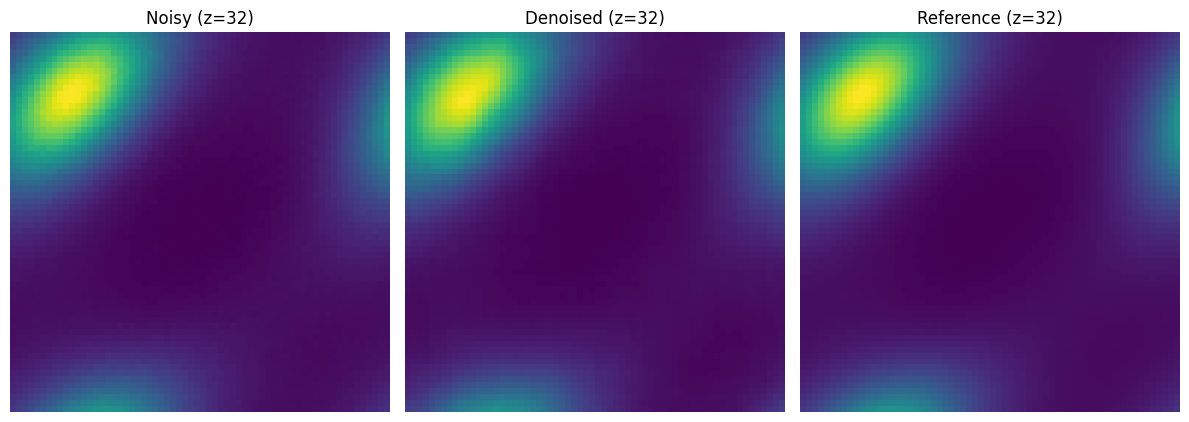

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


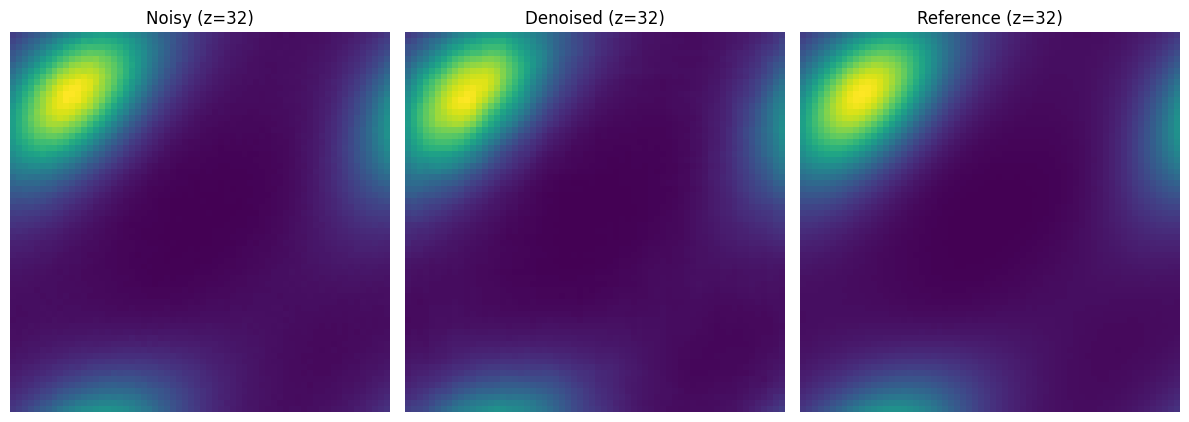

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000859
(64, 64, 64) (64, 64, 64) (64, 64, 64)


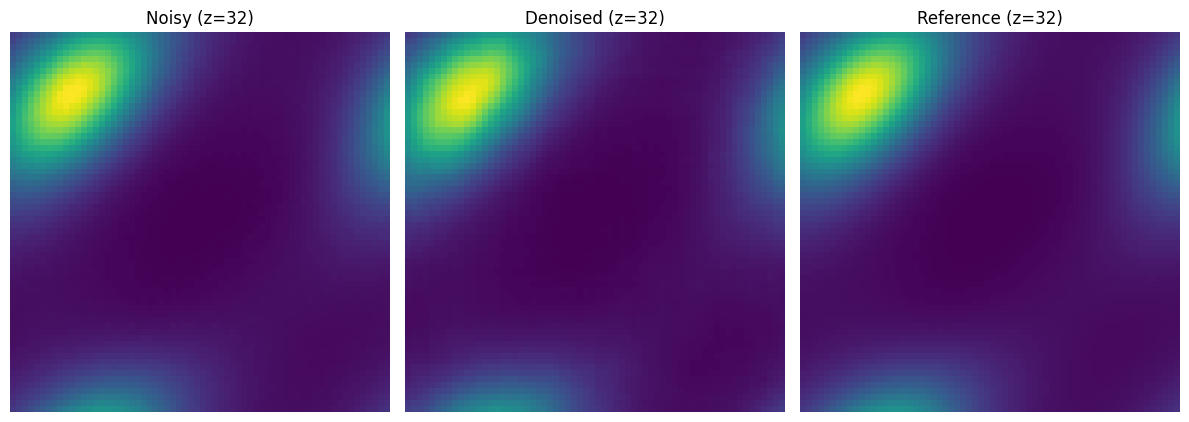

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


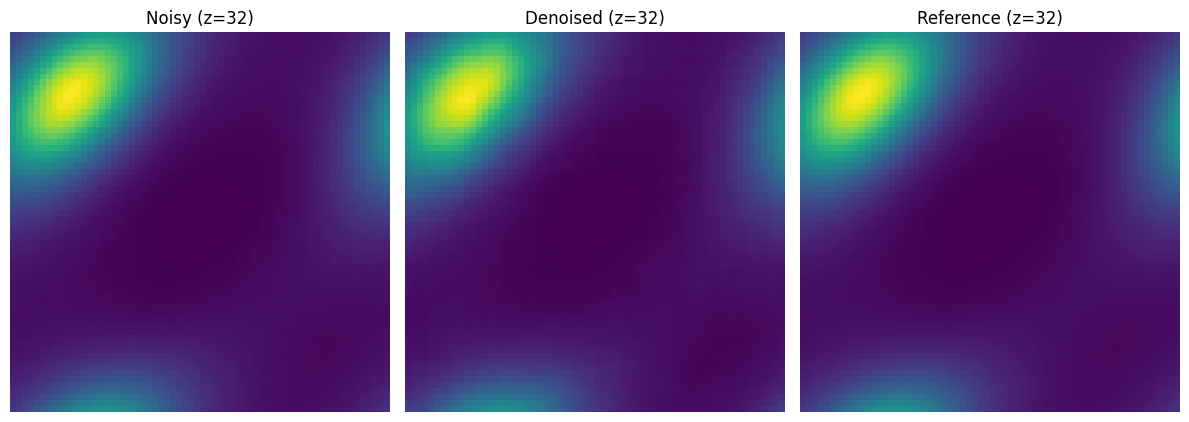

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


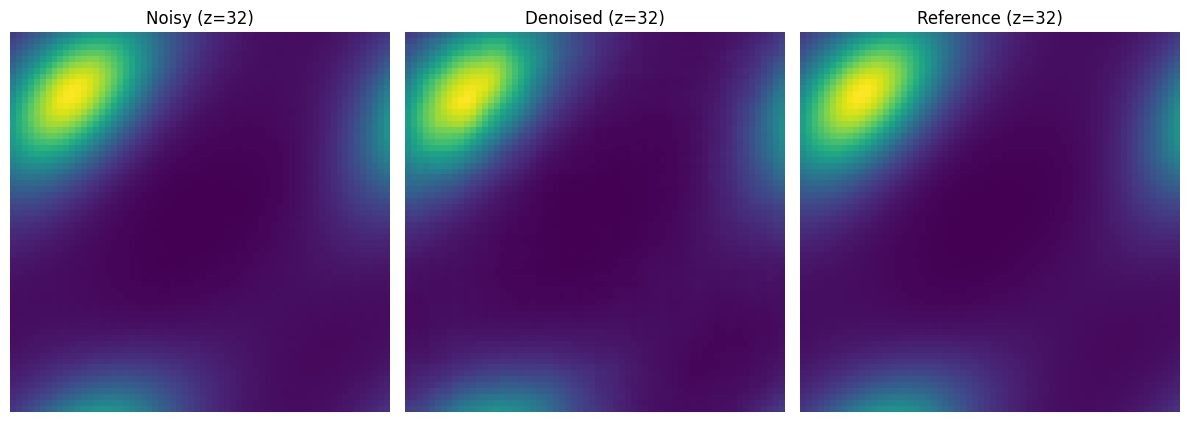

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000861
(64, 64, 64) (64, 64, 64) (64, 64, 64)


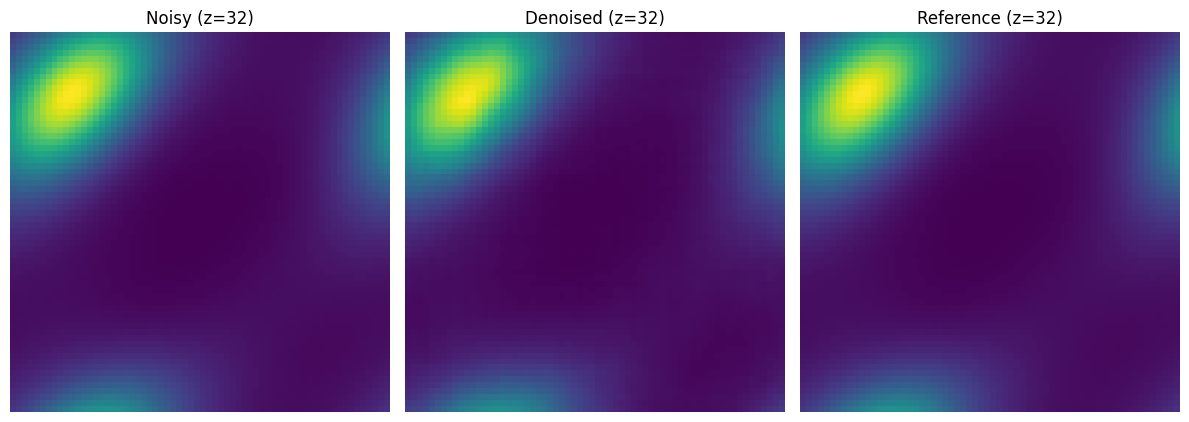

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0012
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000860
(64, 64, 64) (64, 64, 64) (64, 64, 64)


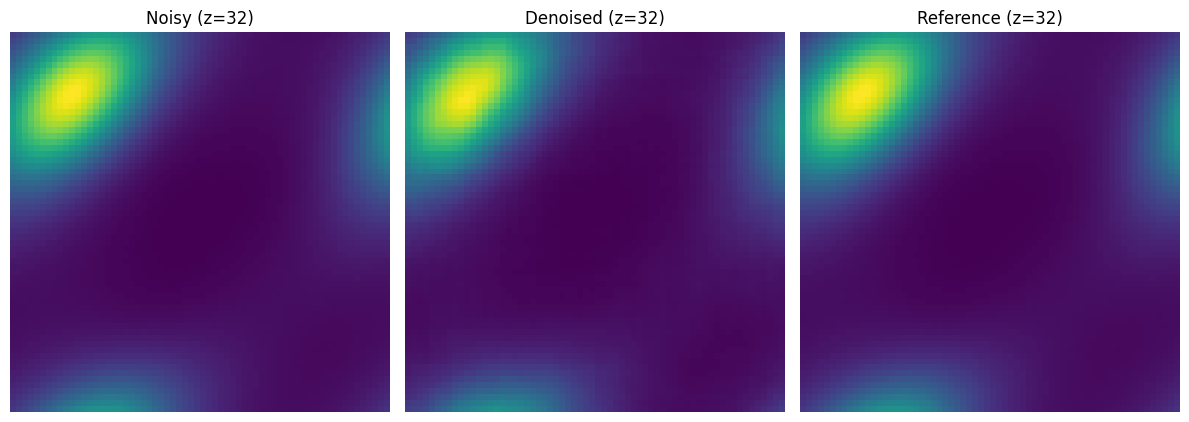


=== Running model: 238800000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 736ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


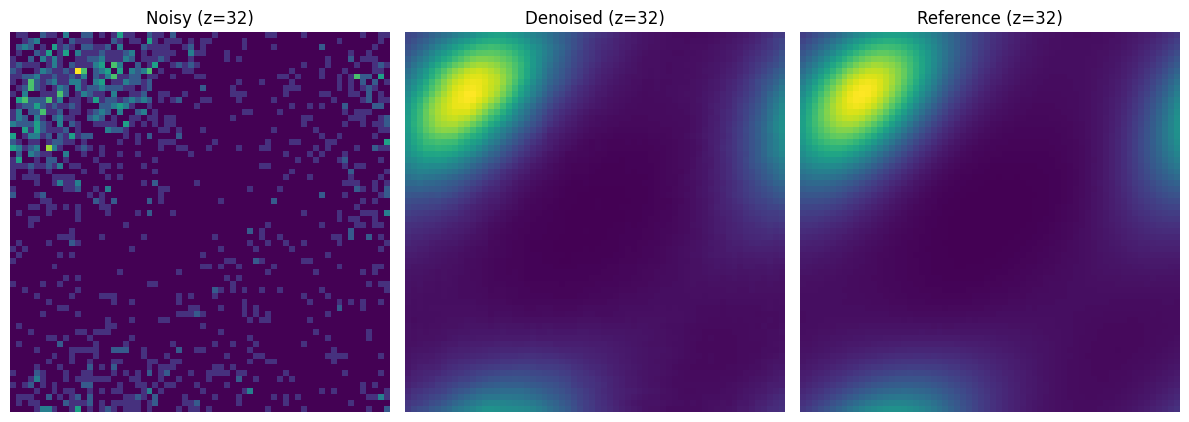

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


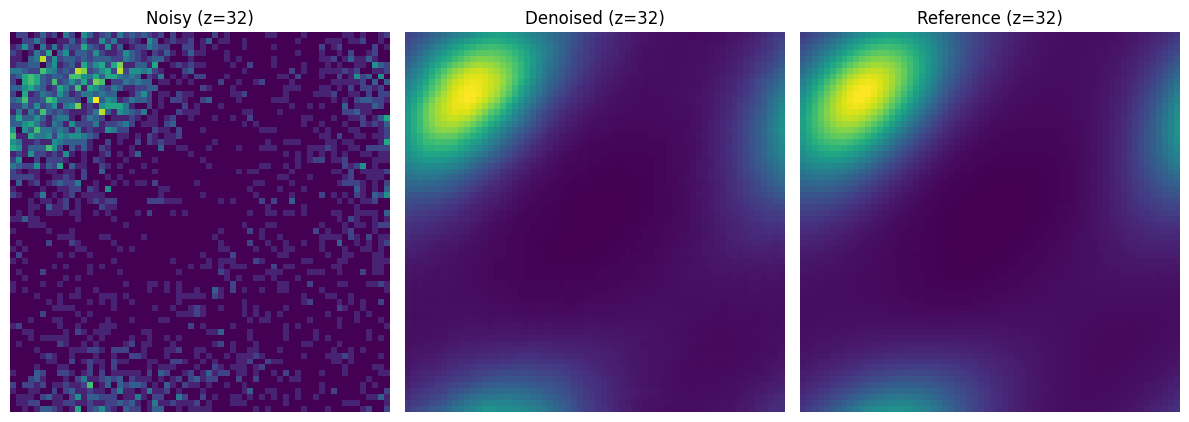

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000107
(64, 64, 64) (64, 64, 64) (64, 64, 64)


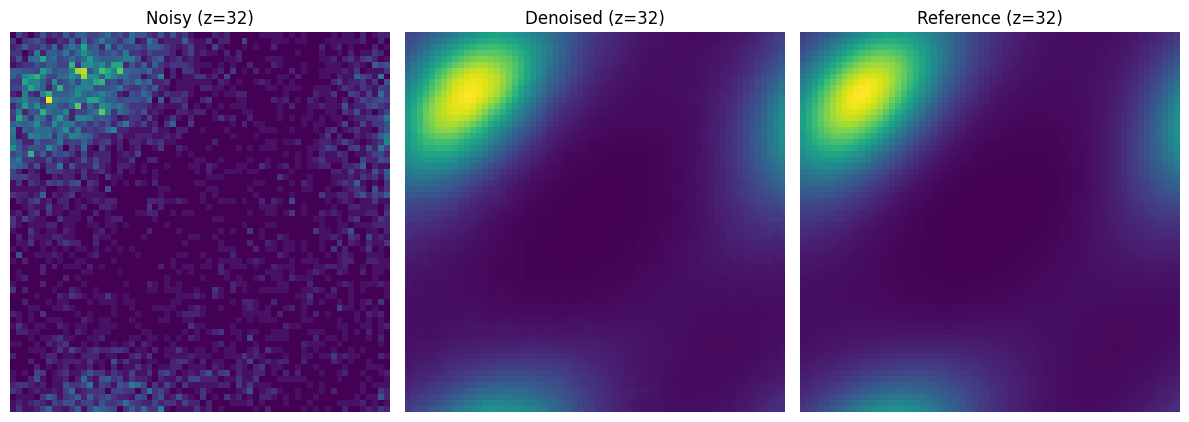

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000107
(64, 64, 64) (64, 64, 64) (64, 64, 64)


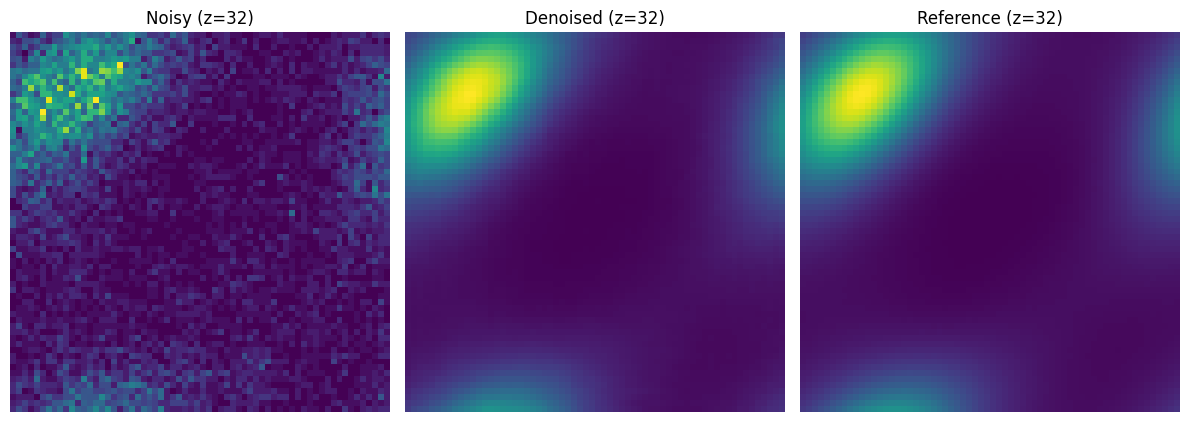

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


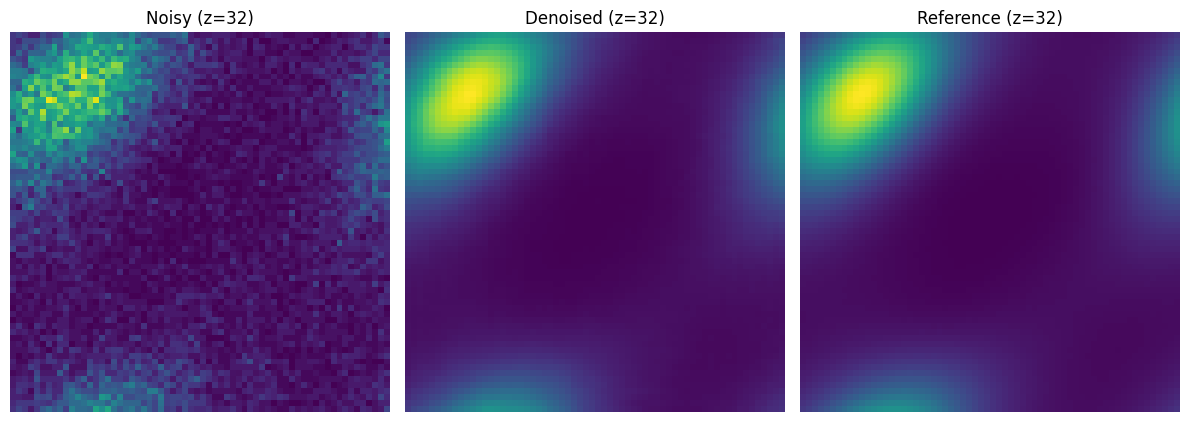

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


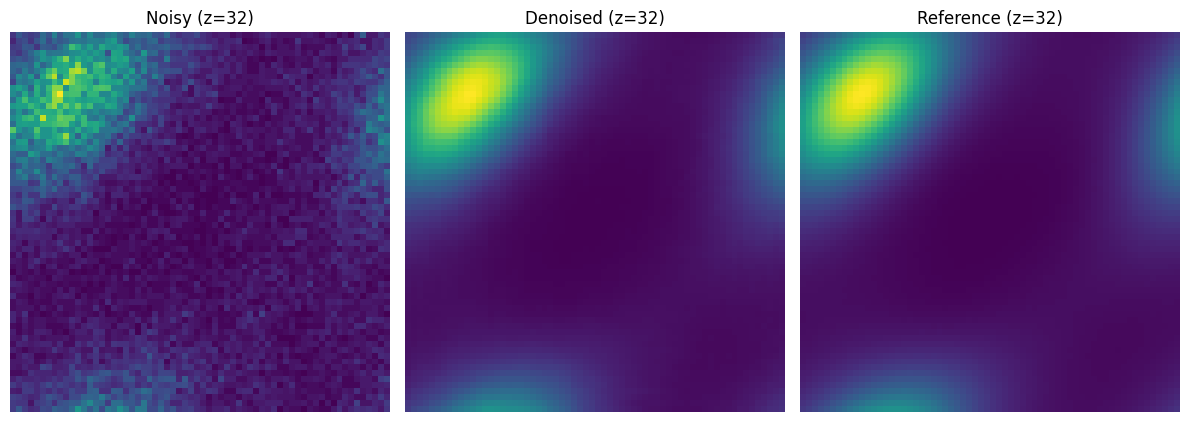

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


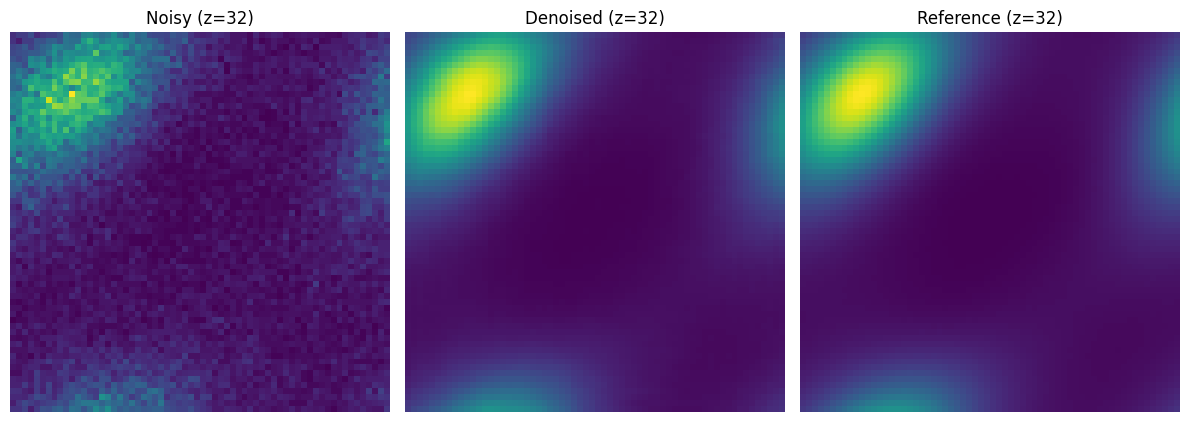

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


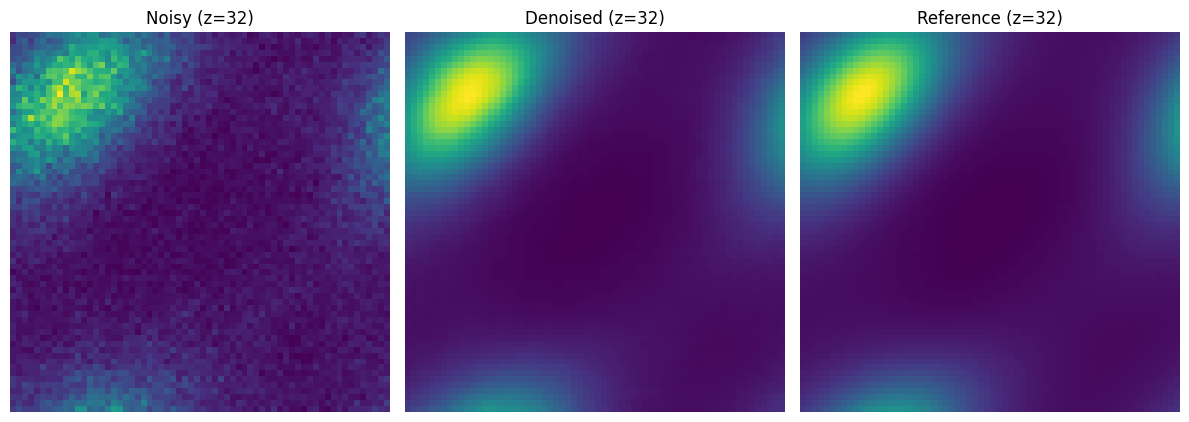

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


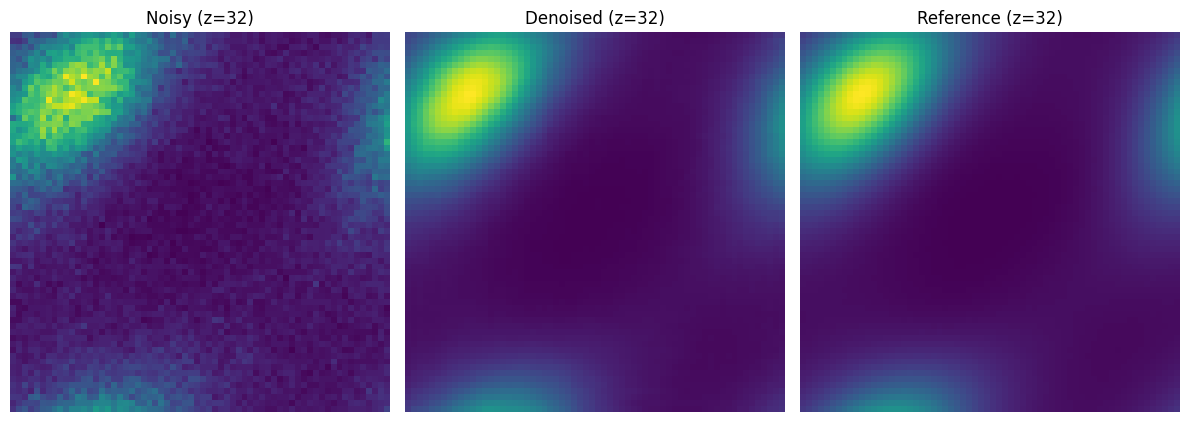

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


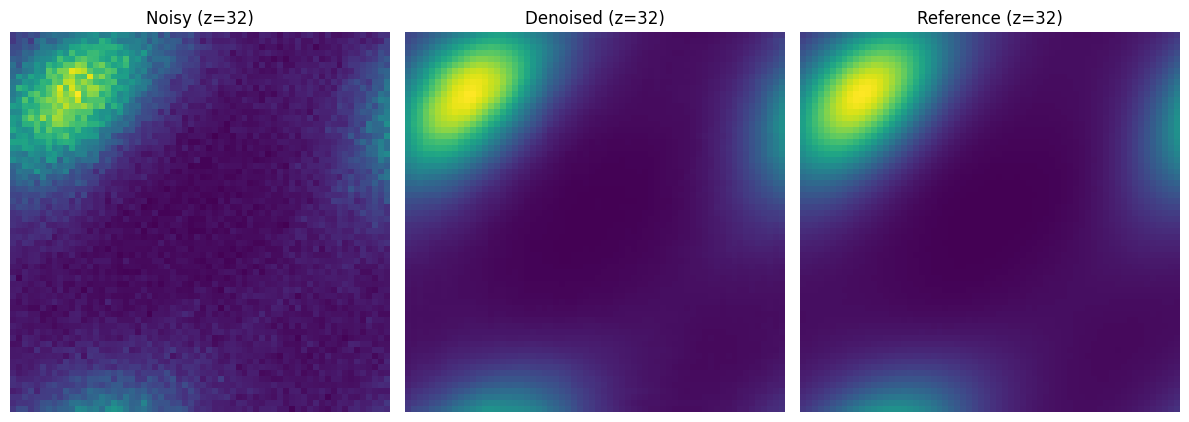

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


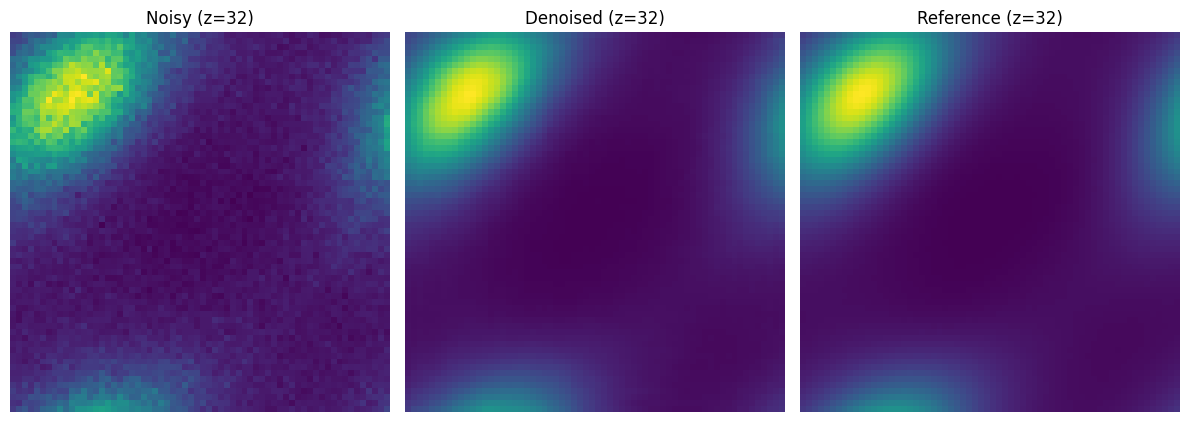

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


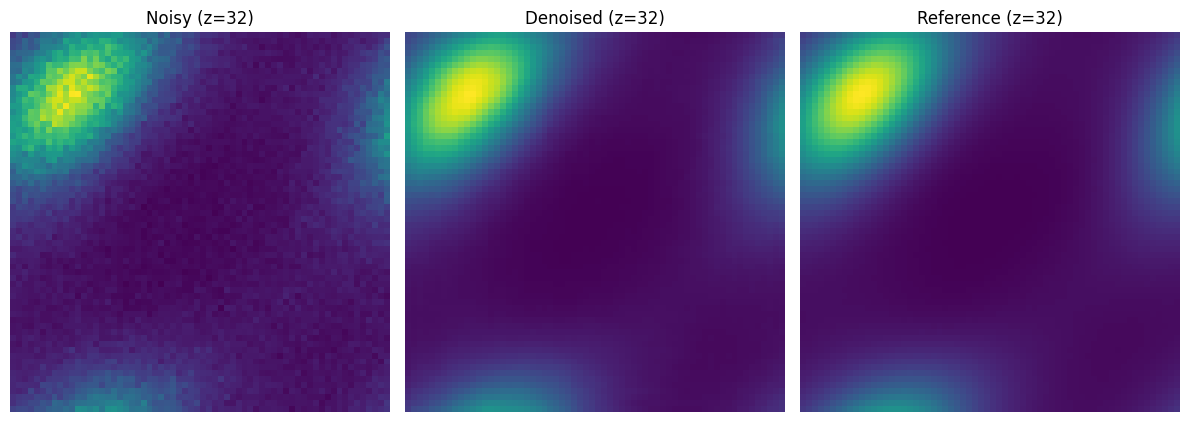

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


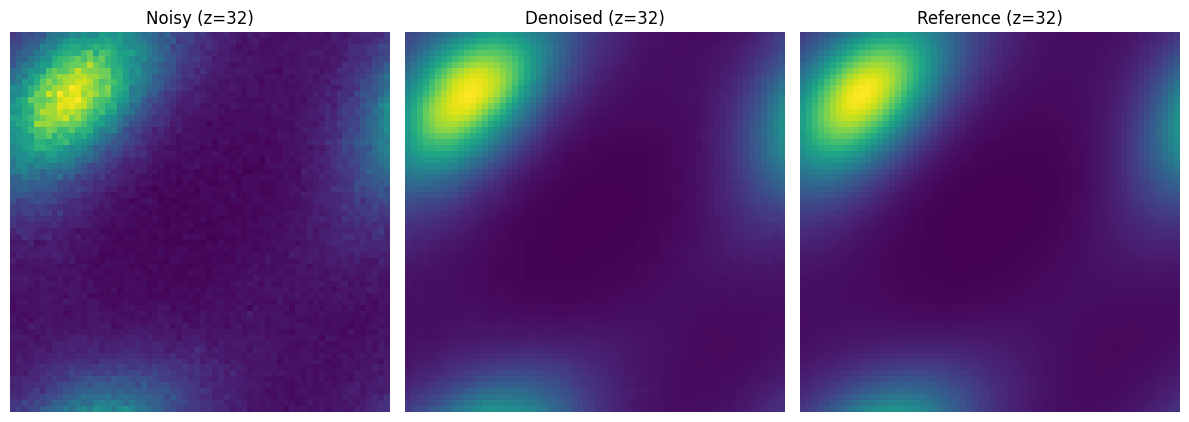

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


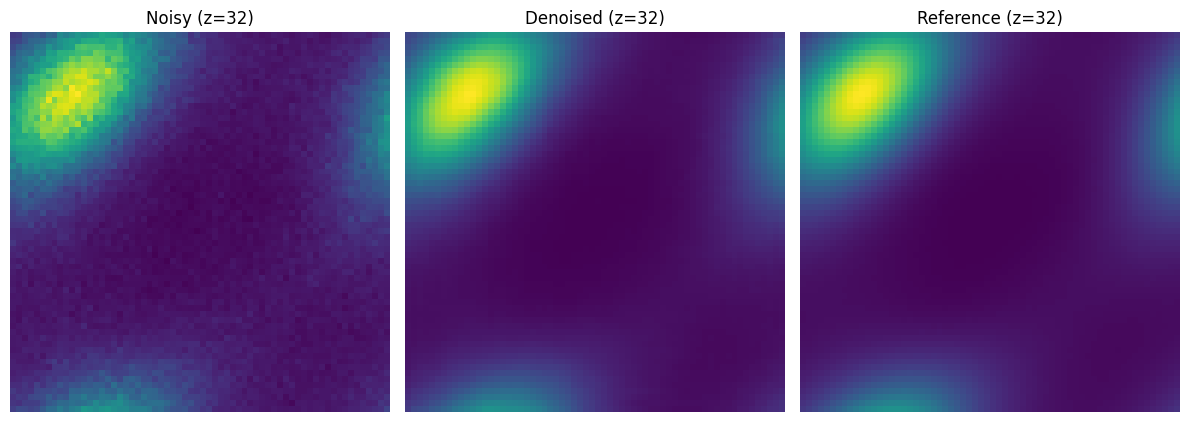

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


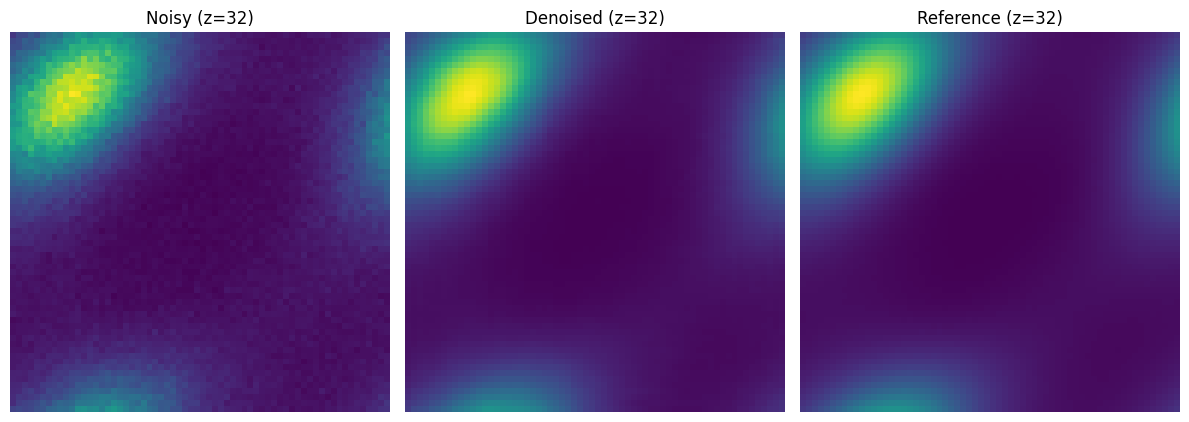

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


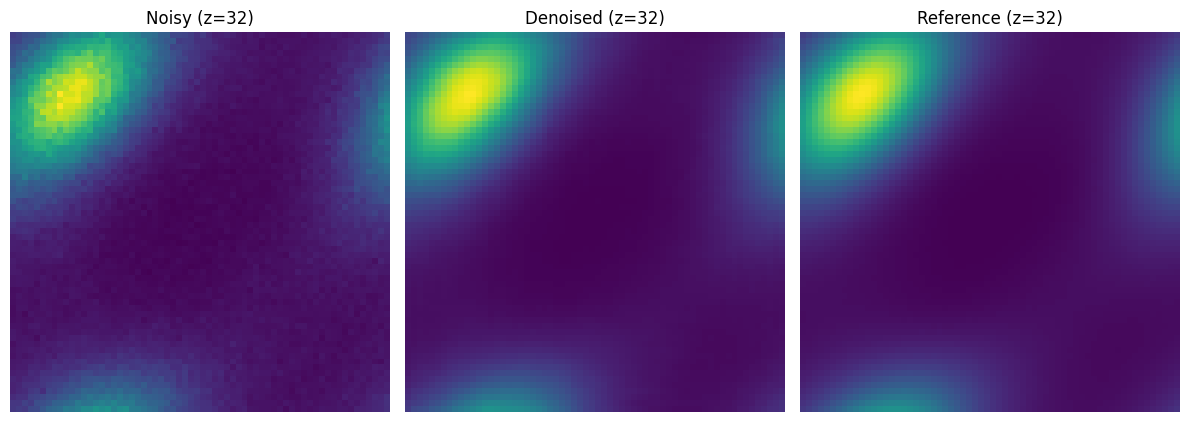

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


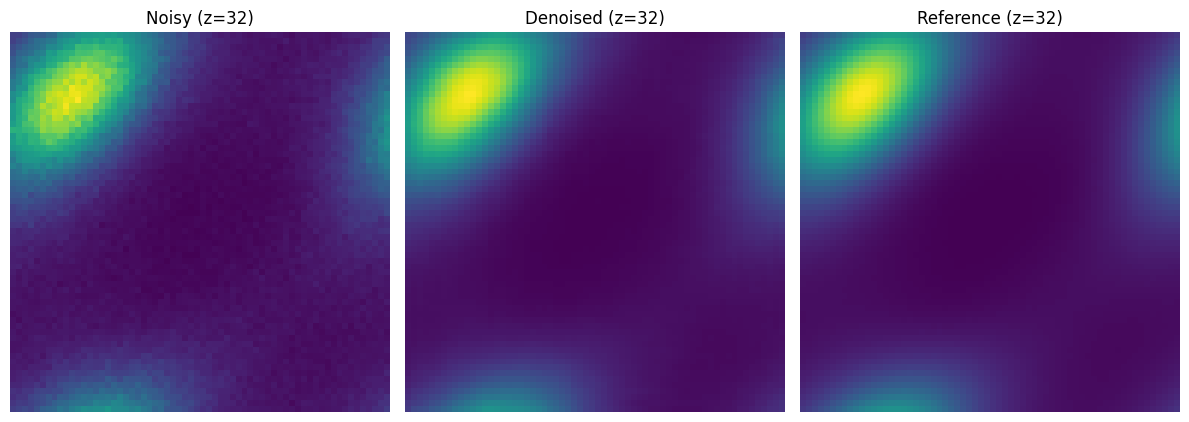

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


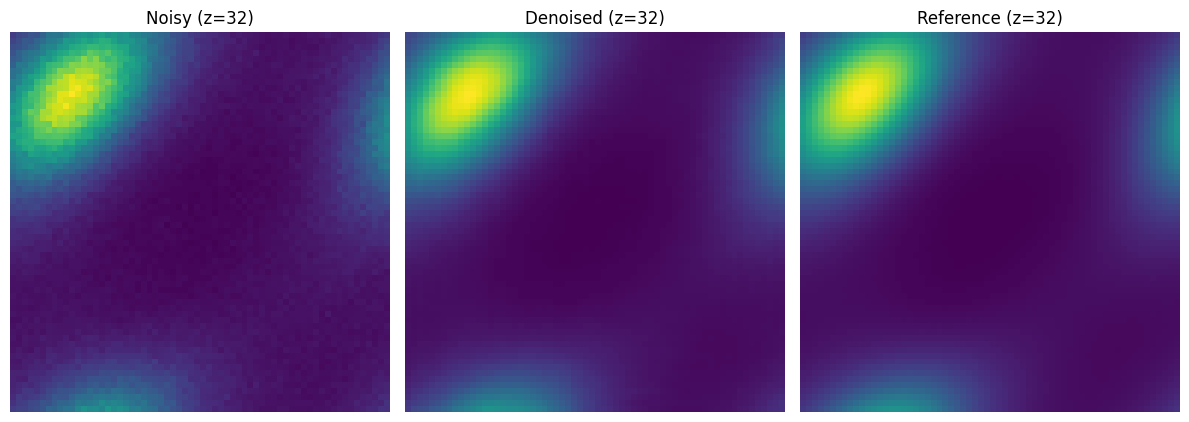

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


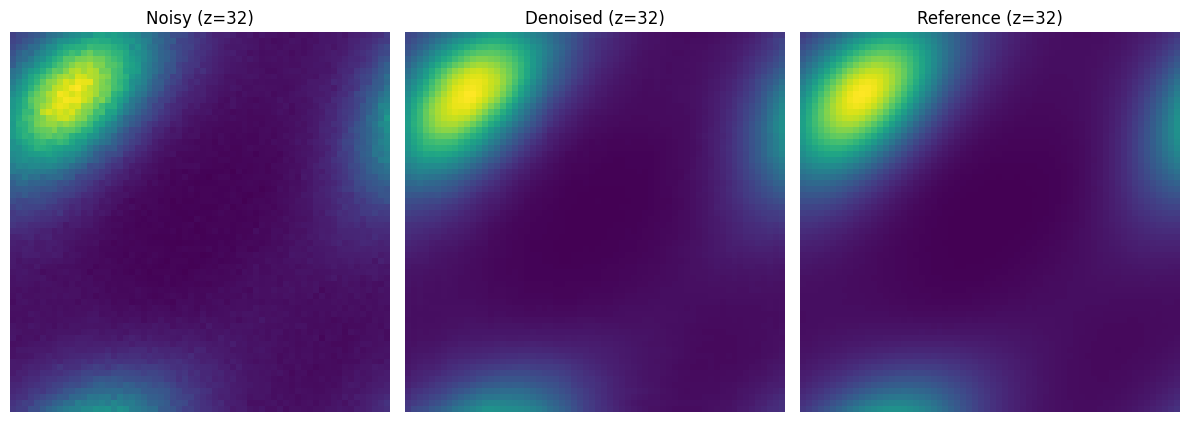

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


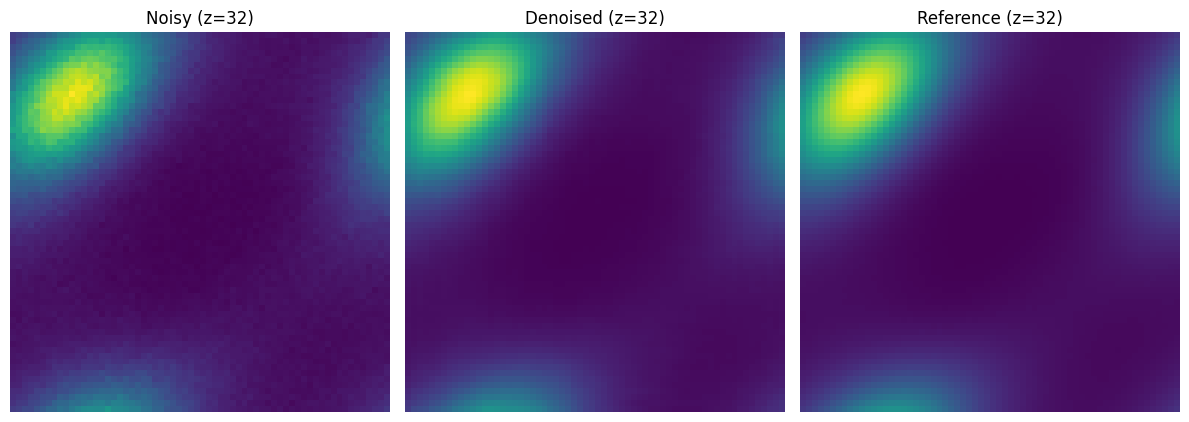

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


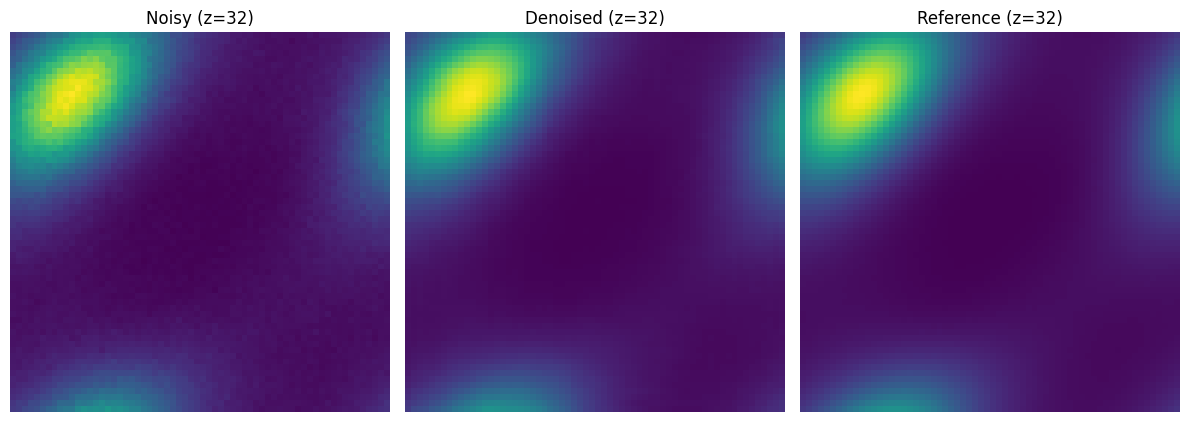

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


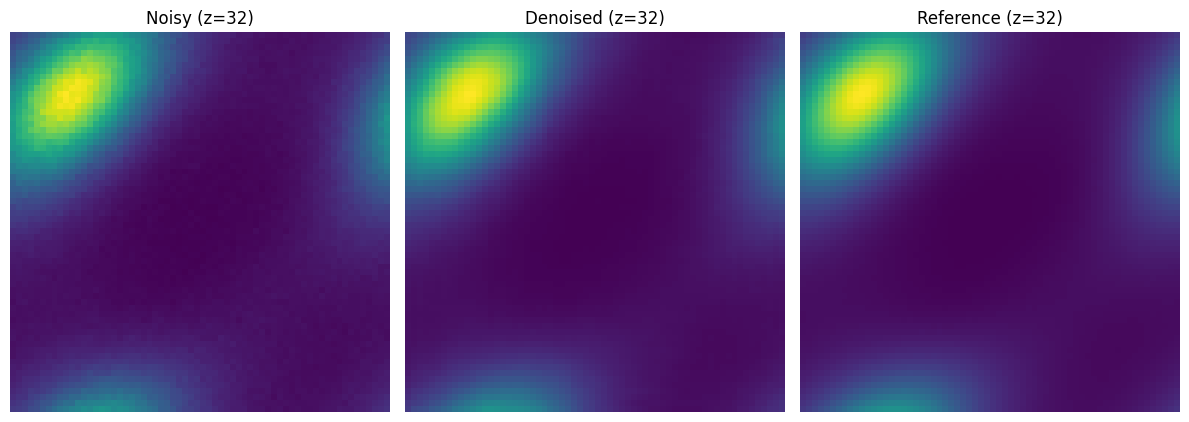

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


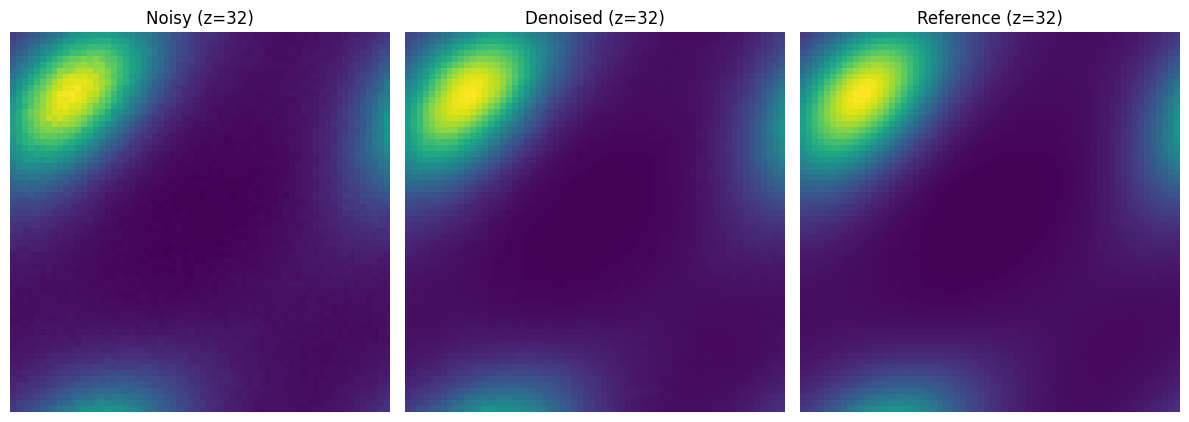

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


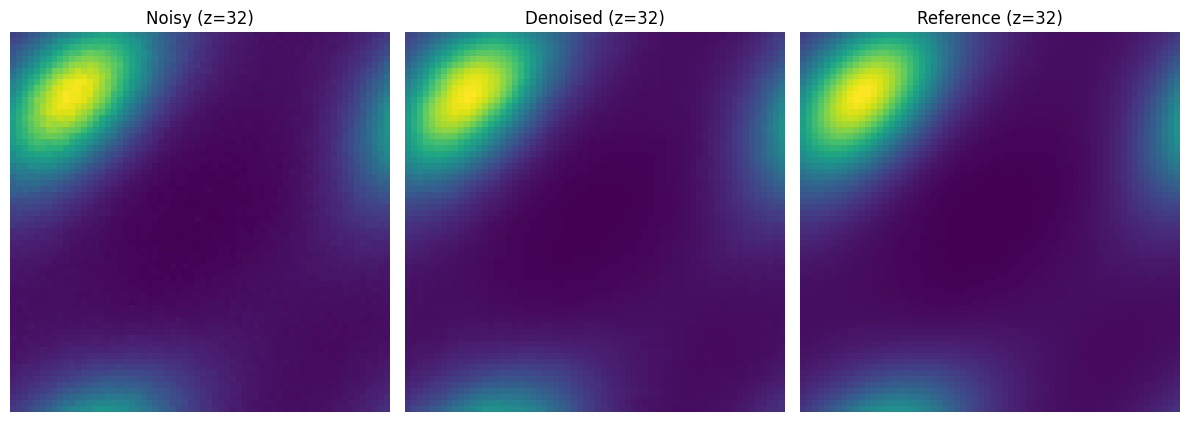

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


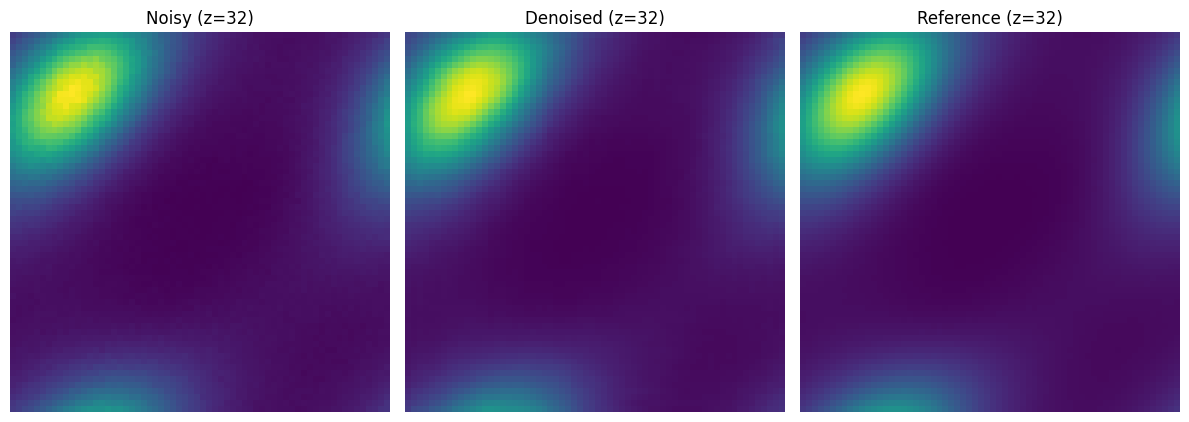

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


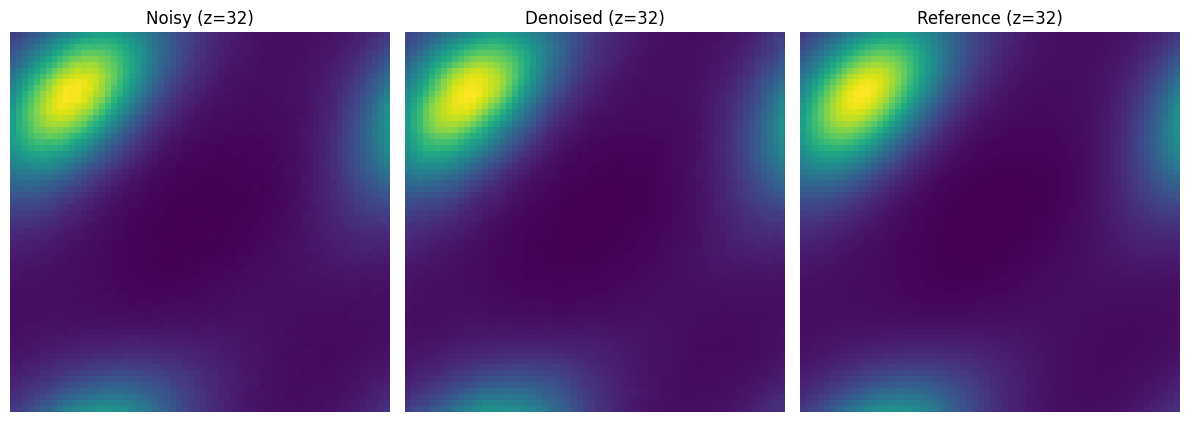

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


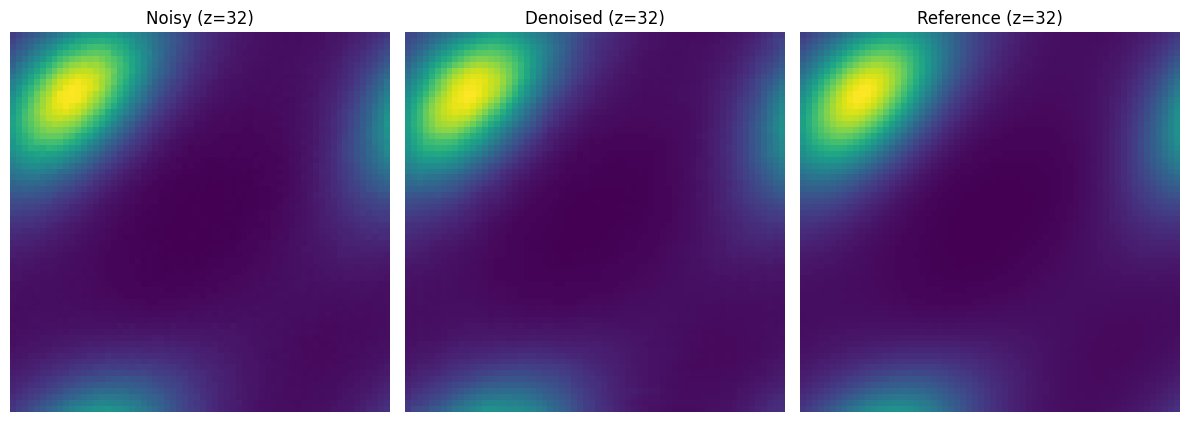

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


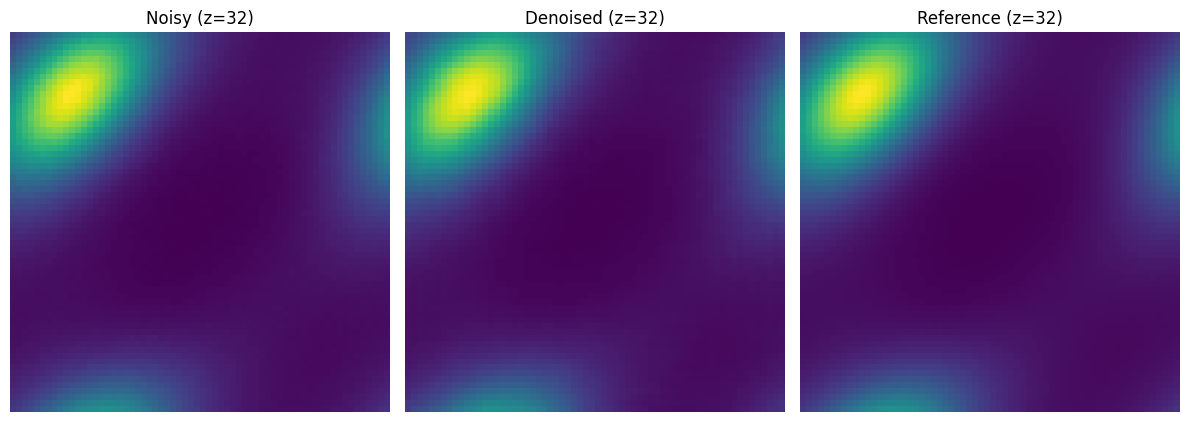

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


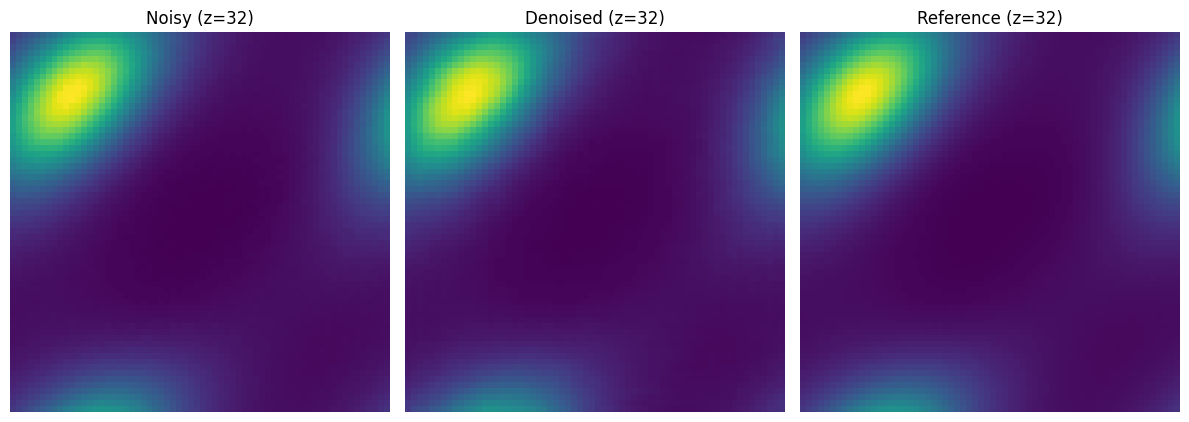

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


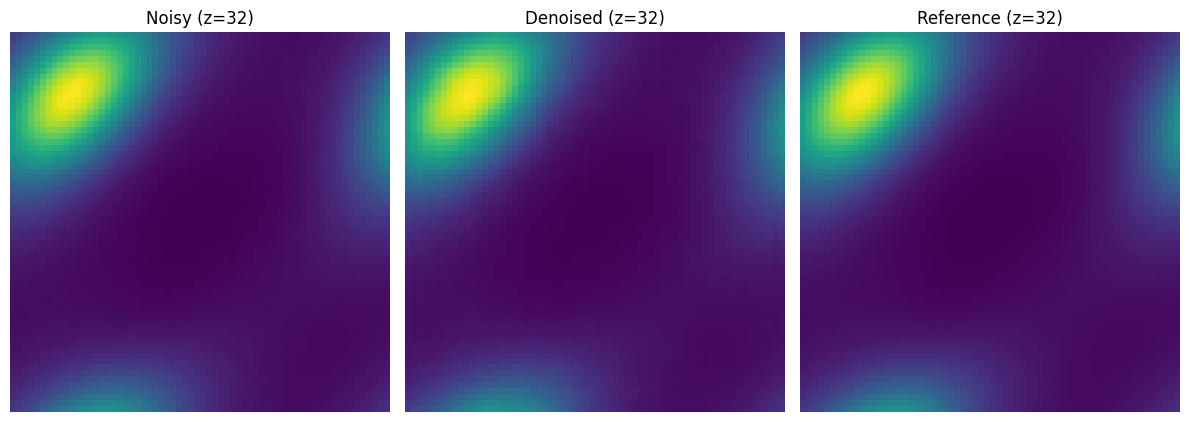

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


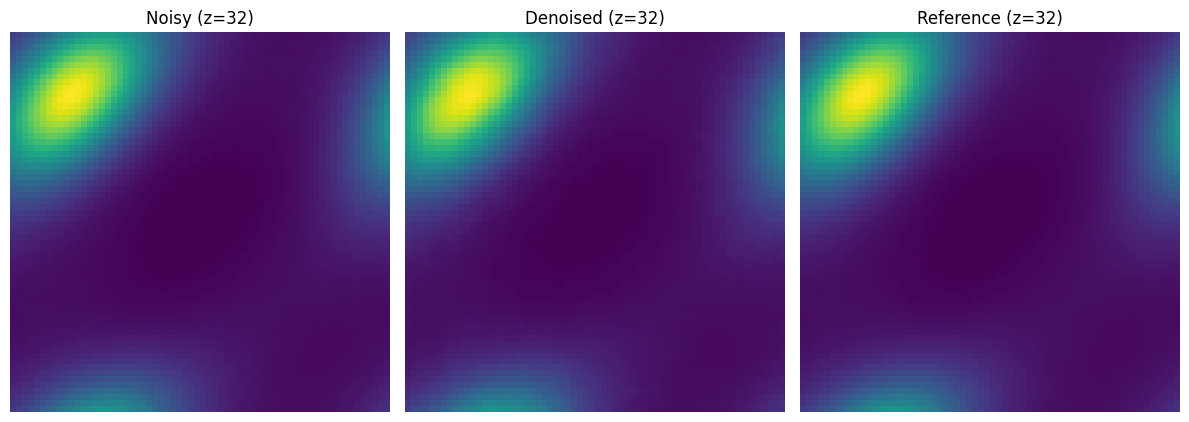

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


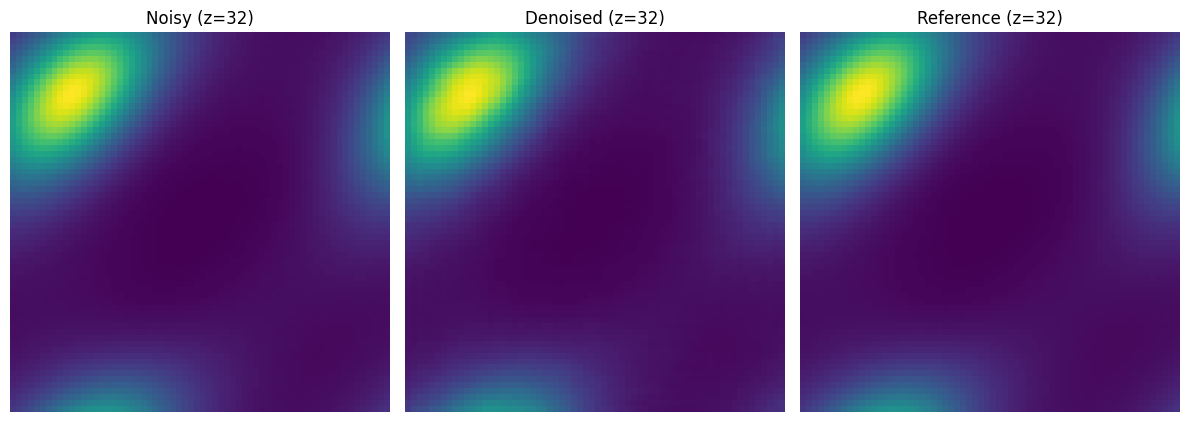

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000106
(64, 64, 64) (64, 64, 64) (64, 64, 64)


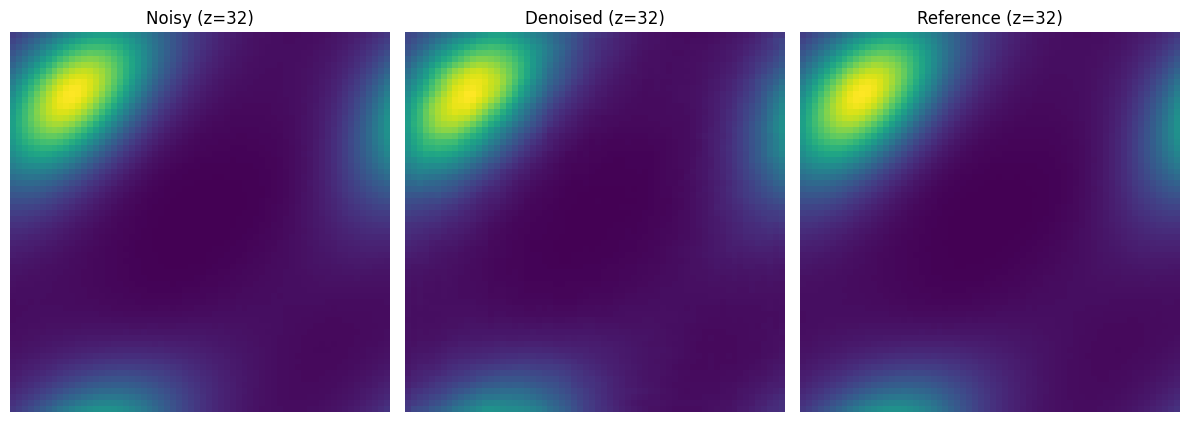


=== Running model: 23930000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 754ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000156
(64, 64, 64) (64, 64, 64) (64, 64, 64)


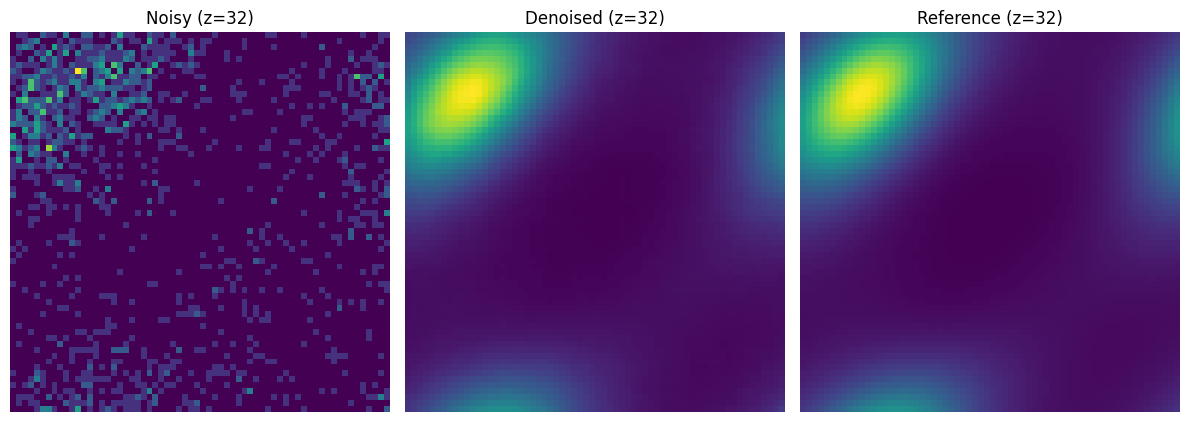

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


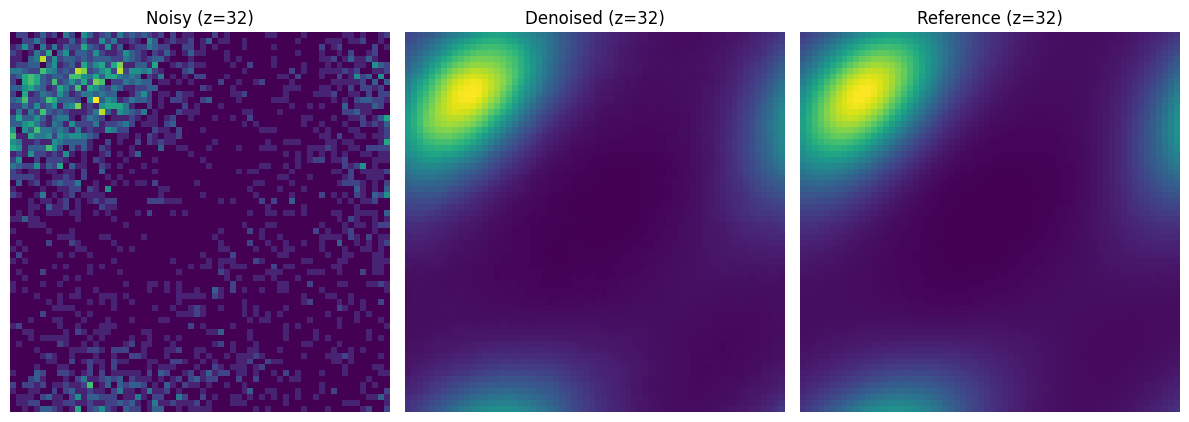

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


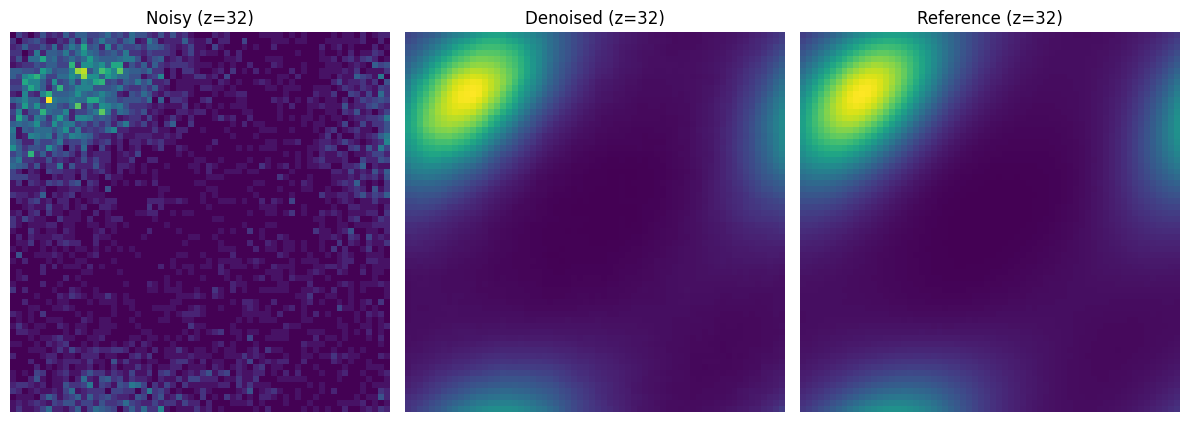

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


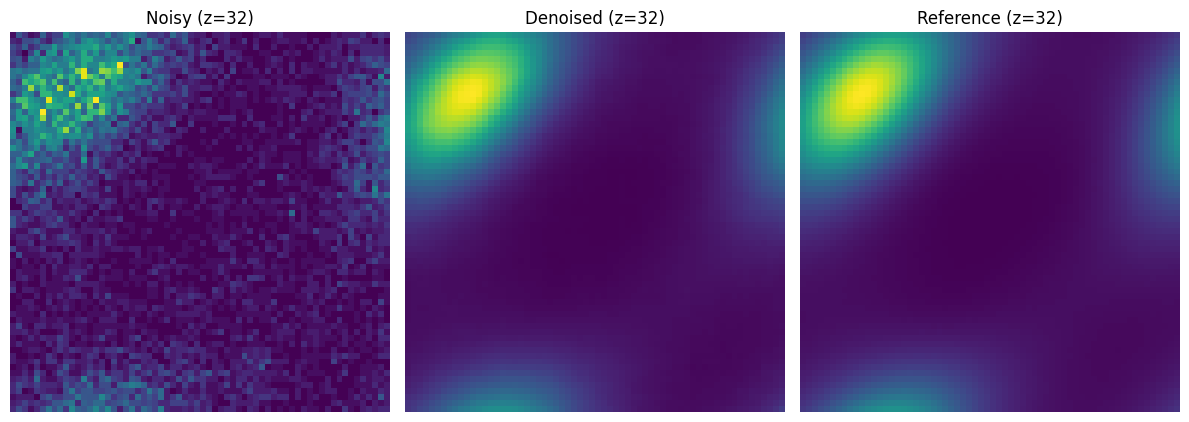

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


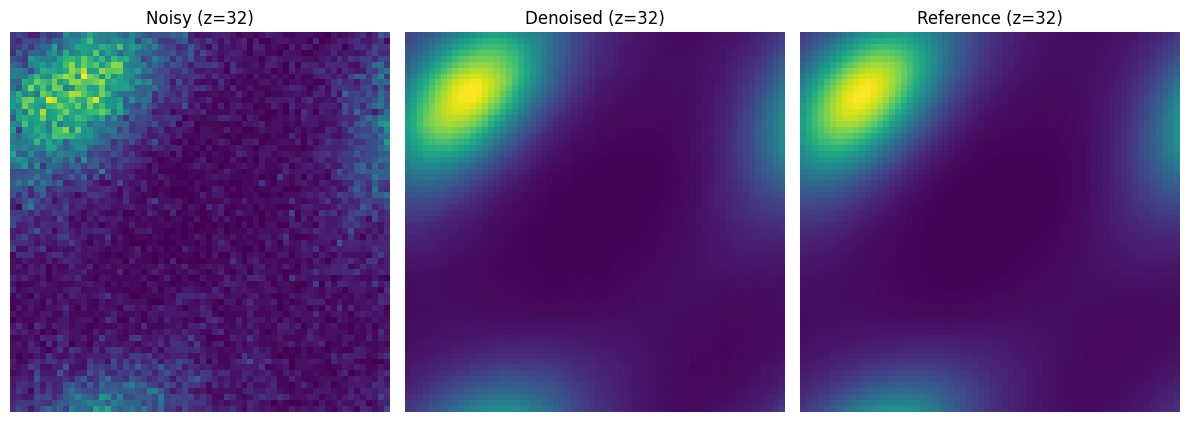

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000153
(64, 64, 64) (64, 64, 64) (64, 64, 64)


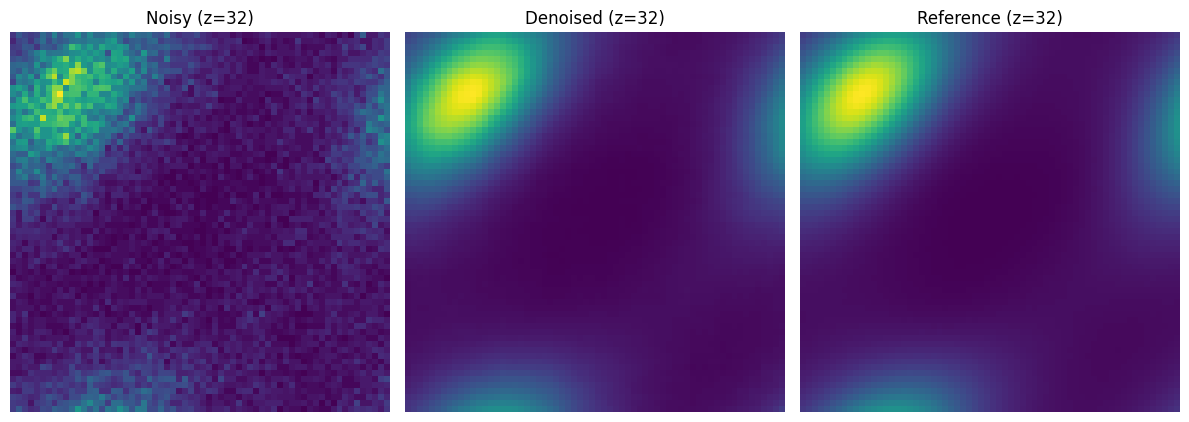

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


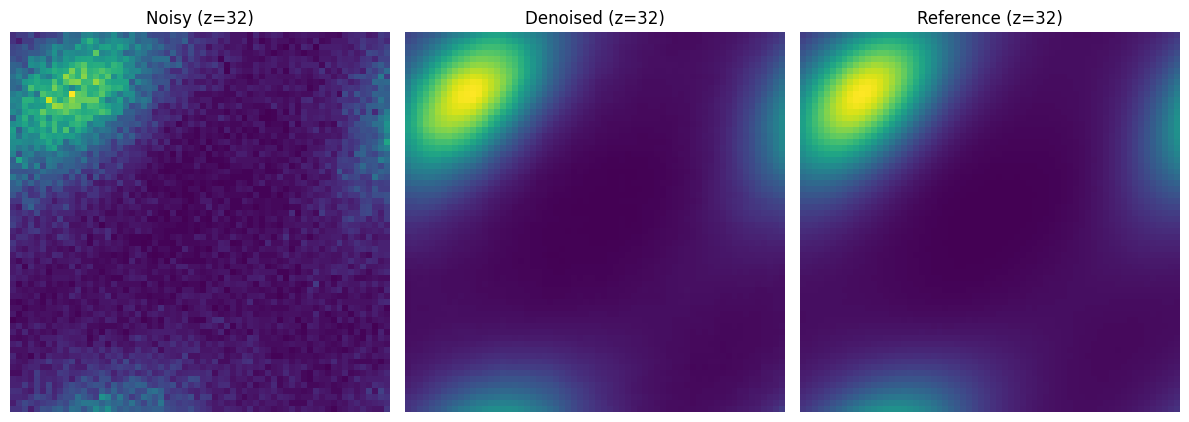

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


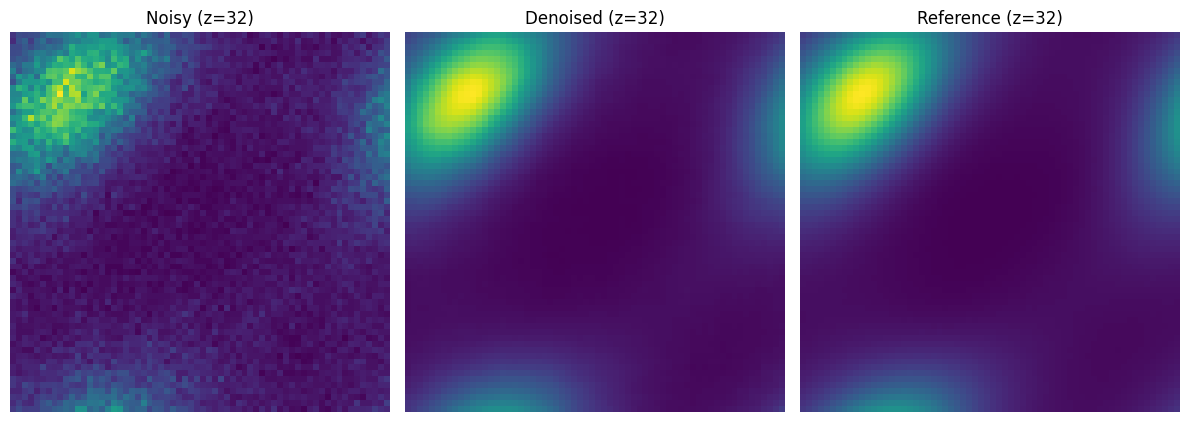

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


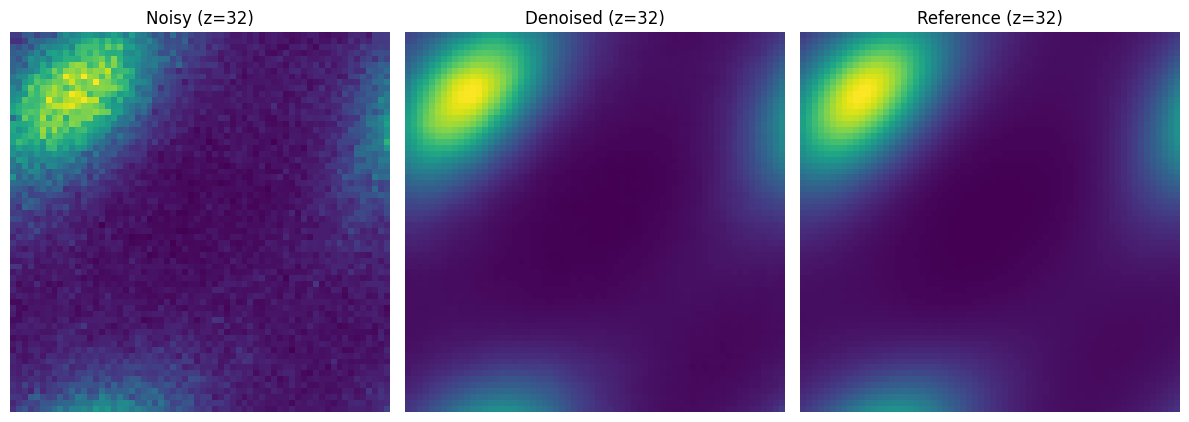

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


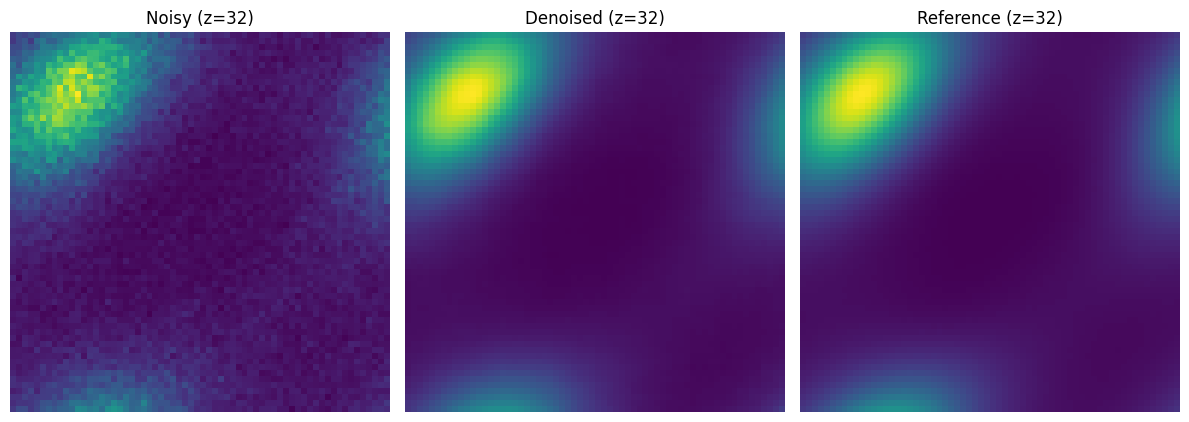

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


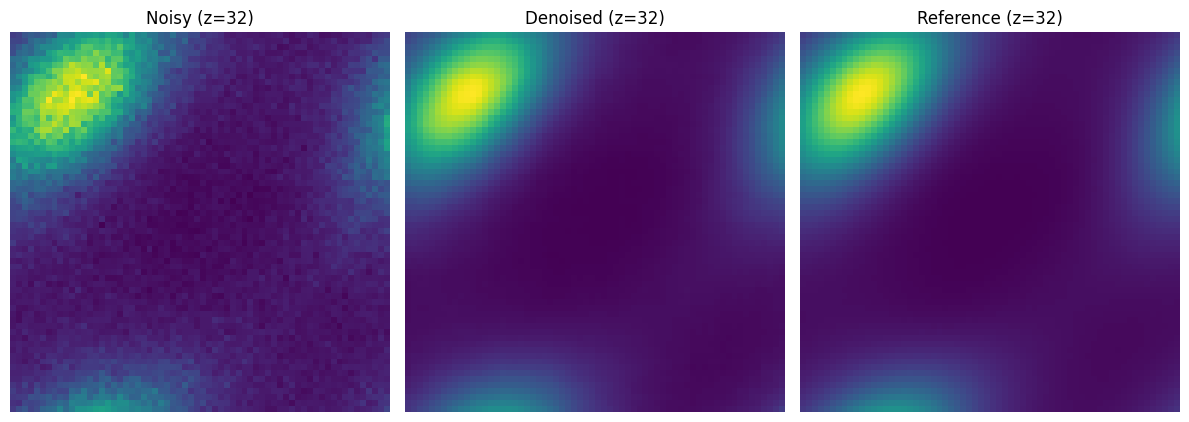

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


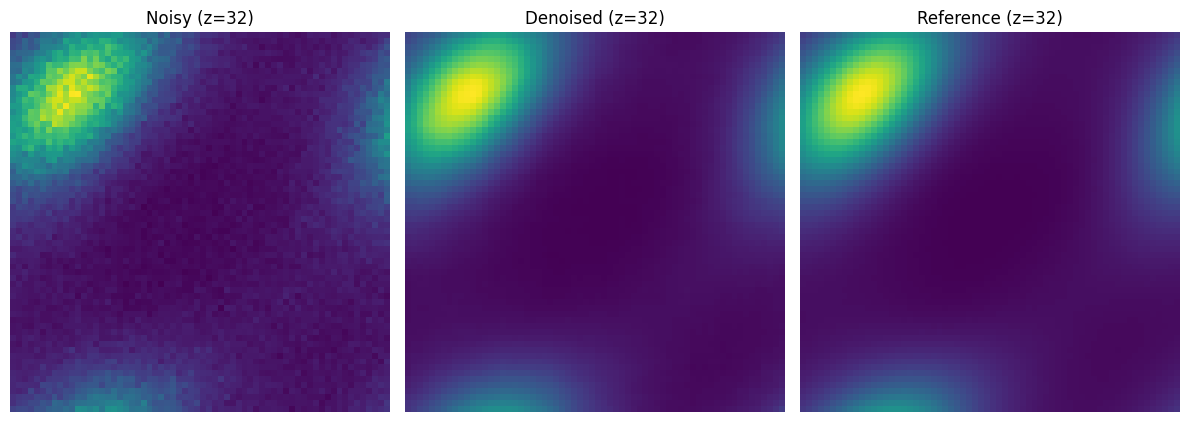

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


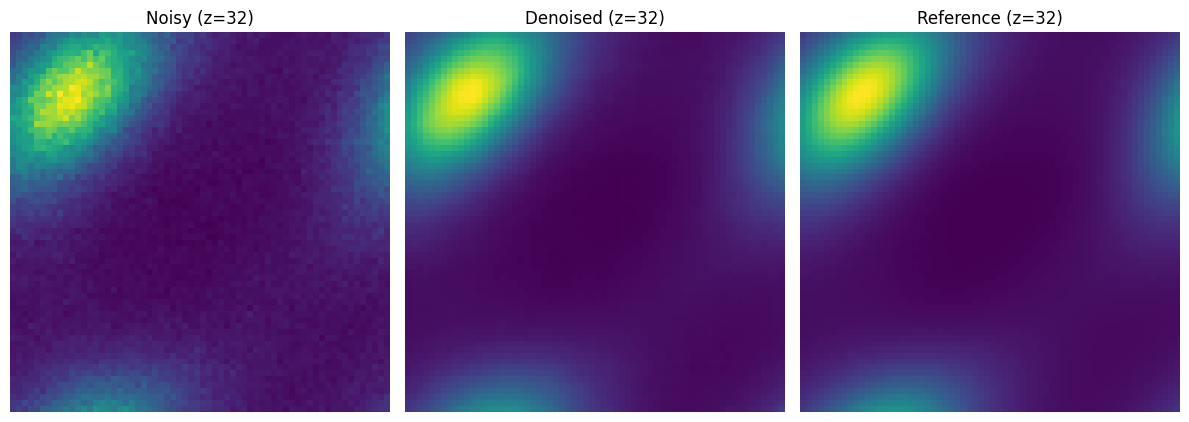

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


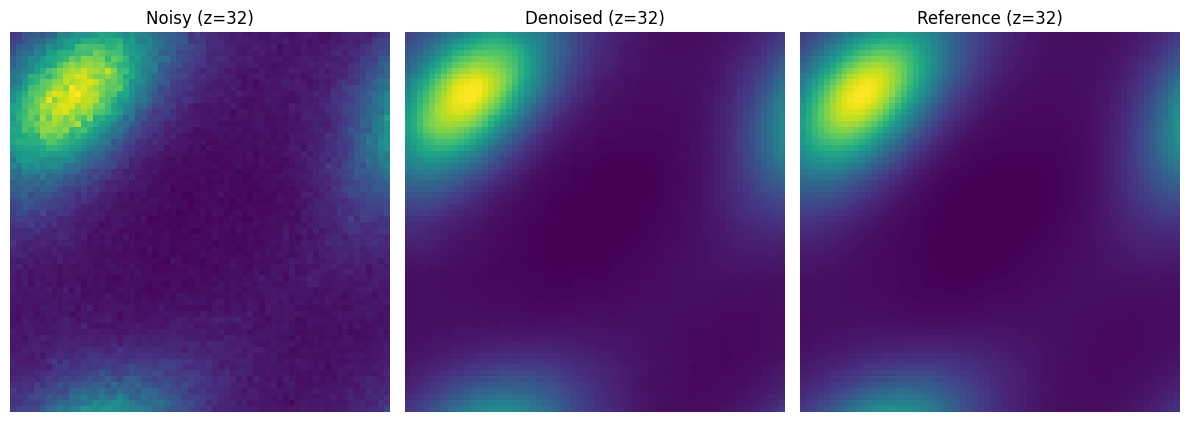

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


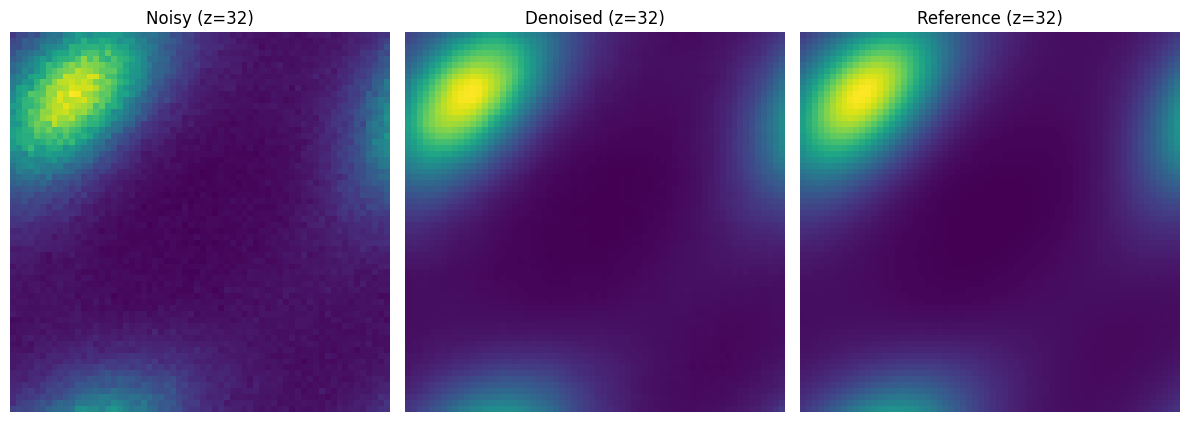

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


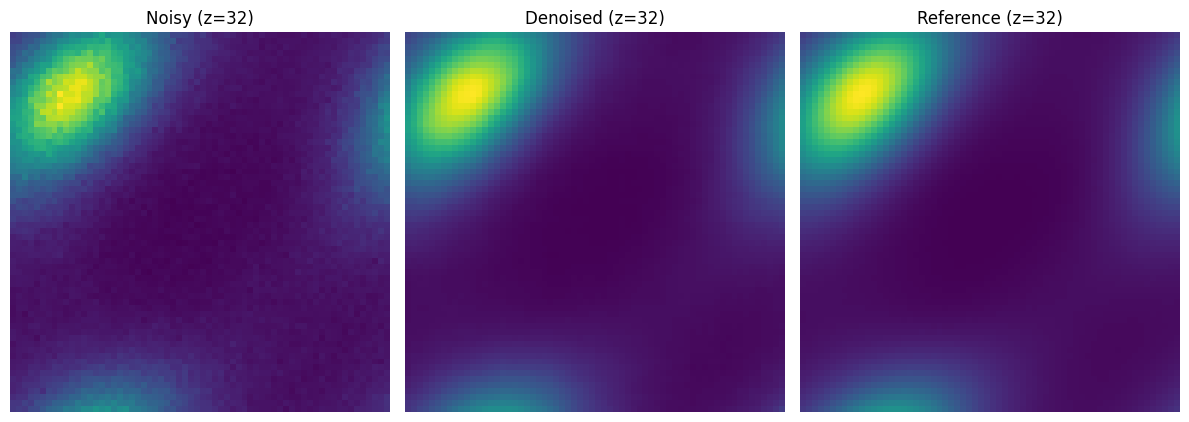

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


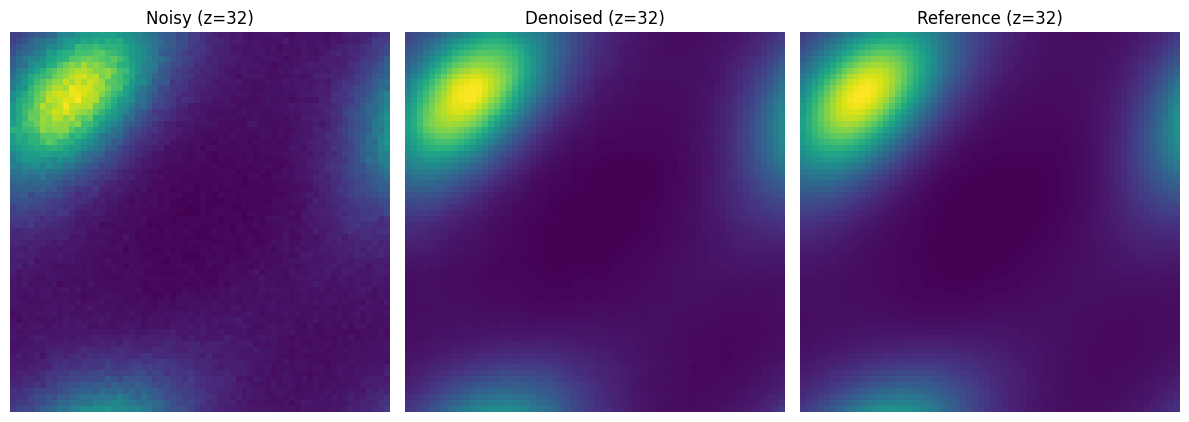

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


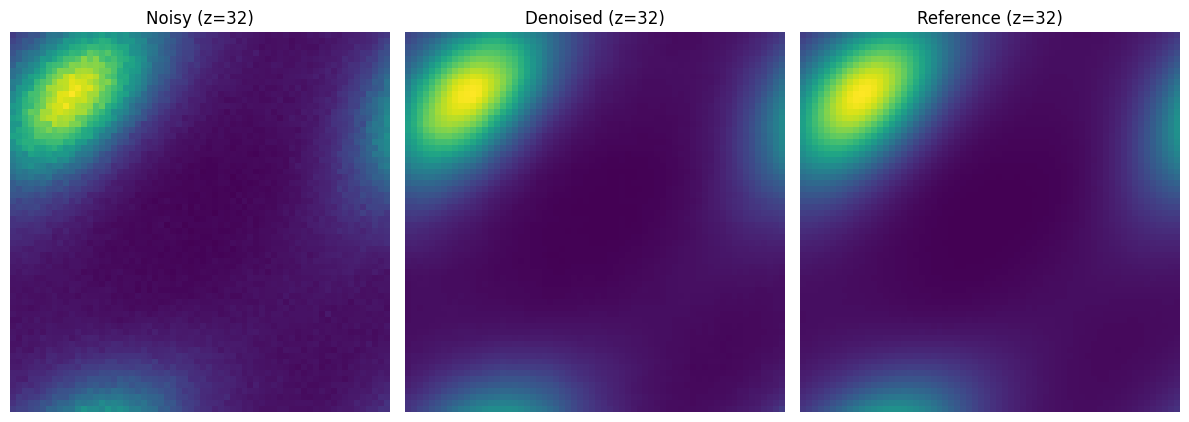

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


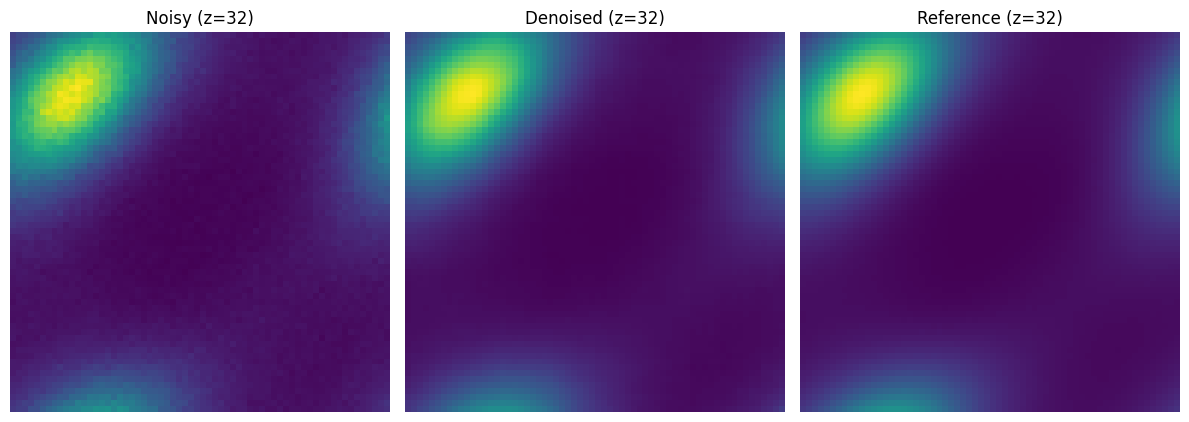

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


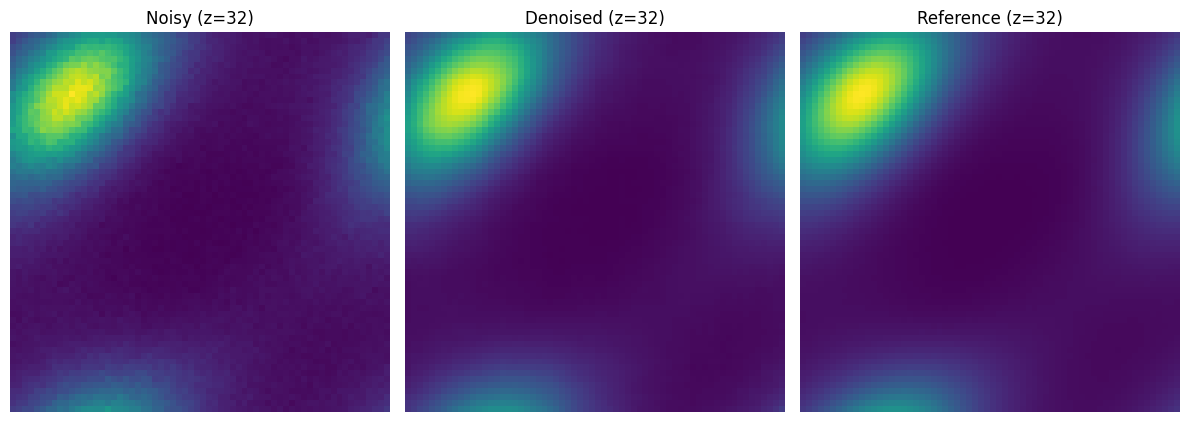

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


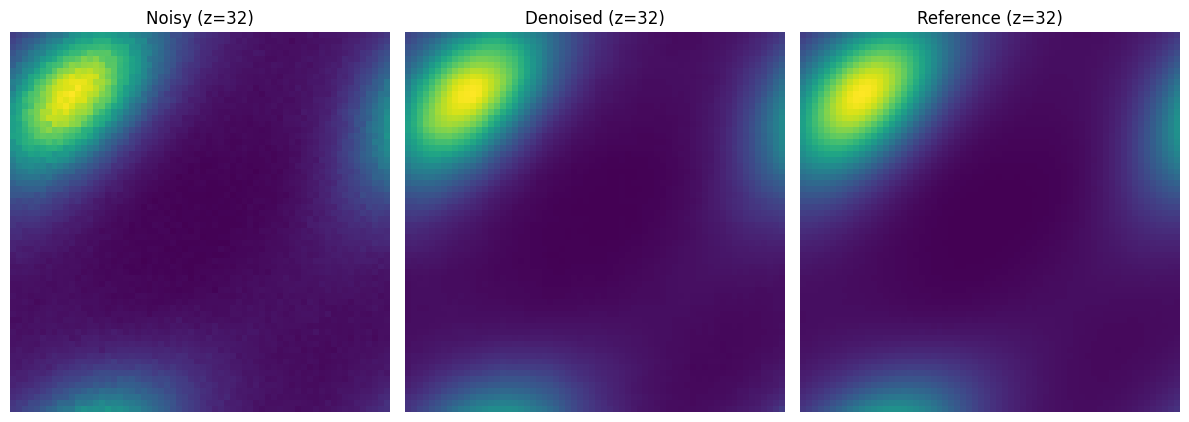

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


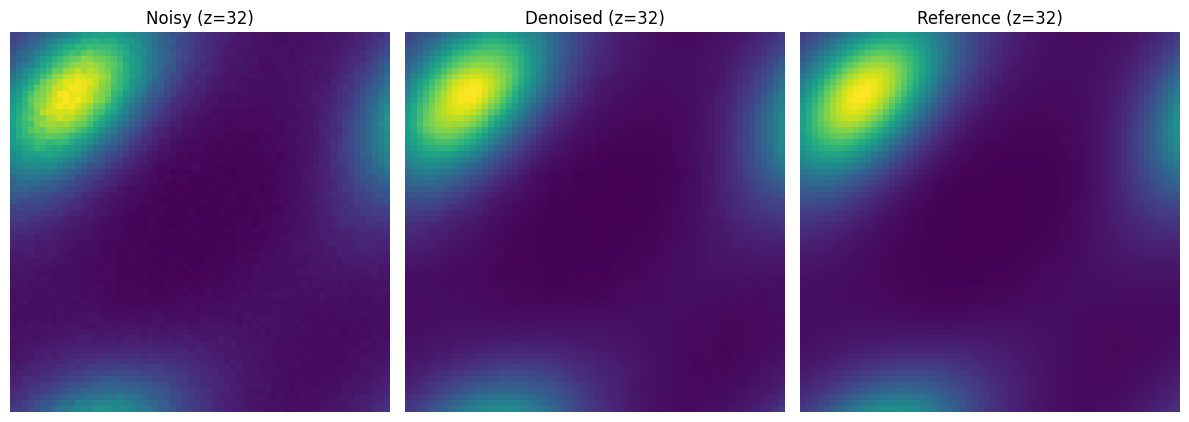

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


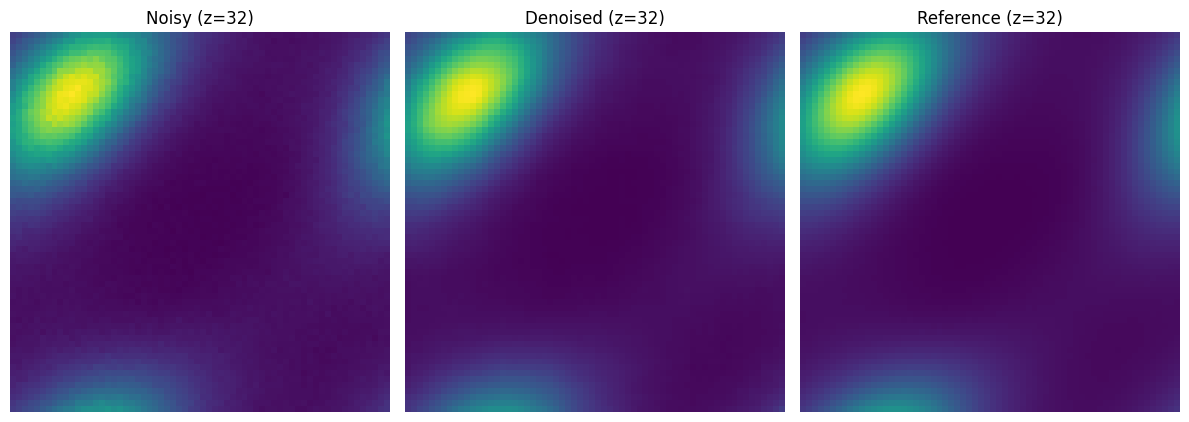

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


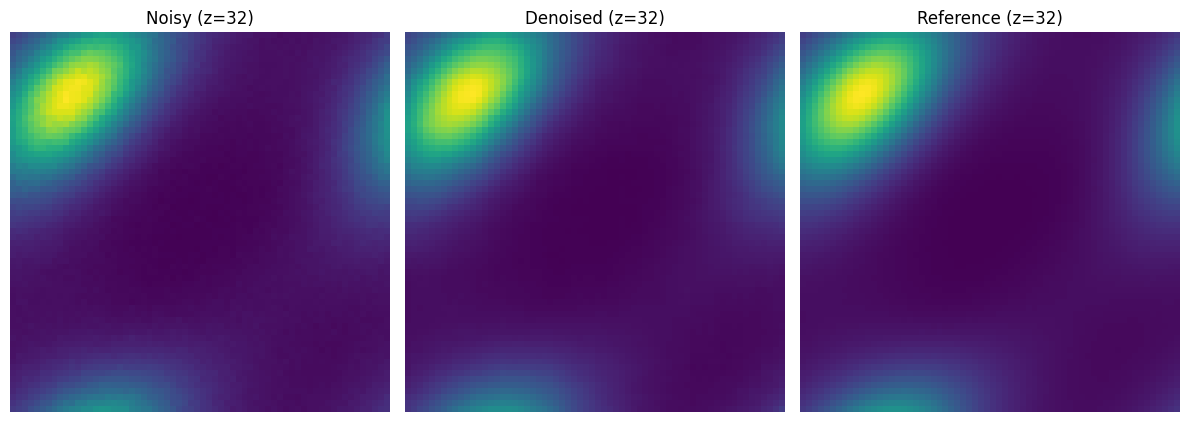

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


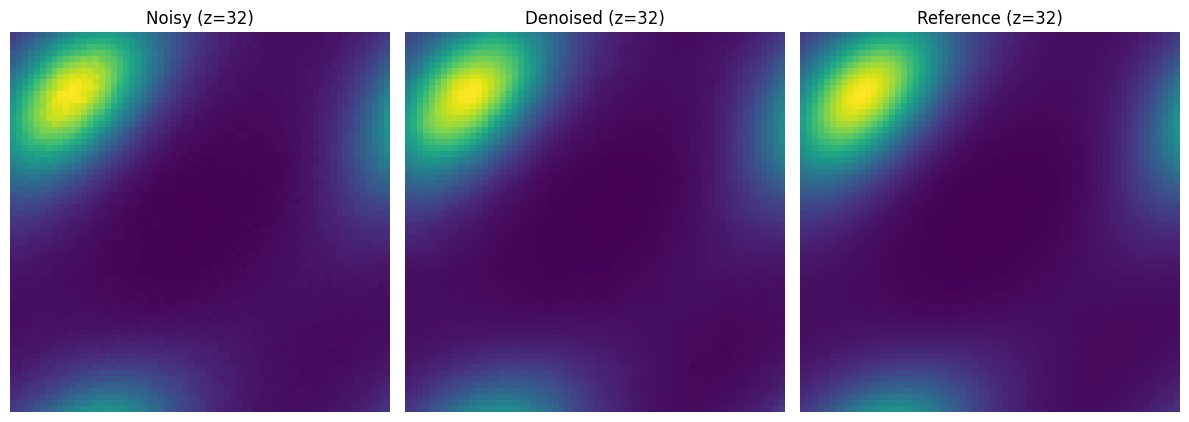

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


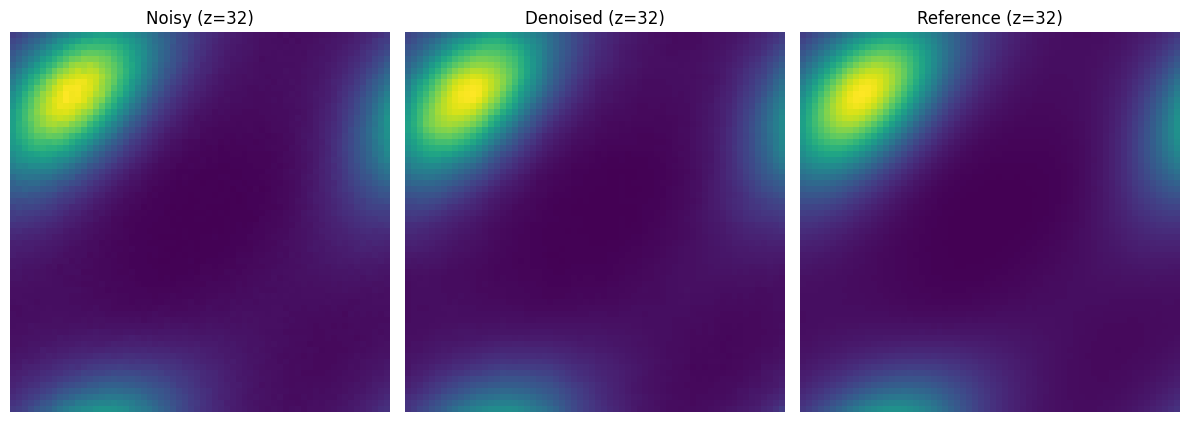

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


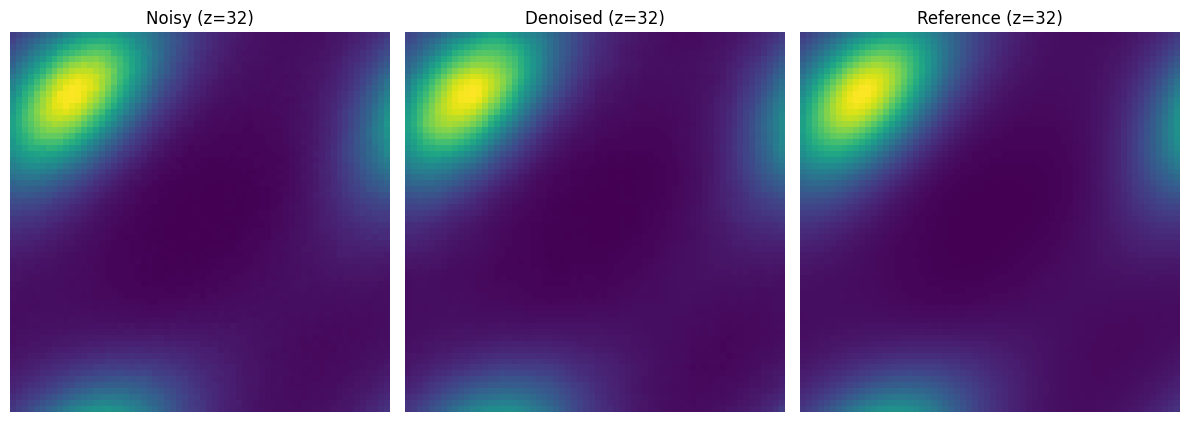

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


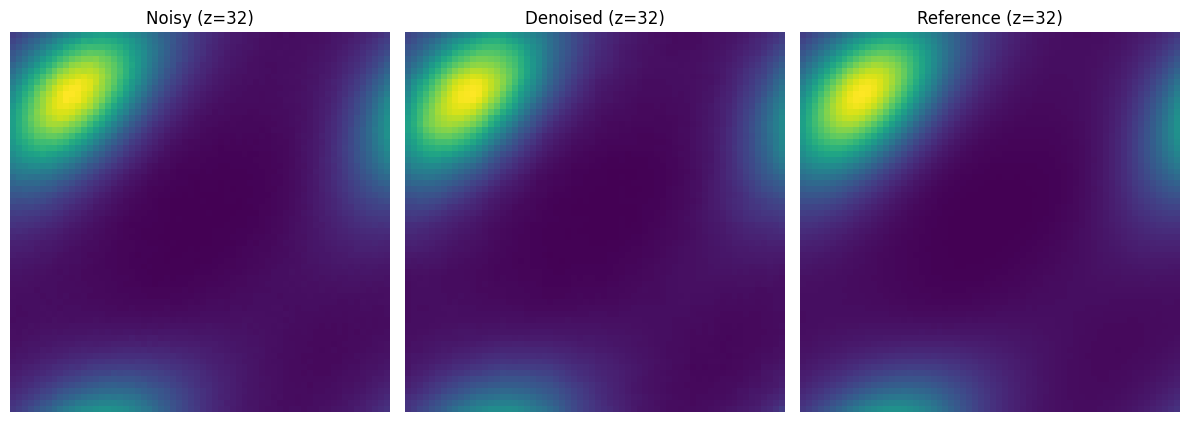

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


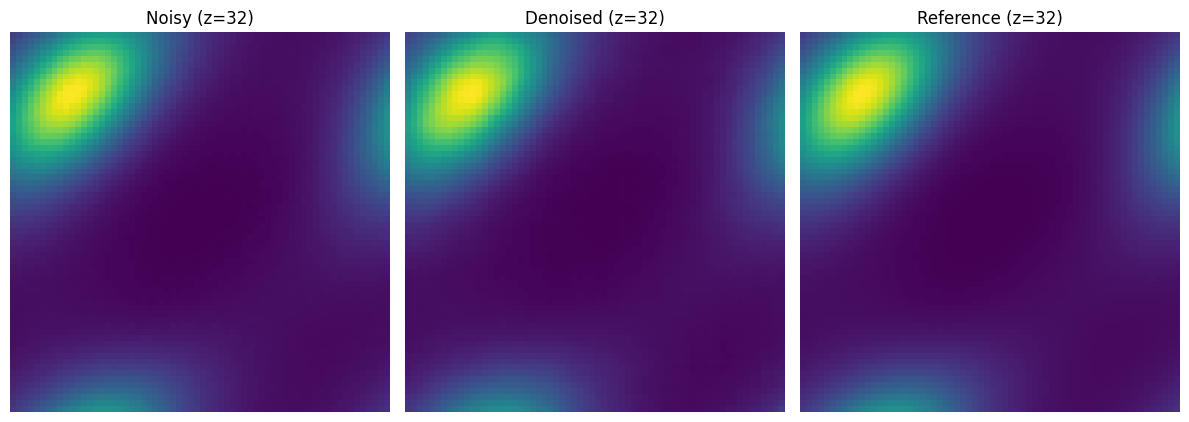

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


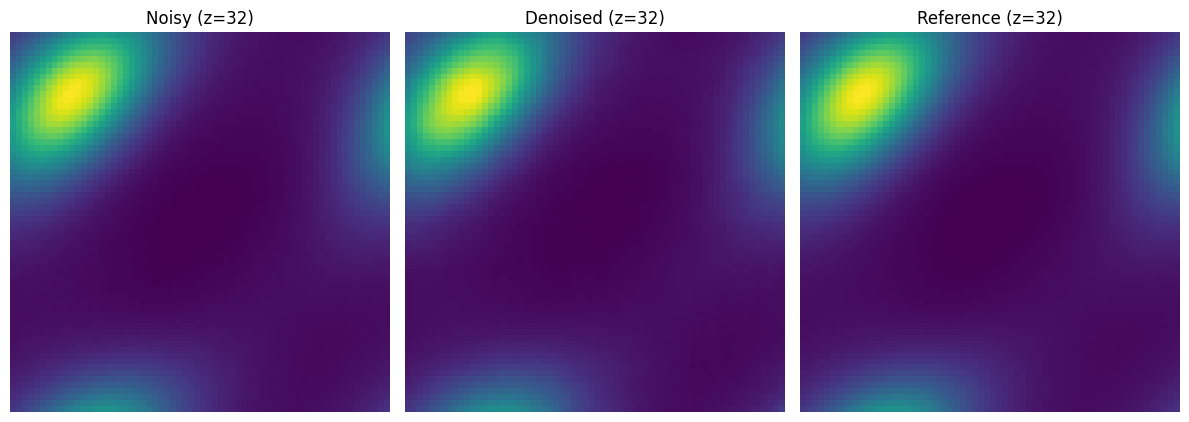

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000154
(64, 64, 64) (64, 64, 64) (64, 64, 64)


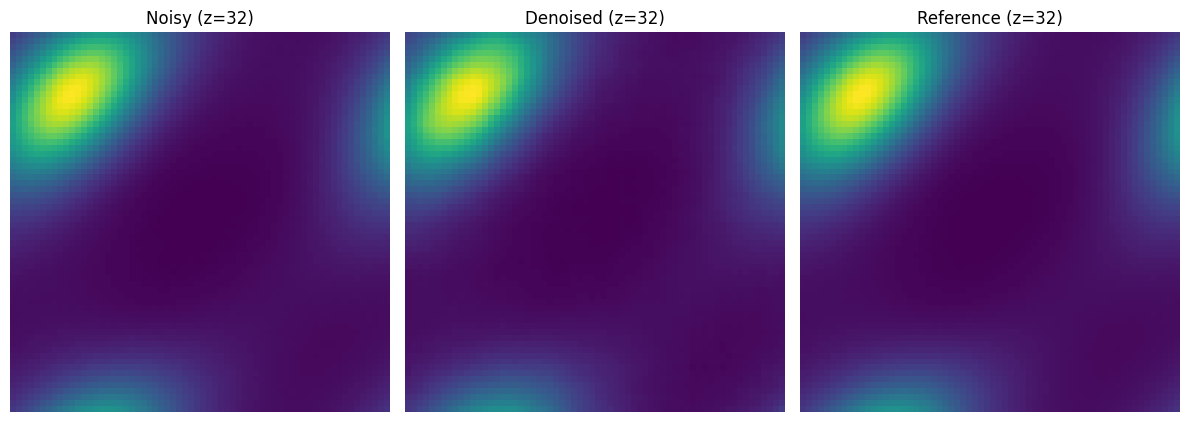

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


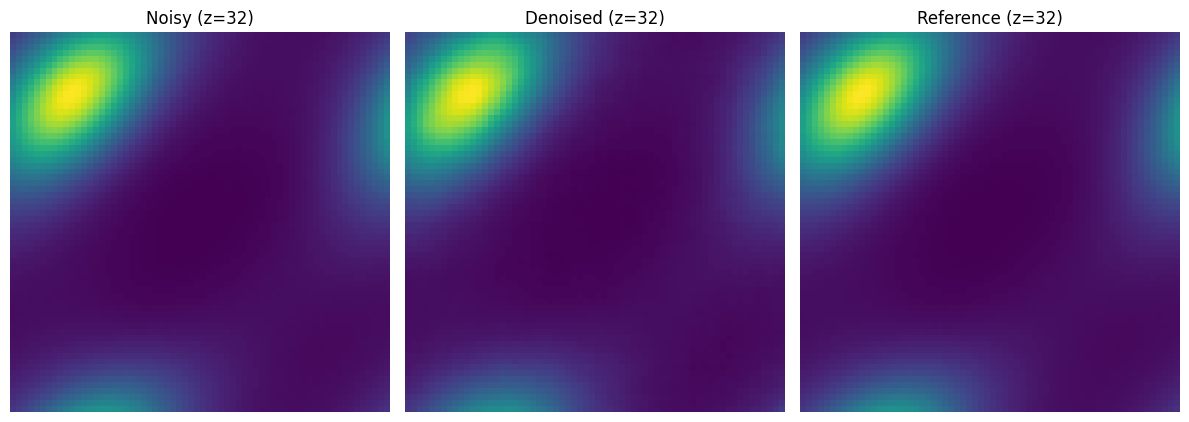

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000155
(64, 64, 64) (64, 64, 64) (64, 64, 64)


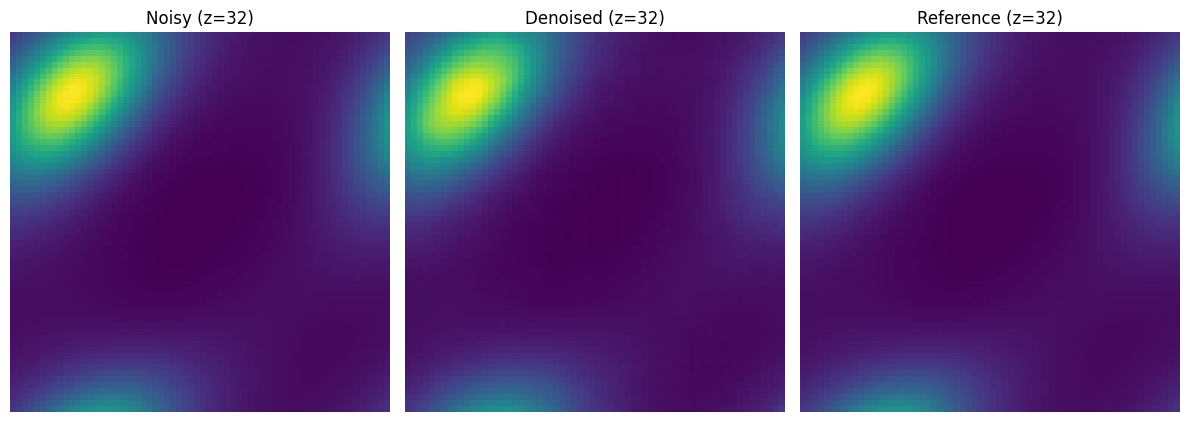


=== Running model: 240700000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000130
(64, 64, 64) (64, 64, 64) (64, 64, 64)


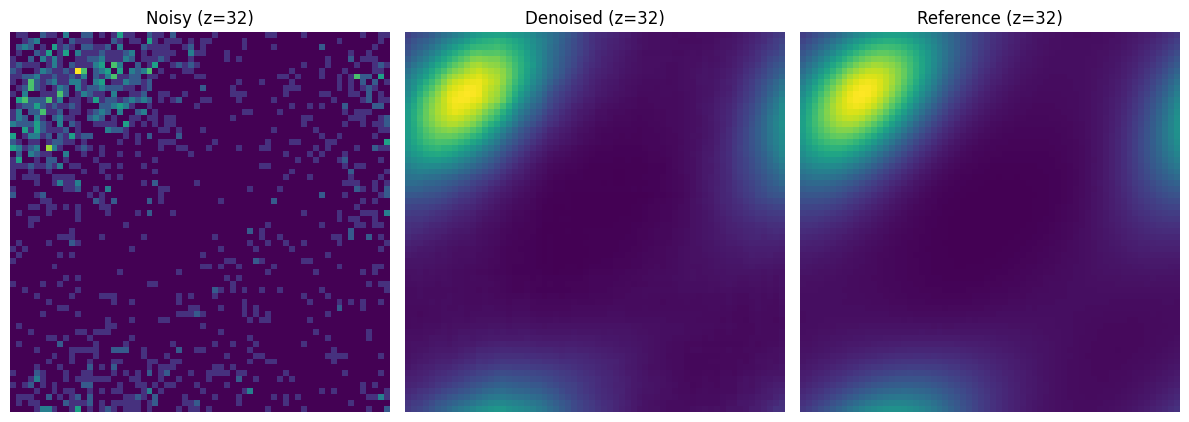

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000128
(64, 64, 64) (64, 64, 64) (64, 64, 64)


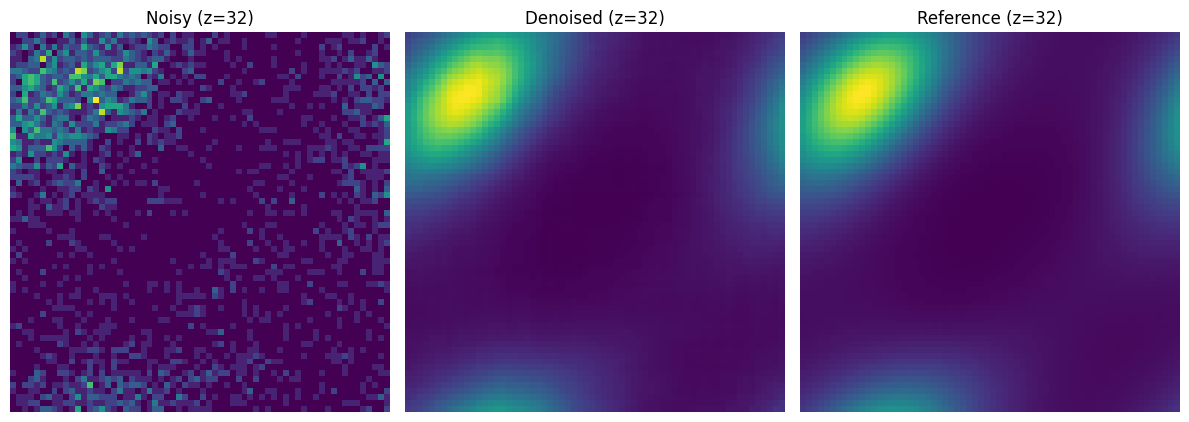

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000127
(64, 64, 64) (64, 64, 64) (64, 64, 64)


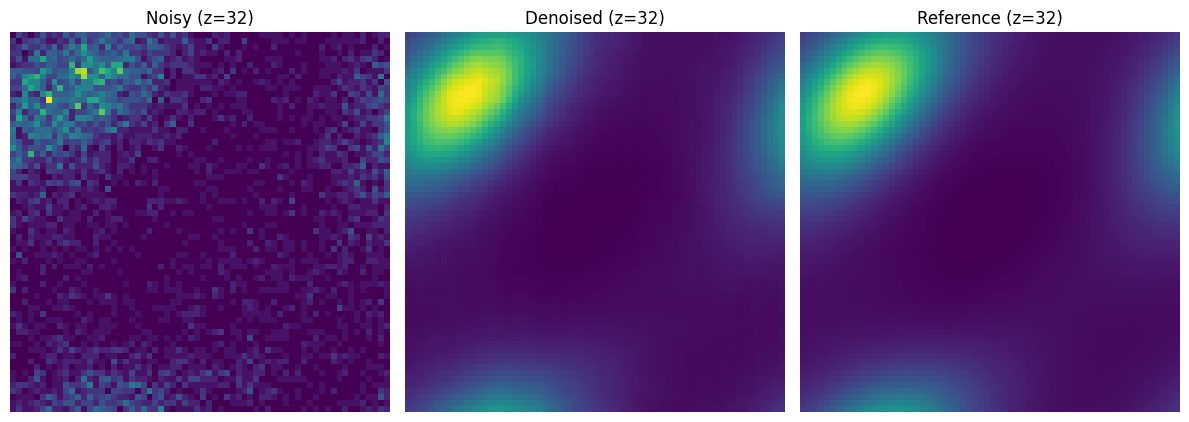

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


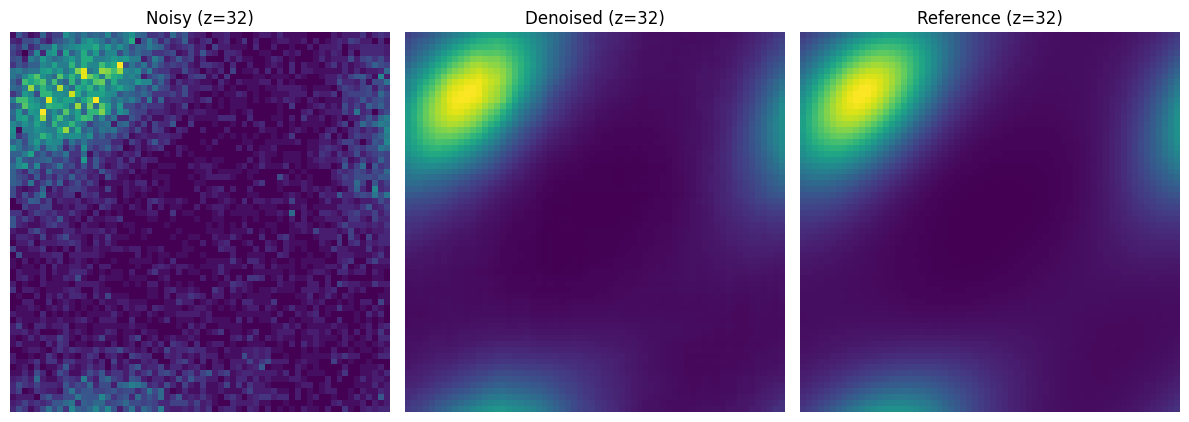

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


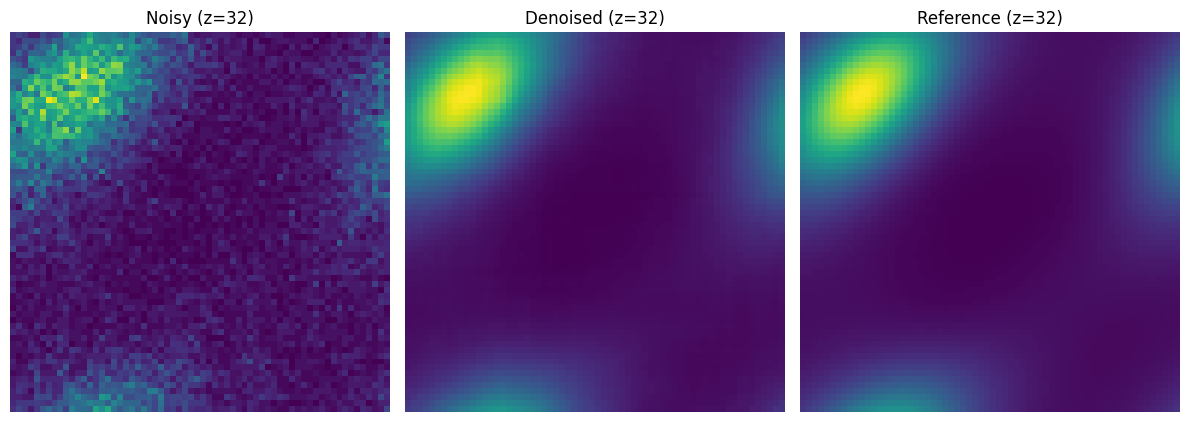

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


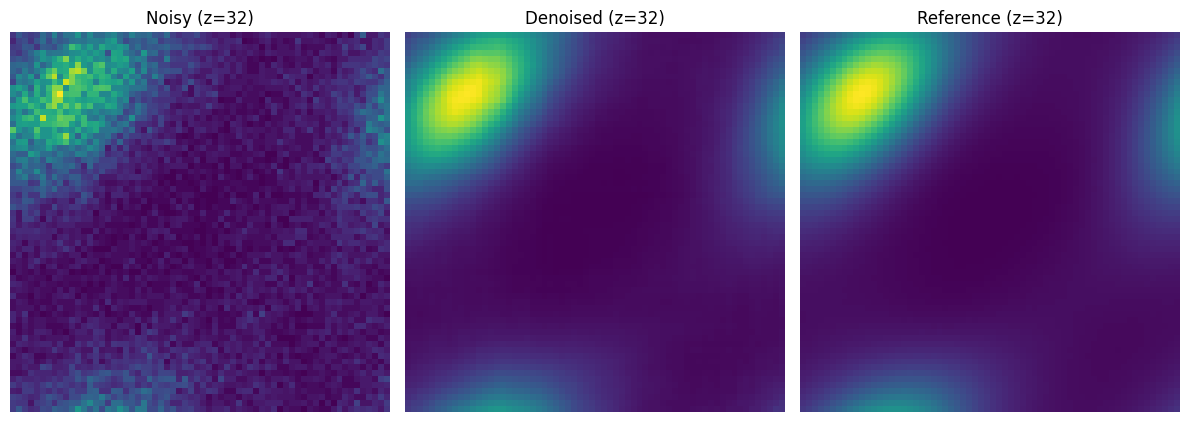

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


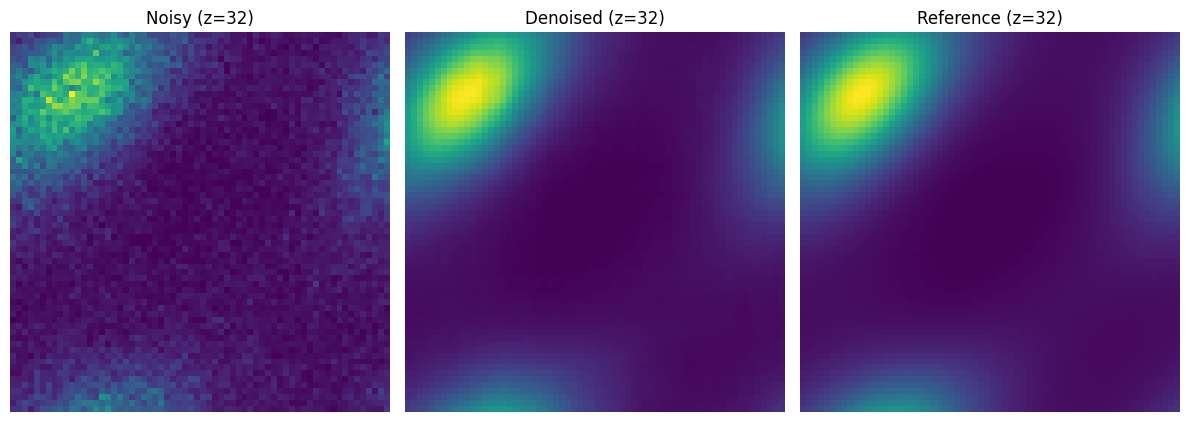

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


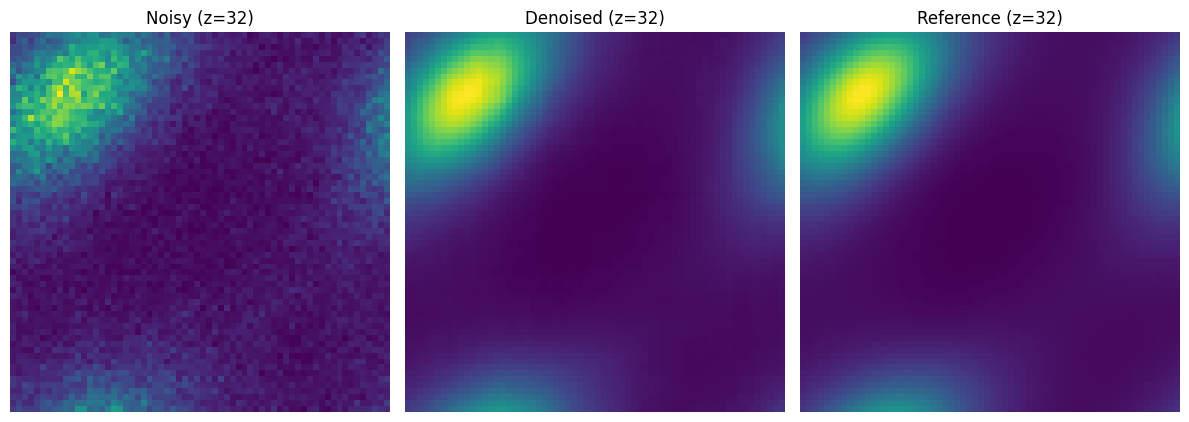

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


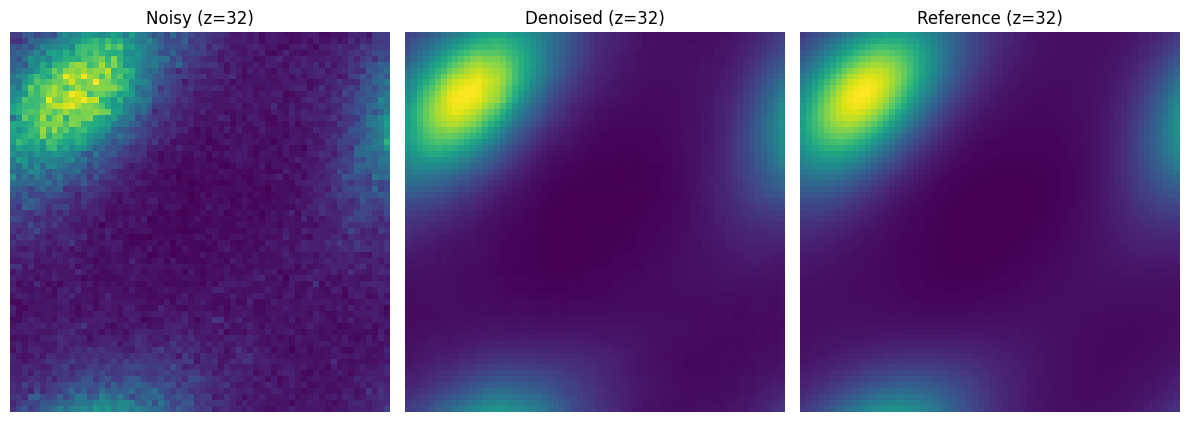

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


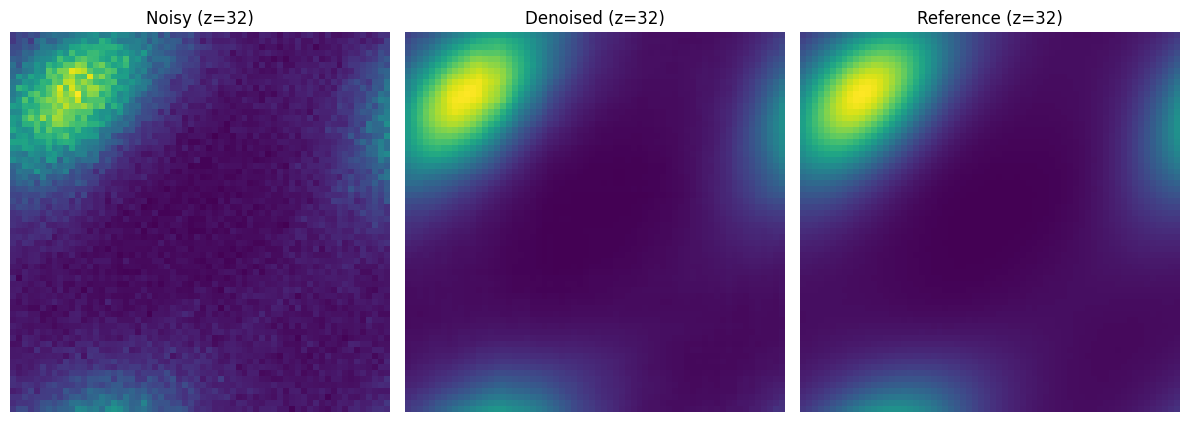

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


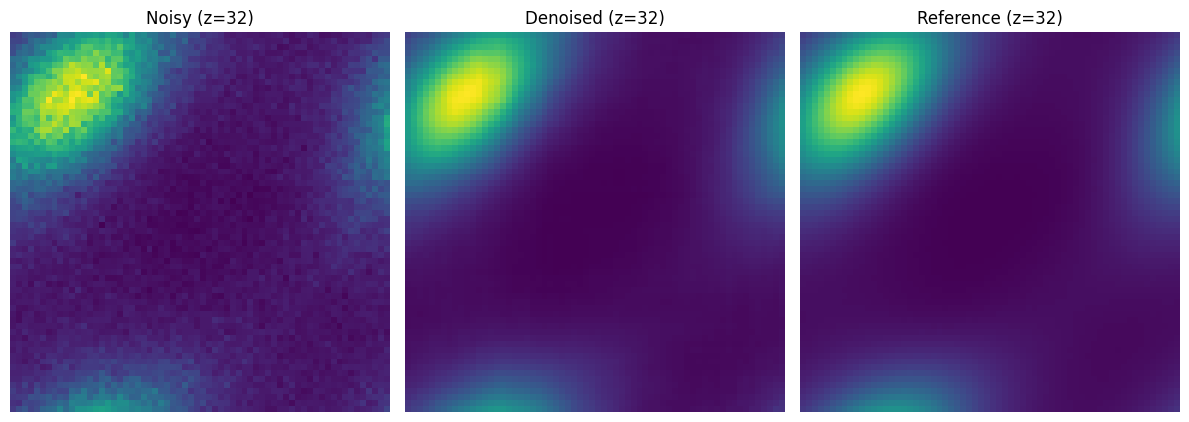

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


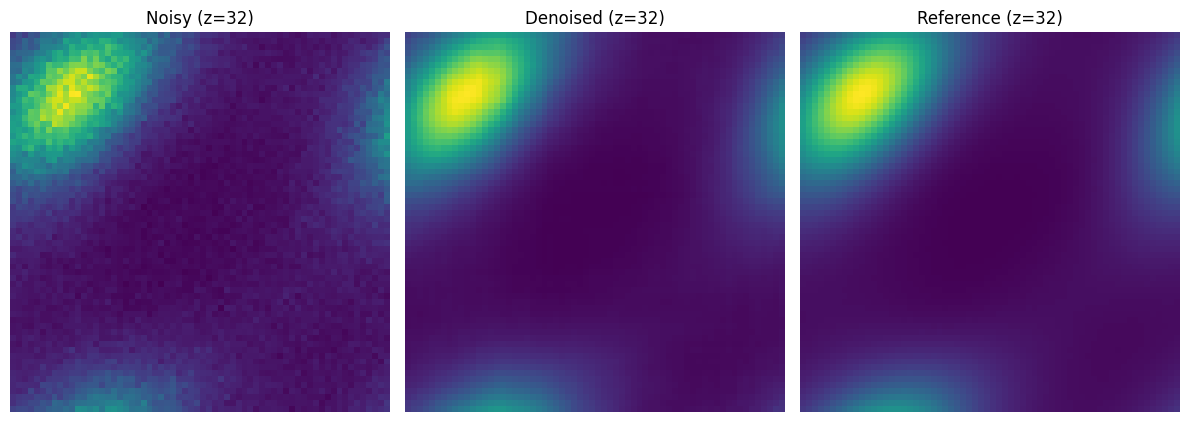

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


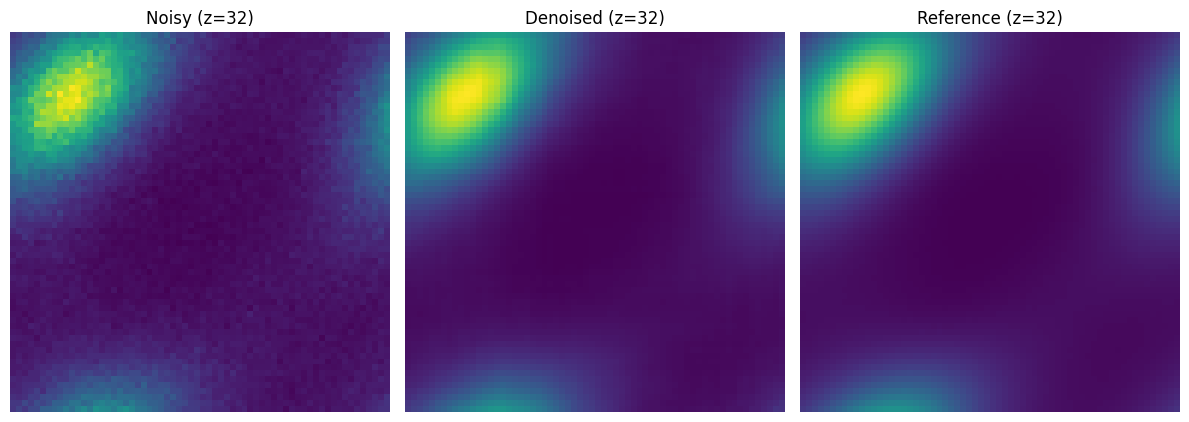

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


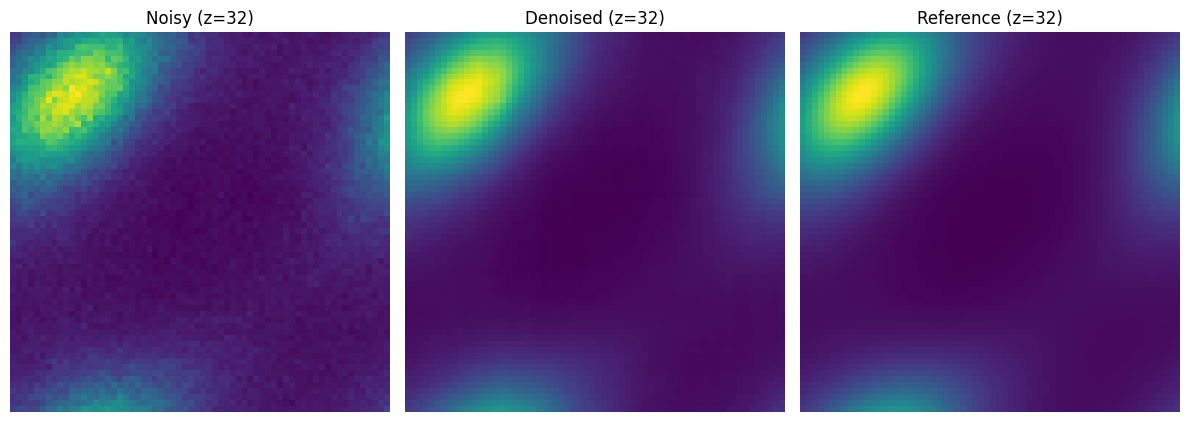

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


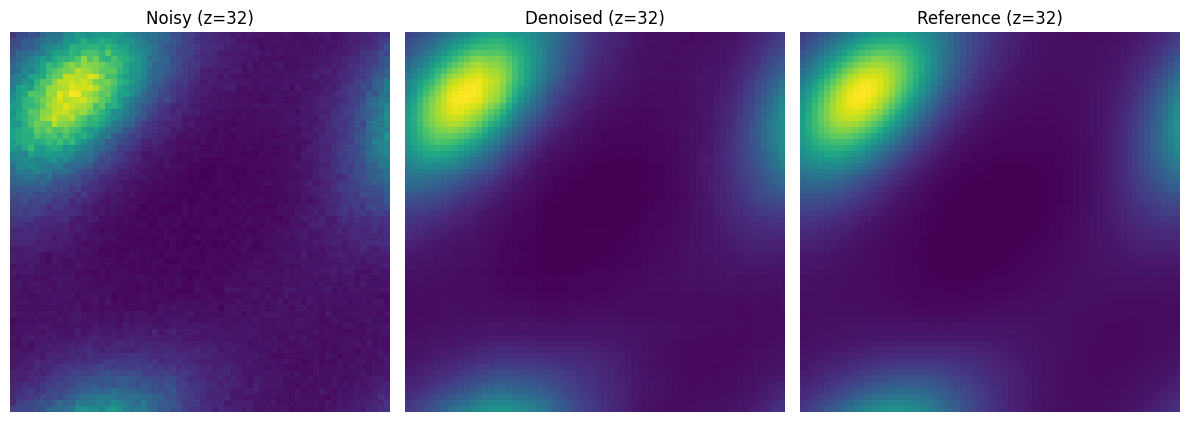

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


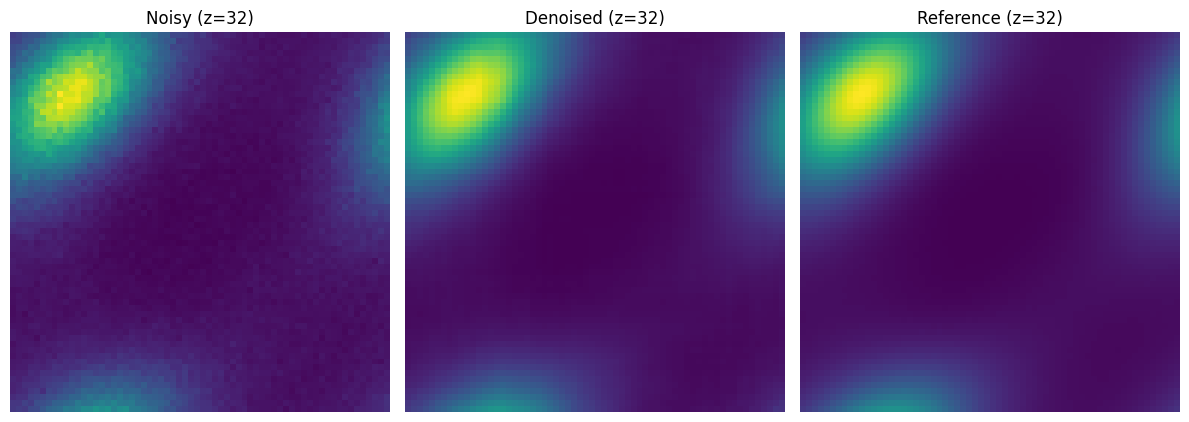

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


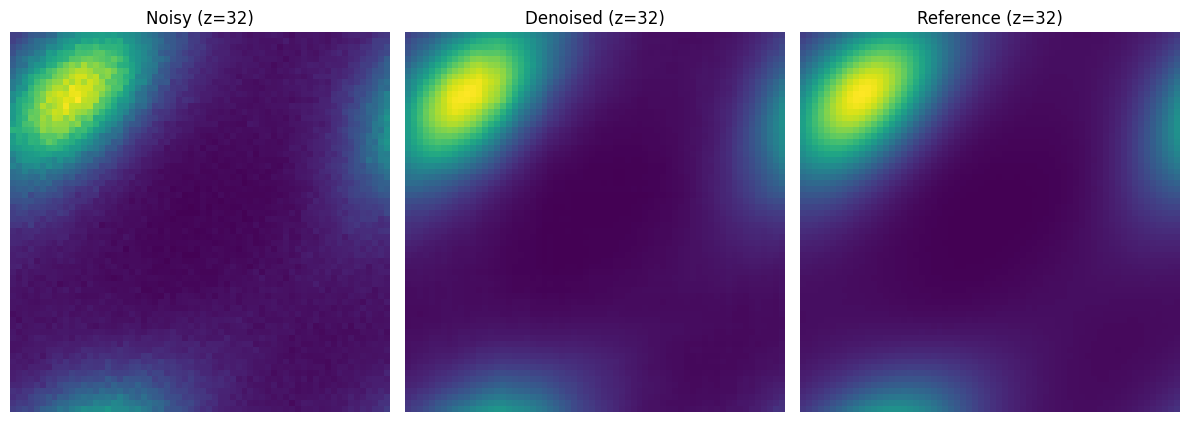

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


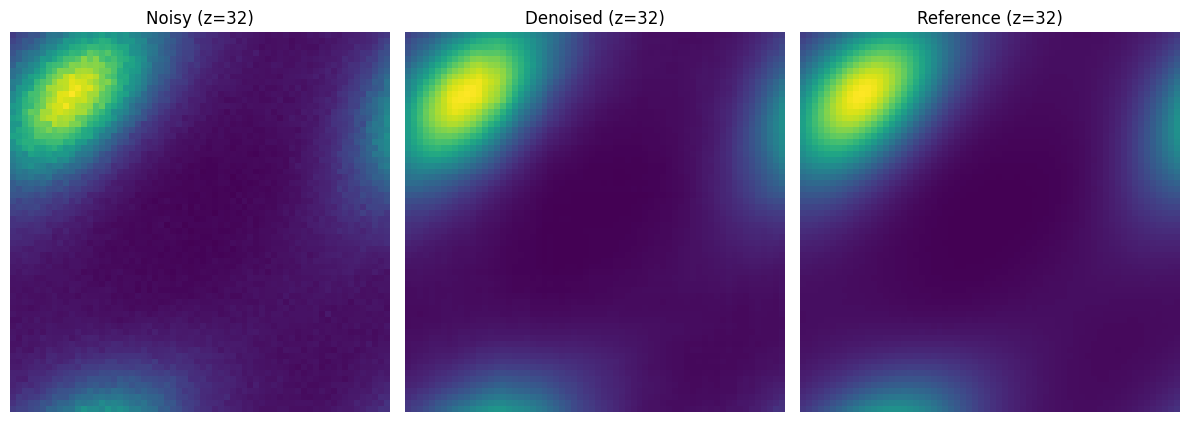

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


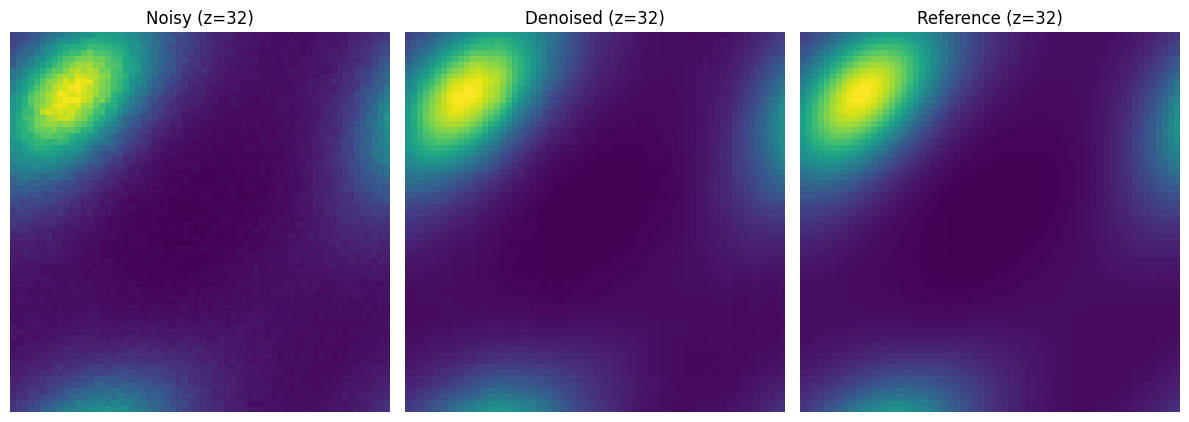

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


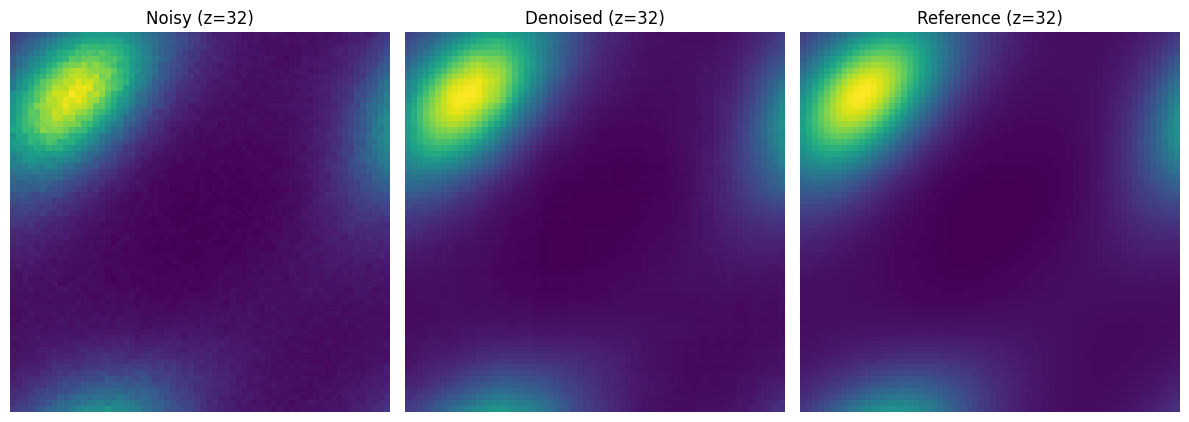

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


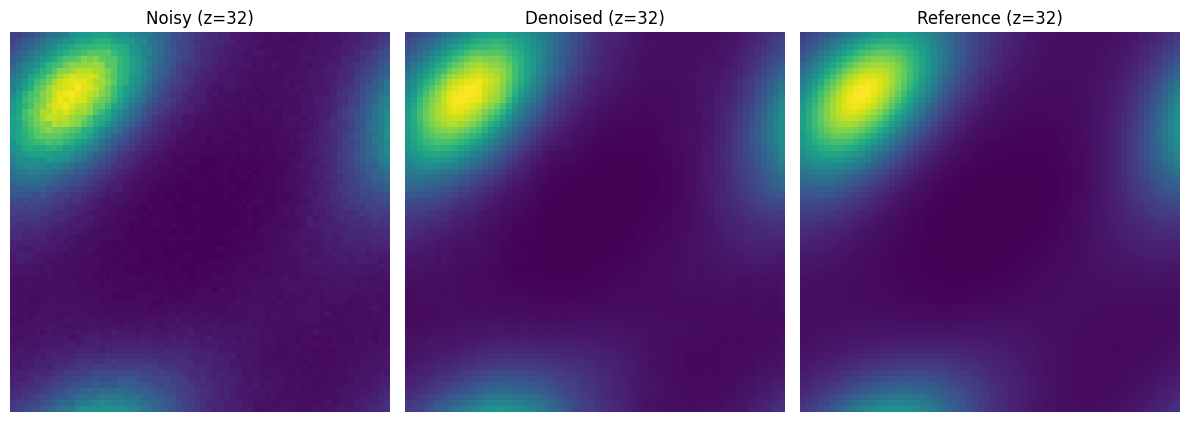

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


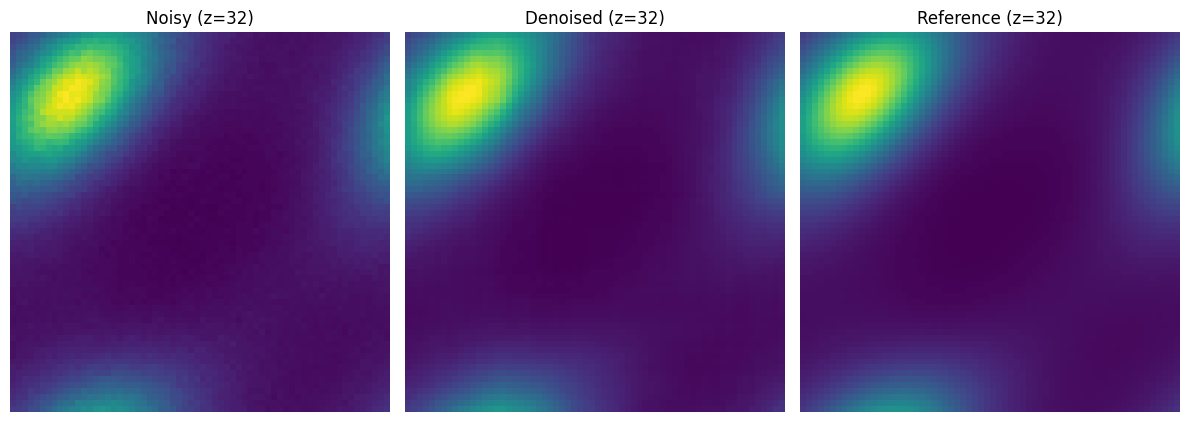

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


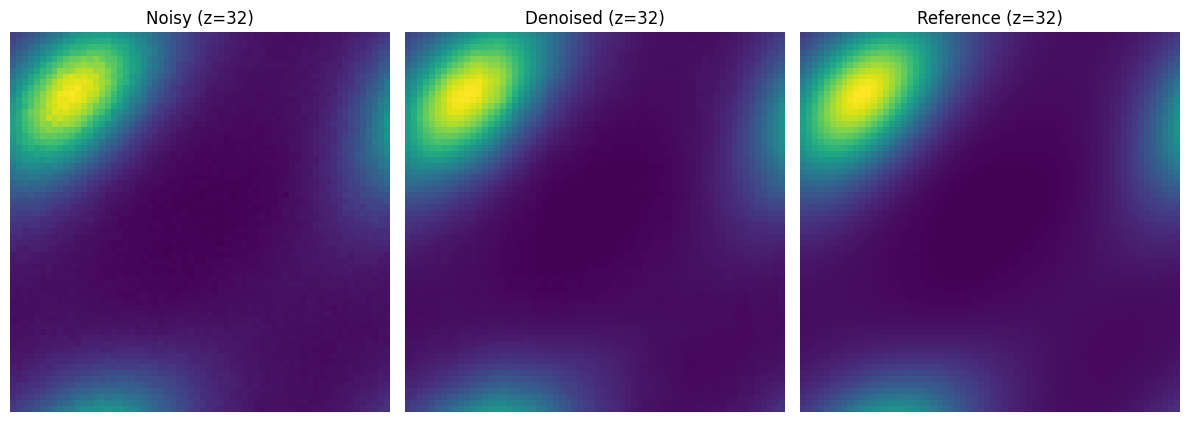

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000125
(64, 64, 64) (64, 64, 64) (64, 64, 64)


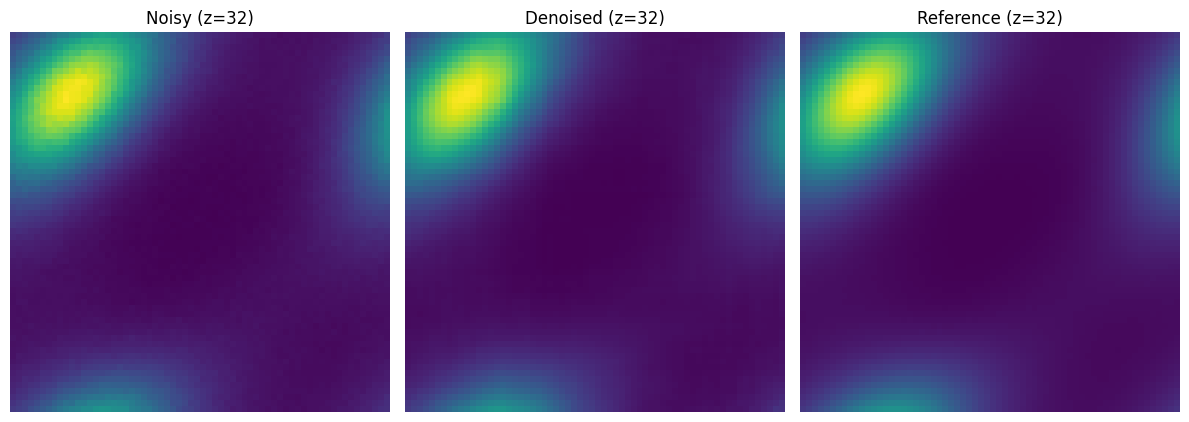

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


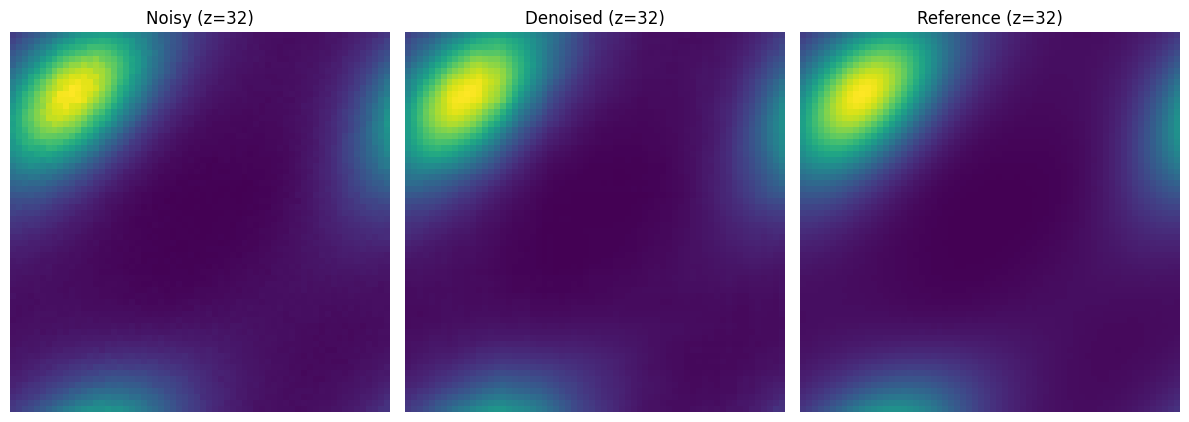

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000125
(64, 64, 64) (64, 64, 64) (64, 64, 64)


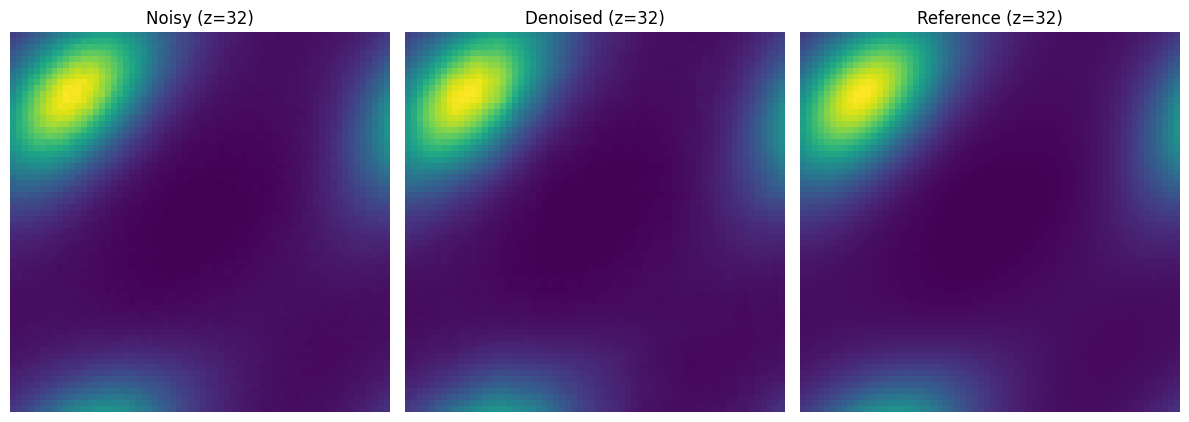

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000125
(64, 64, 64) (64, 64, 64) (64, 64, 64)


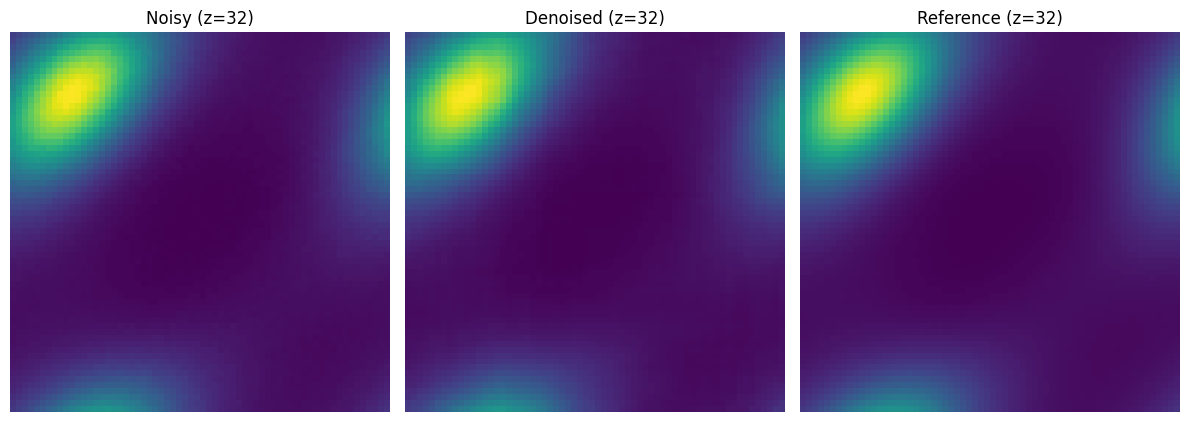

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


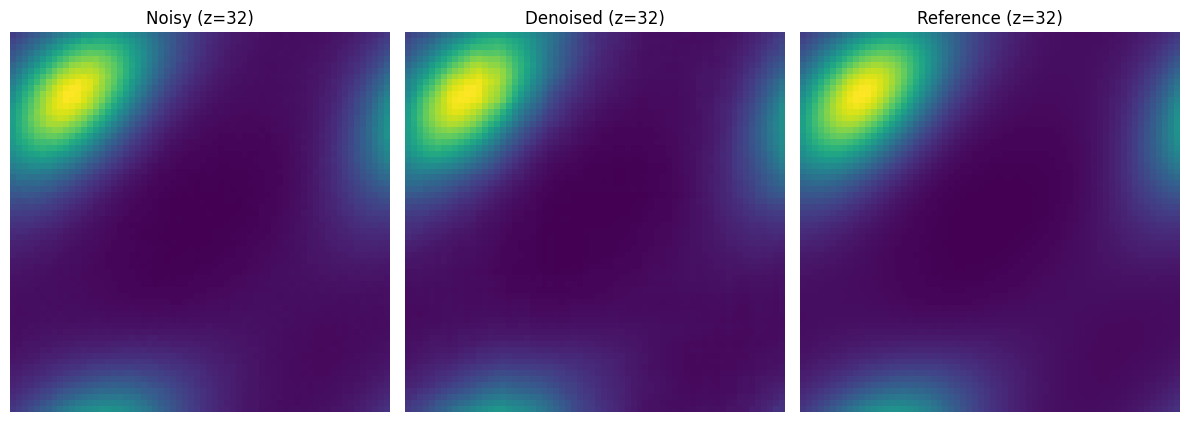

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


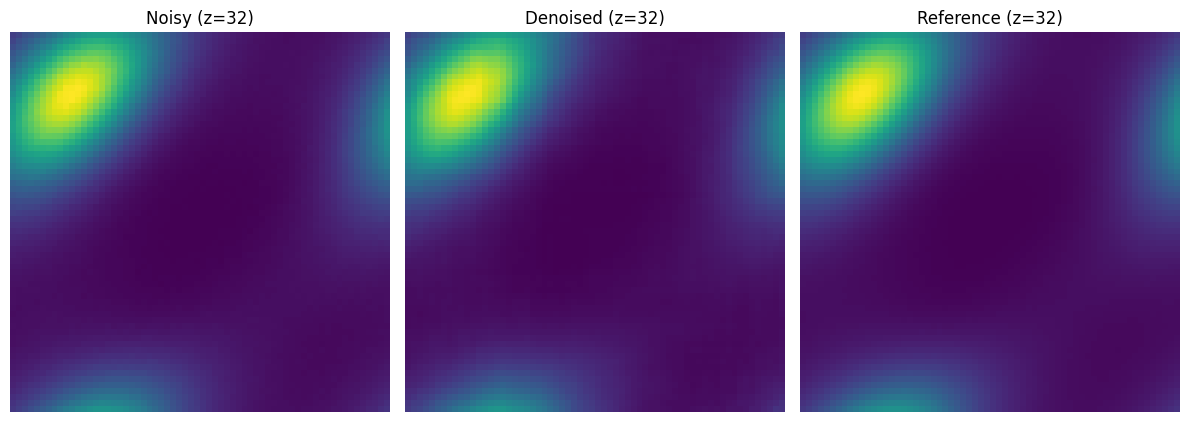

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000125
(64, 64, 64) (64, 64, 64) (64, 64, 64)


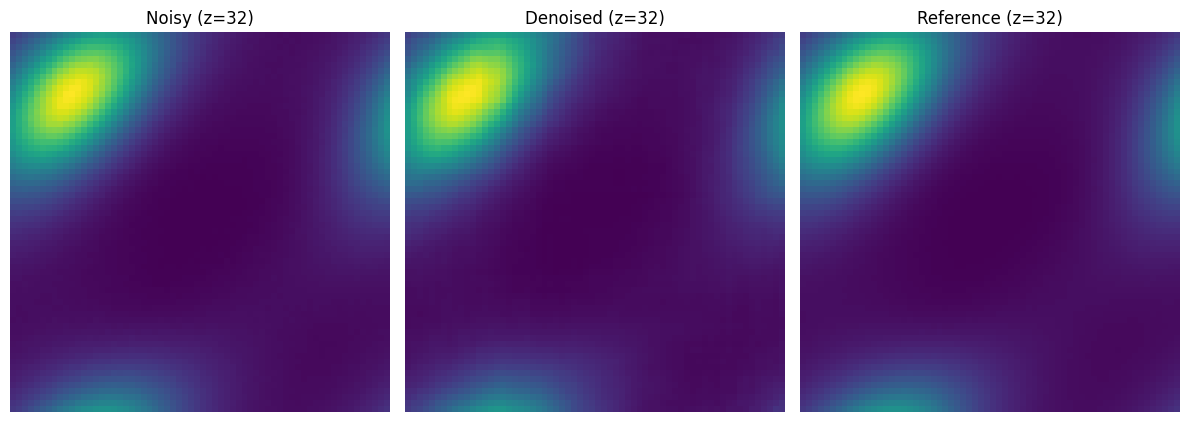

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


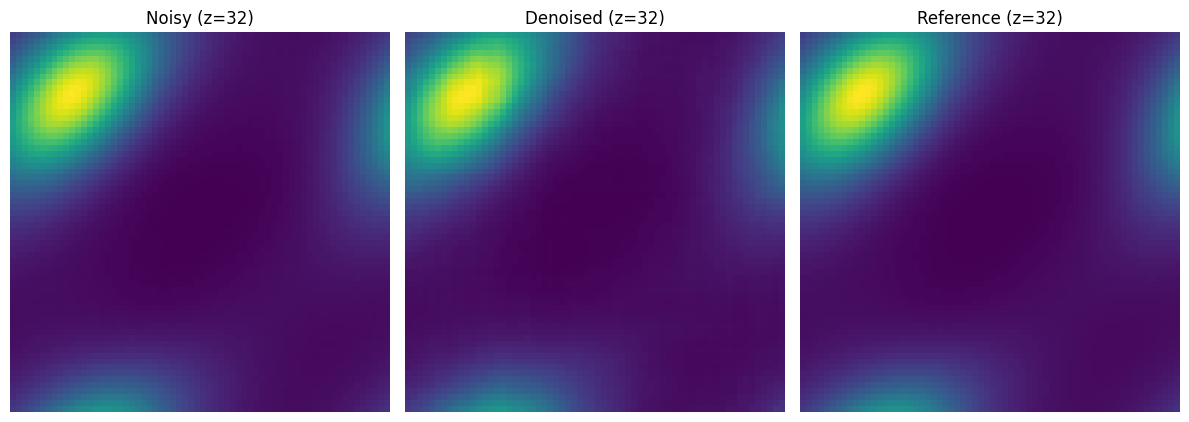

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000126
(64, 64, 64) (64, 64, 64) (64, 64, 64)


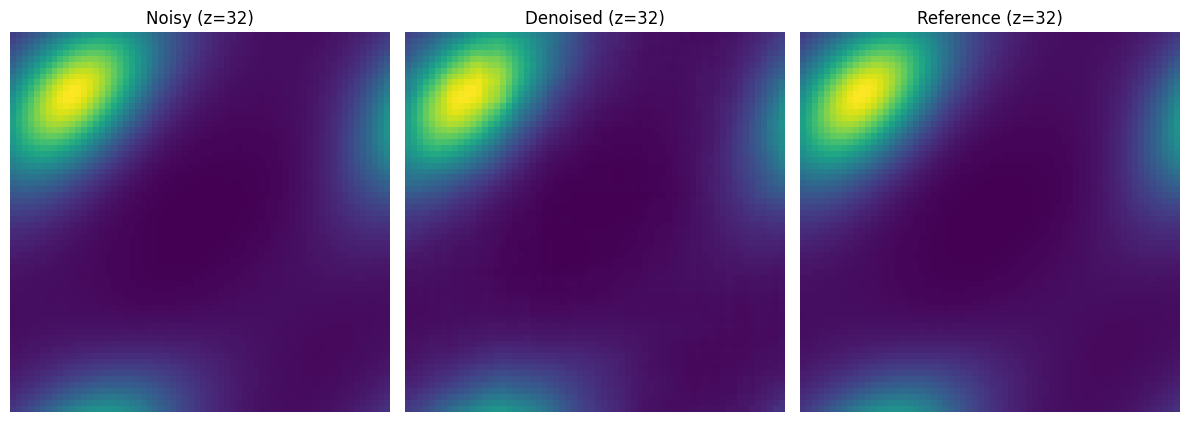

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0007
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000125
(64, 64, 64) (64, 64, 64) (64, 64, 64)


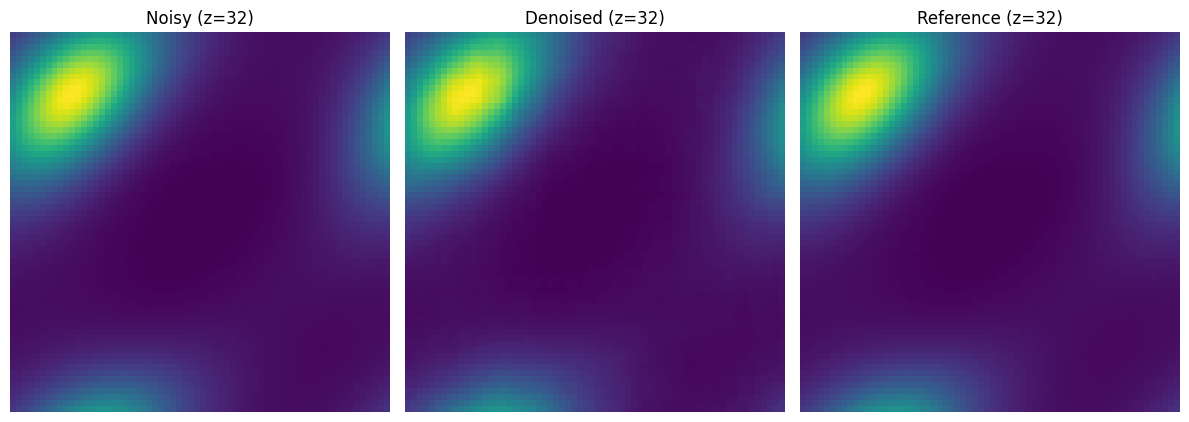


=== Running model: 24080000000CAE_3D ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0204
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.218973
JSD   (denoised vs ref):  0.000111
(64, 64, 64) (64, 64, 64) (64, 64, 64)


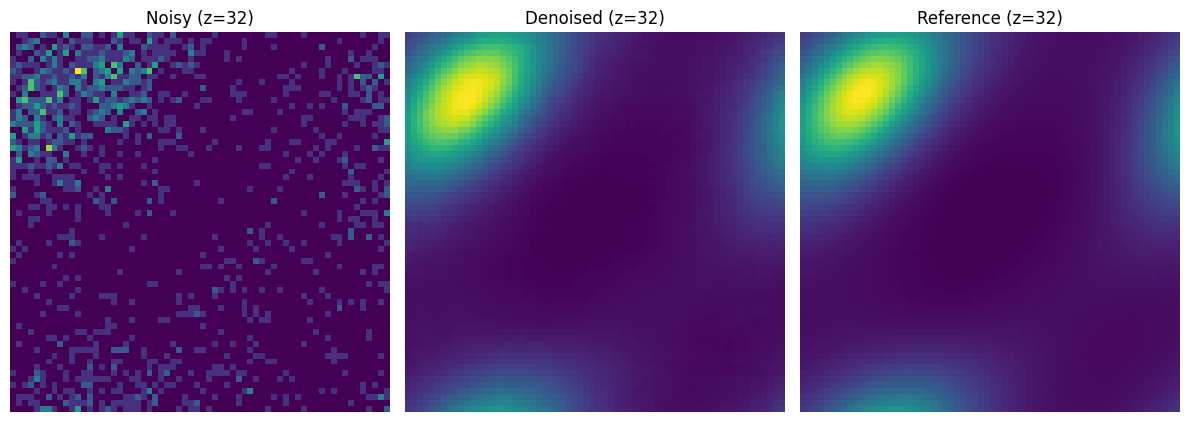

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0145
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.133921
JSD   (denoised vs ref):  0.000110
(64, 64, 64) (64, 64, 64) (64, 64, 64)


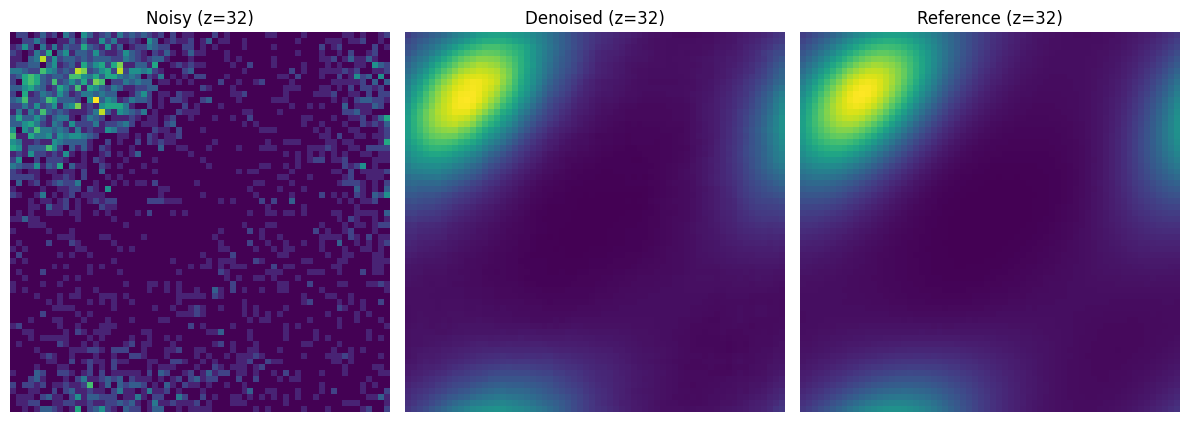

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0103
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.074959
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


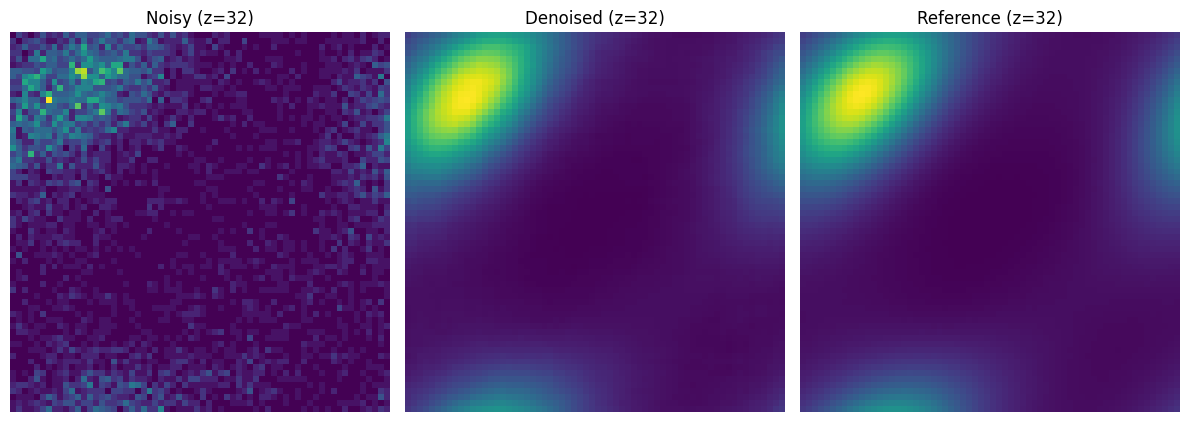

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0073
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.038659
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


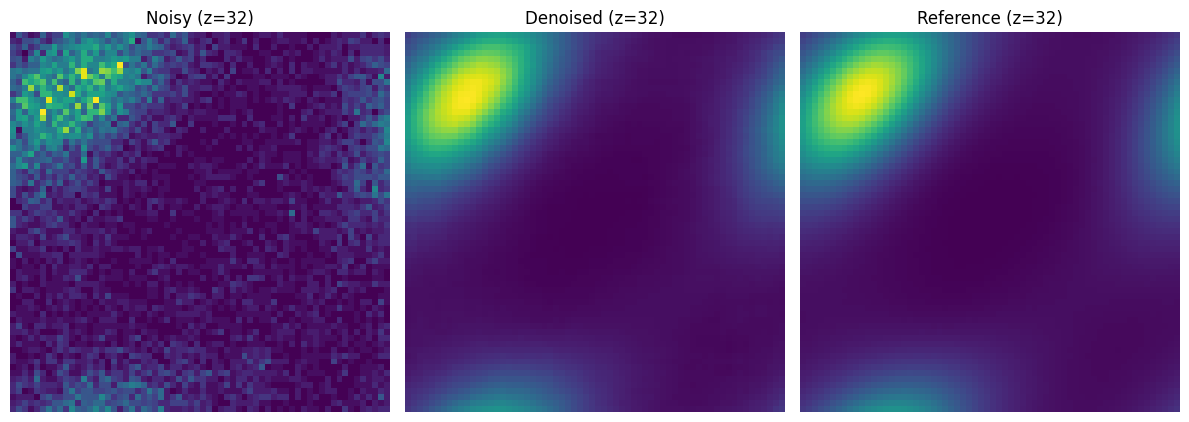

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0052
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.018616
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


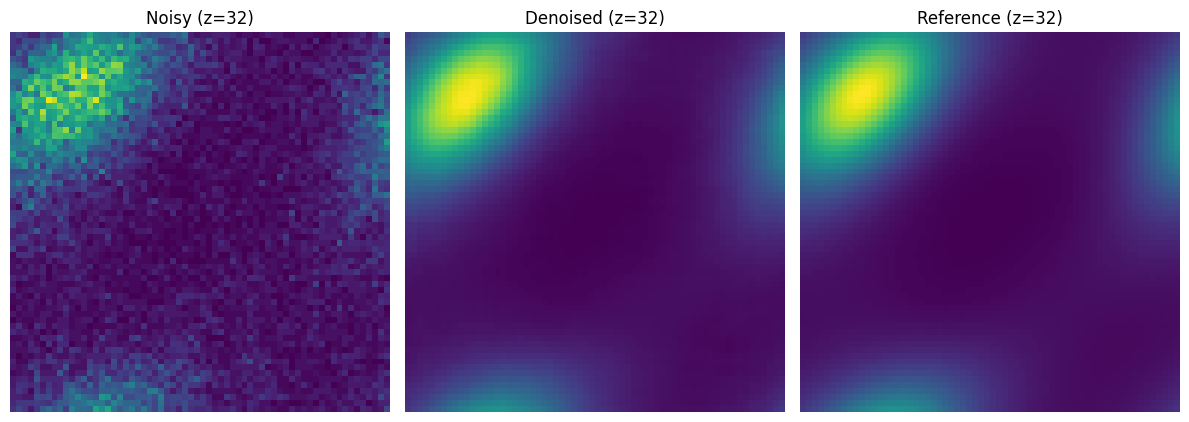

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0045
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.013673
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


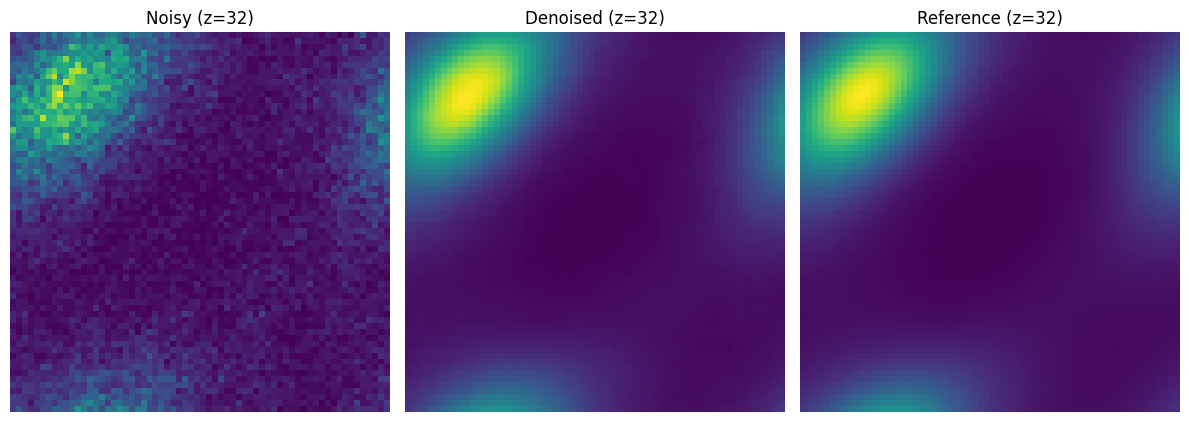

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0037
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.008732
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


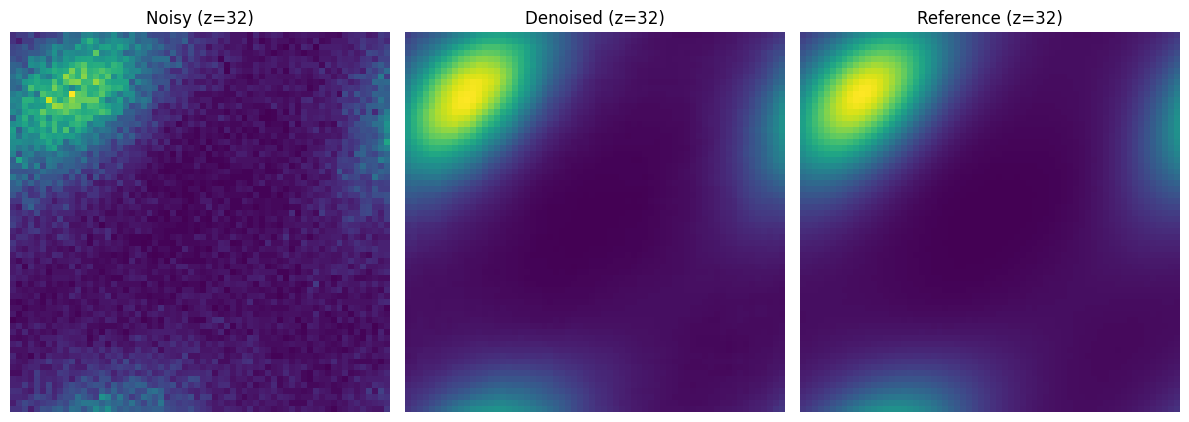

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0032
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.006486
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


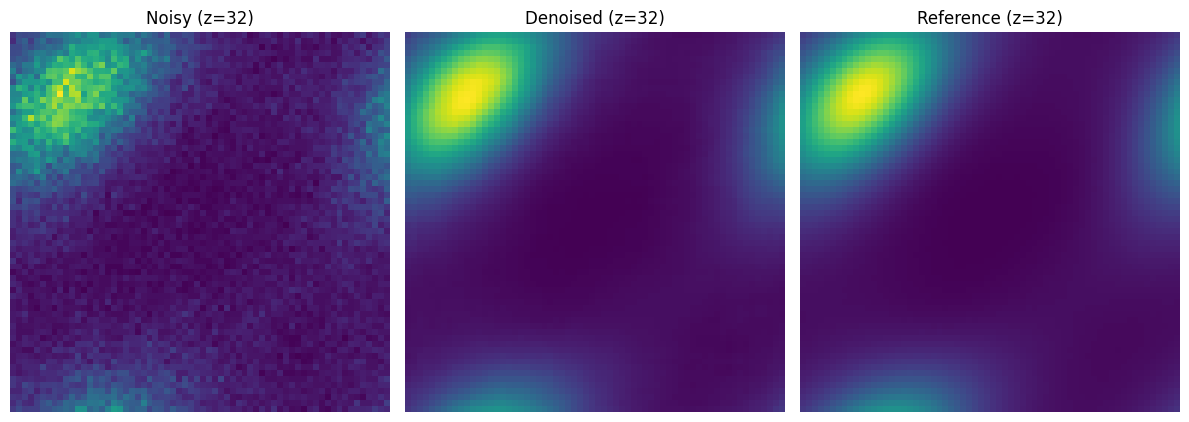

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0026
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.004202
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


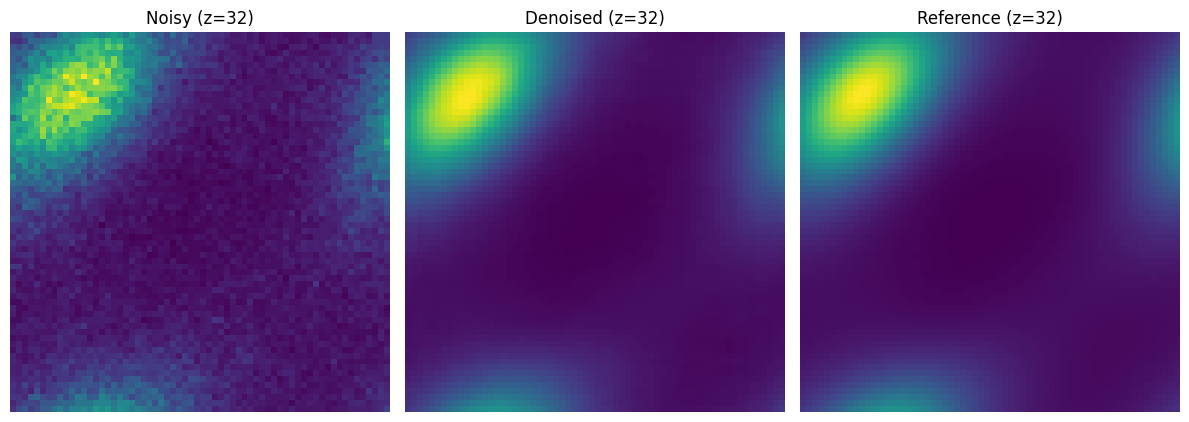

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0023
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.003164
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


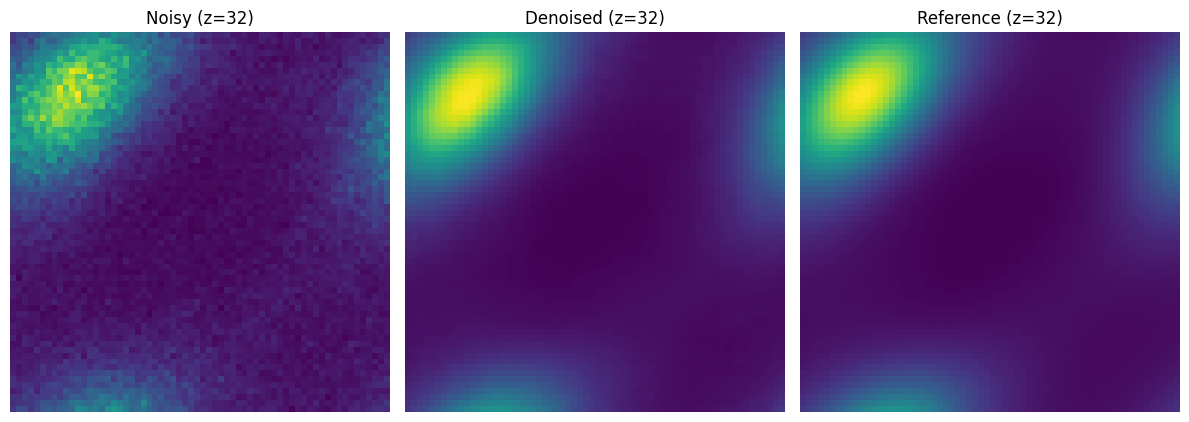

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0018
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.002070
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


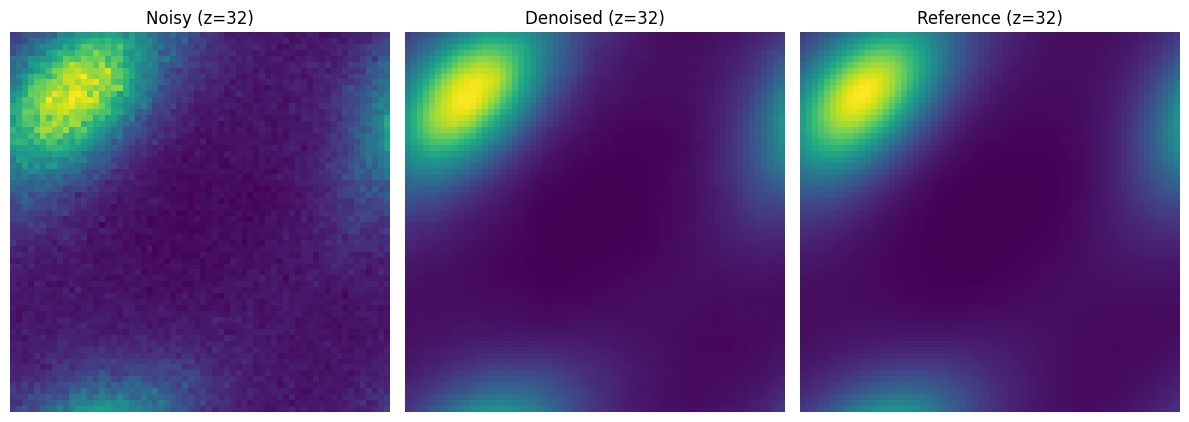

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0016
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001555
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


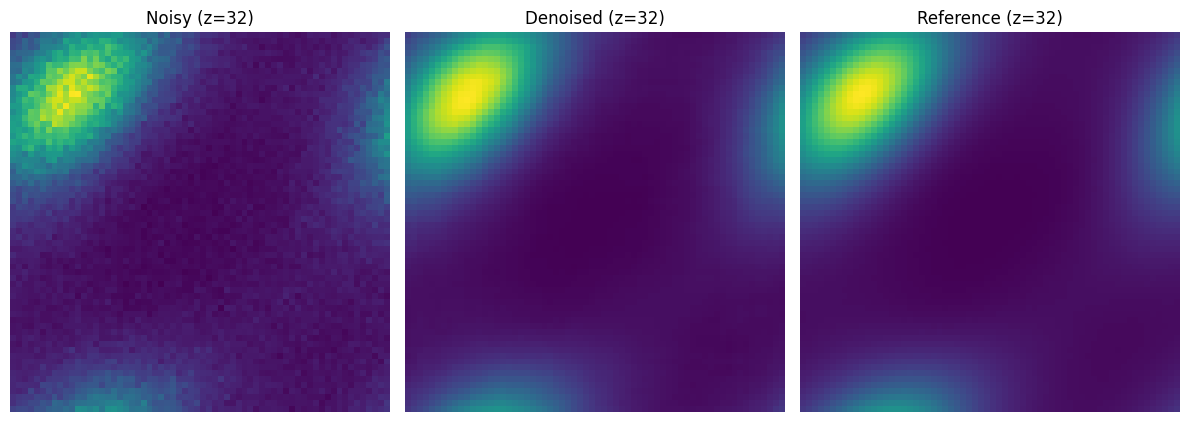

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001026
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


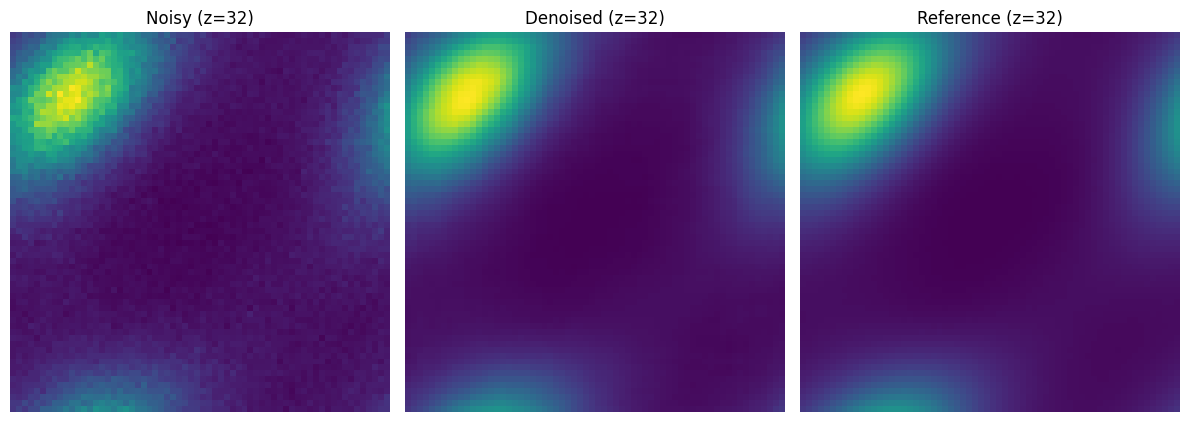

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0013
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.001030
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


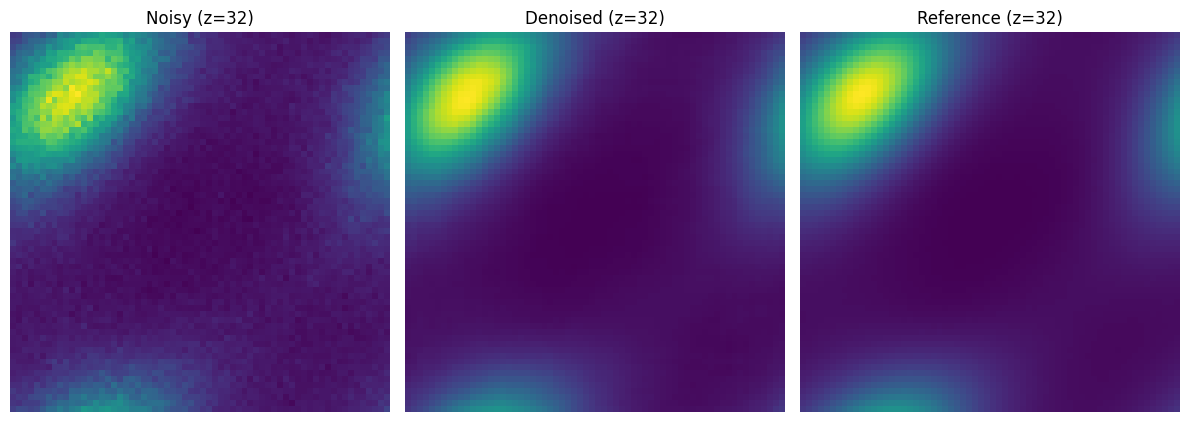

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0011
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000775
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


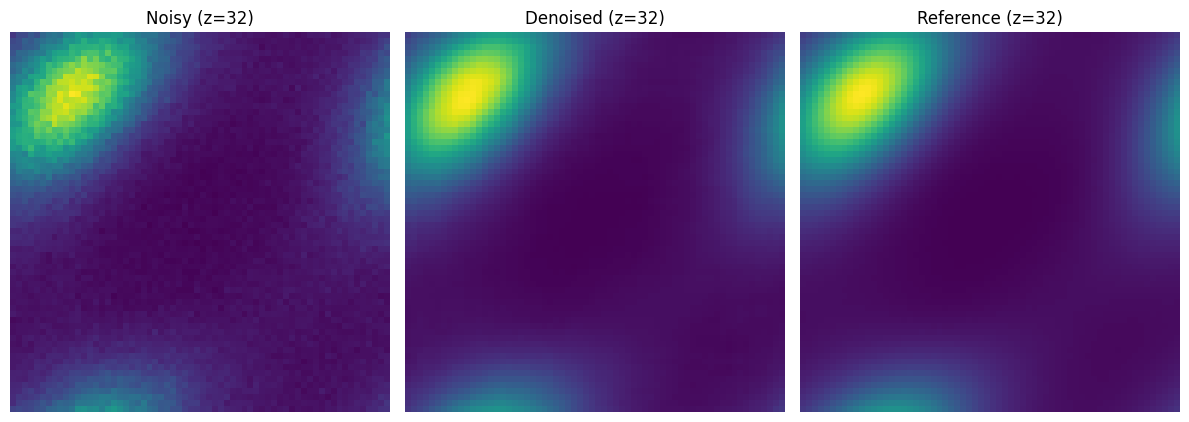

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000513
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


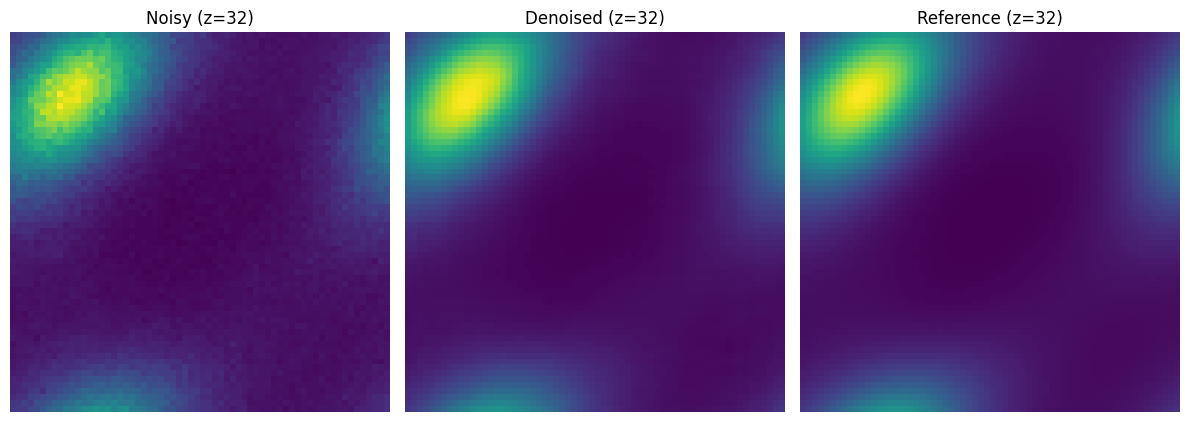

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0009
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000512
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


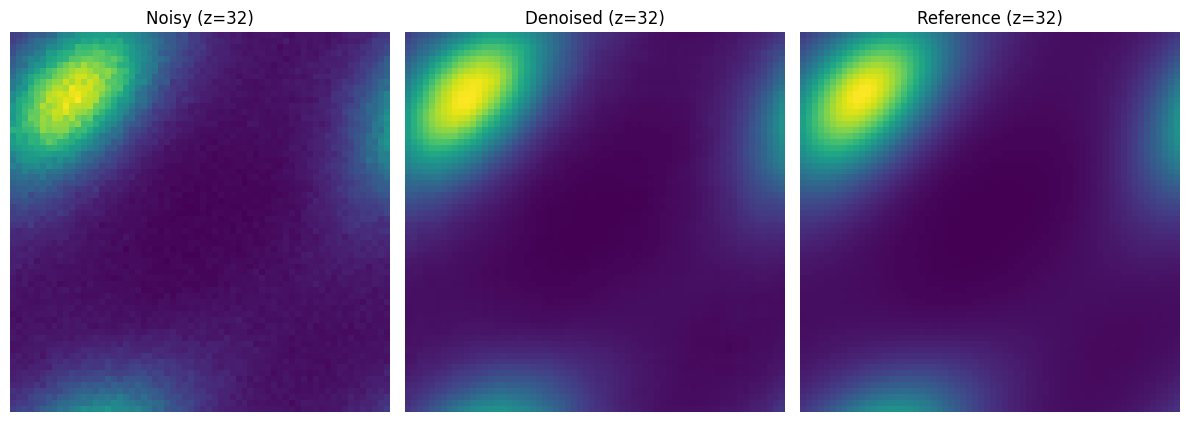

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0008
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000387
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


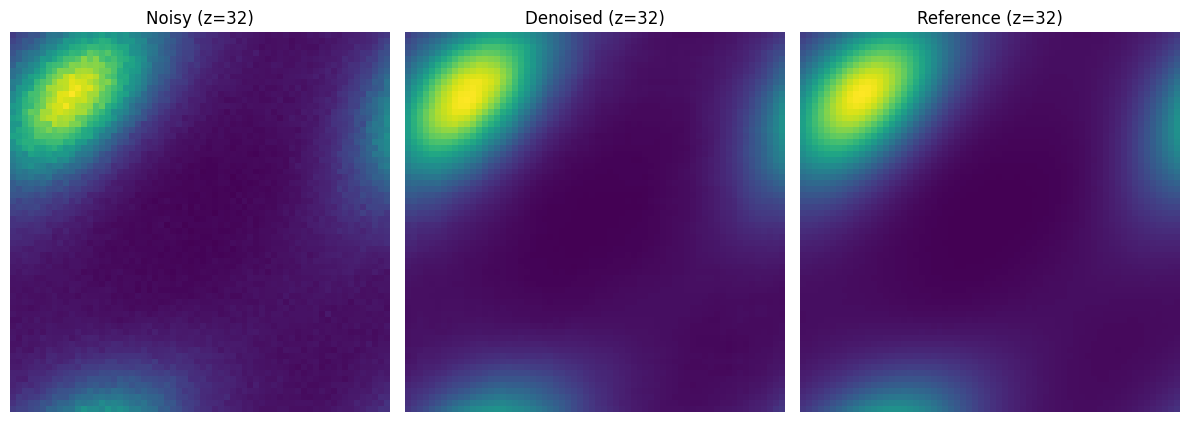

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0007
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


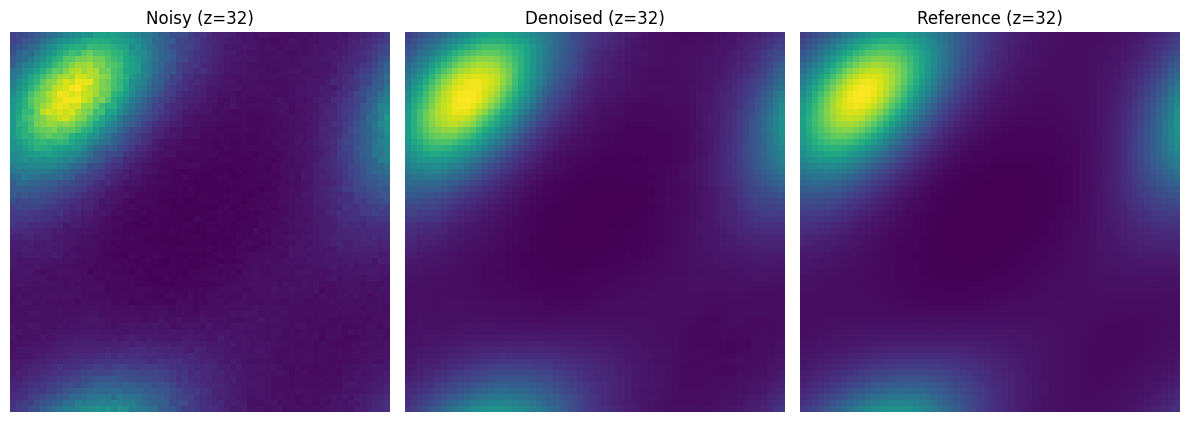

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000256
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


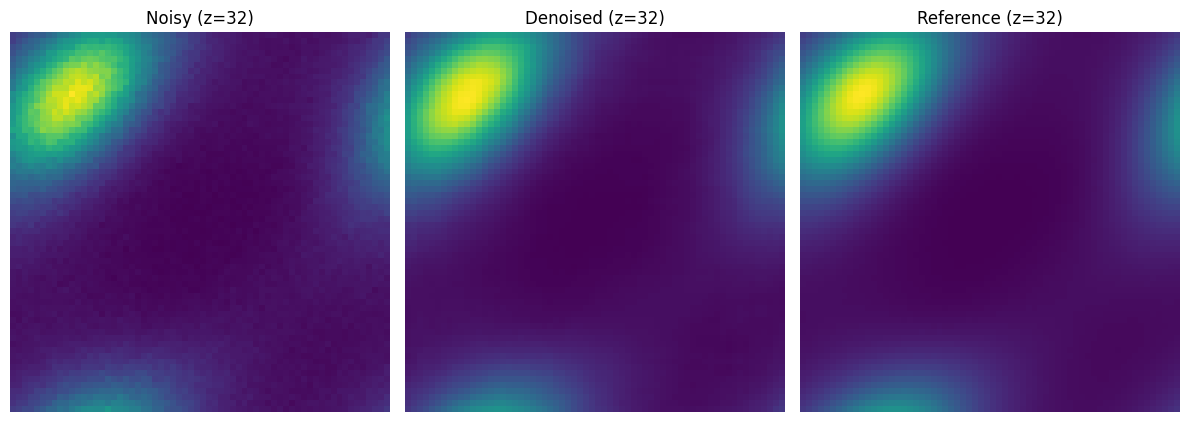

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0006
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000192
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


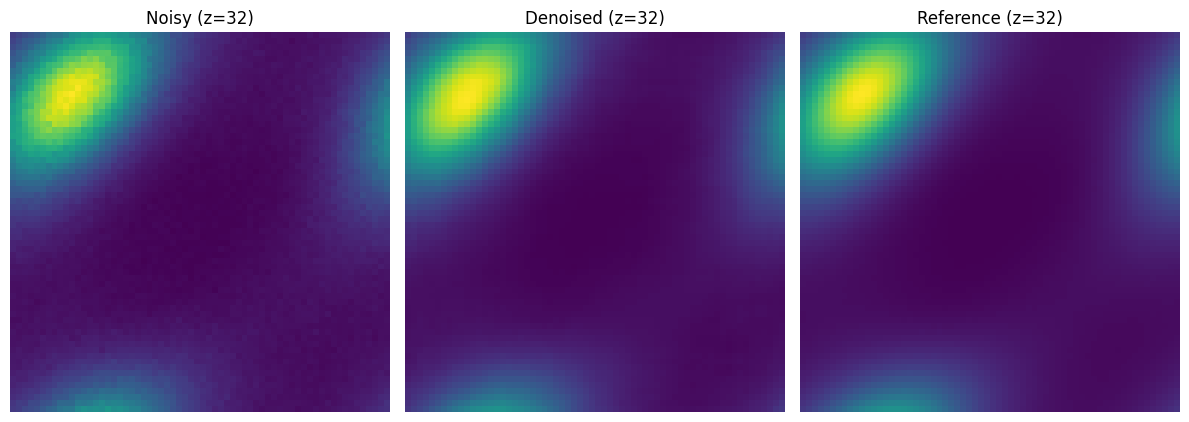

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0005
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000129
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


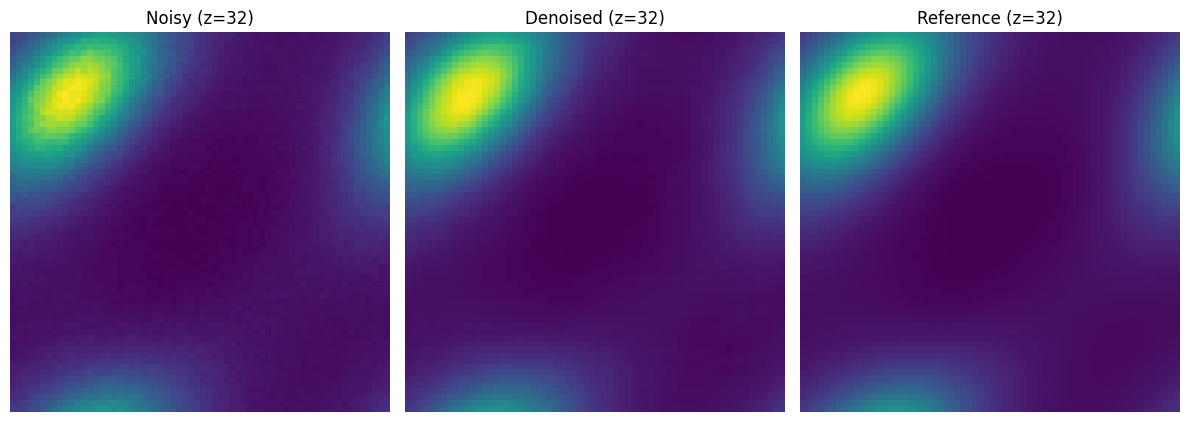

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0004
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000097
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


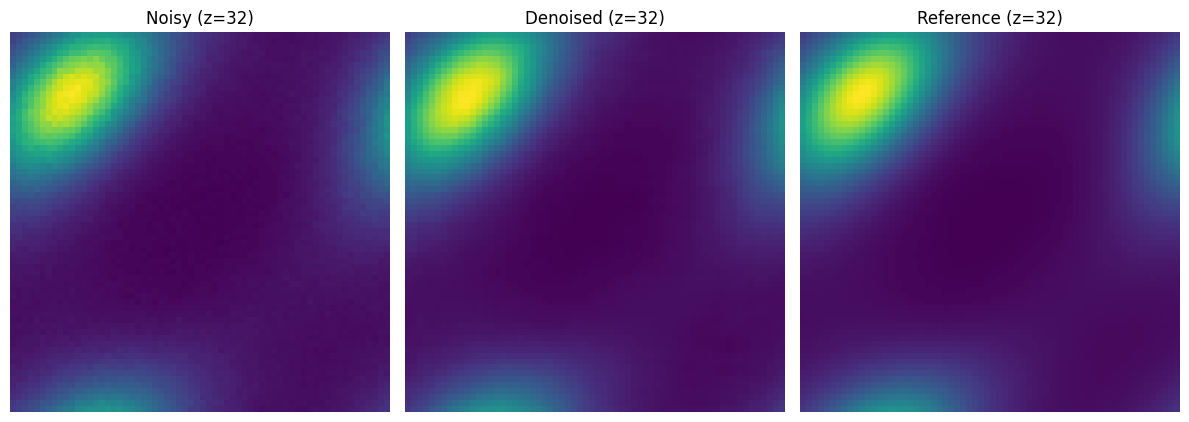

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000065
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


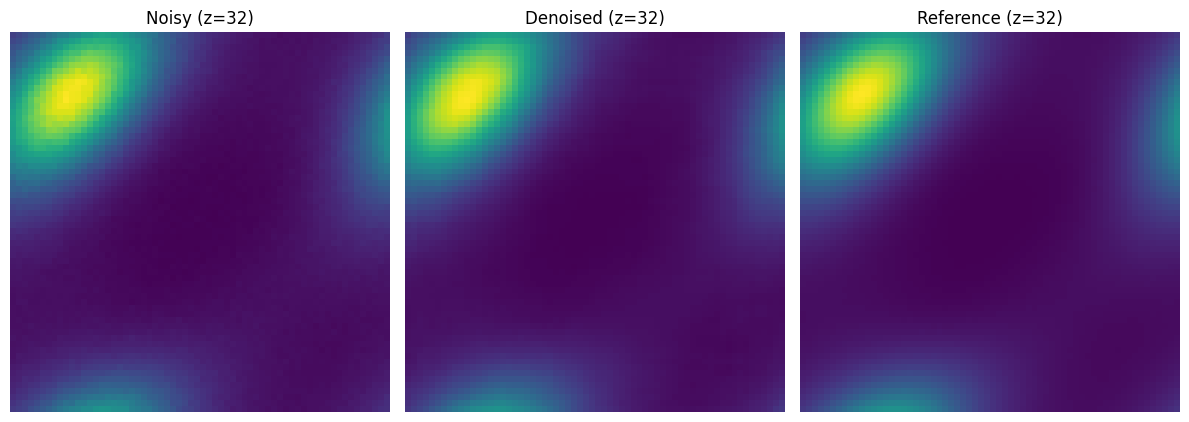

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0003
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000049
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


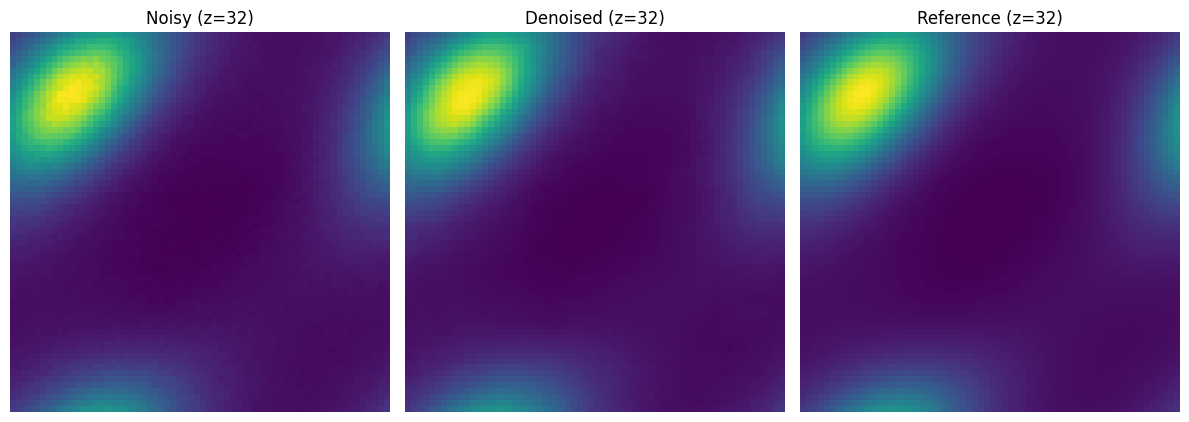

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000033
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


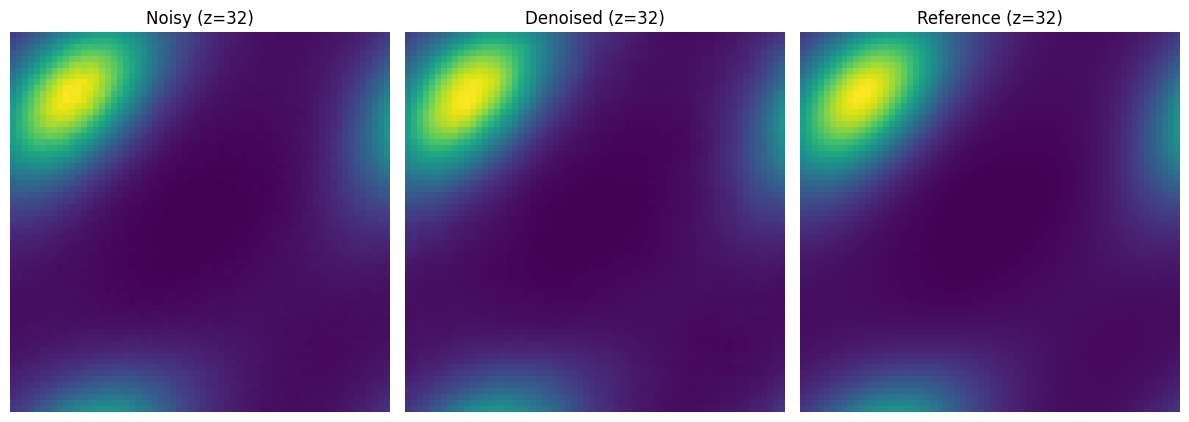

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000025
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


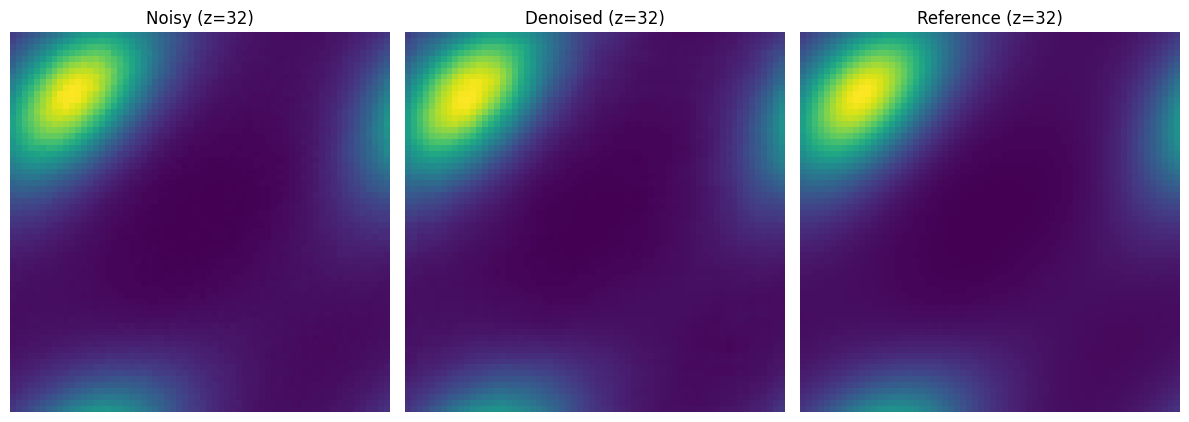

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0002
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000017
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


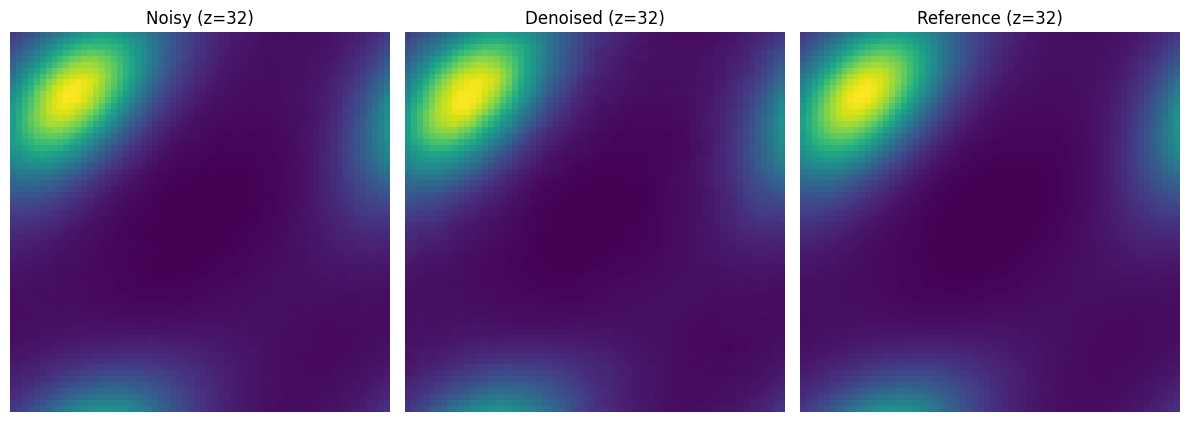

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000013
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


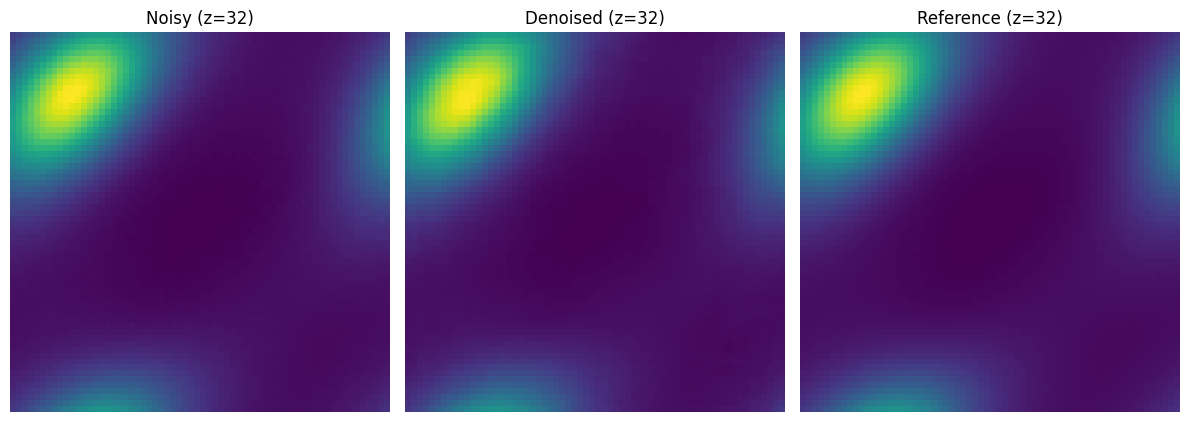

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000009
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


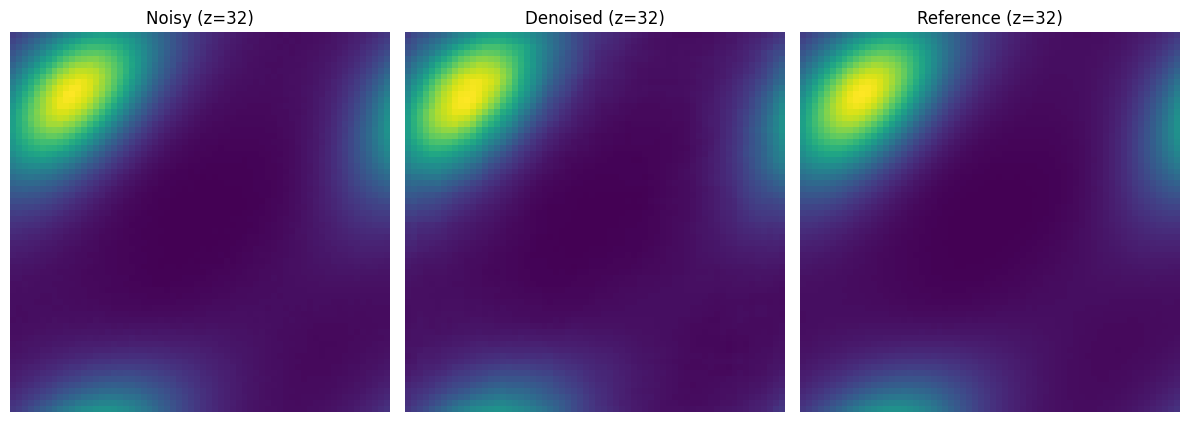

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000005
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


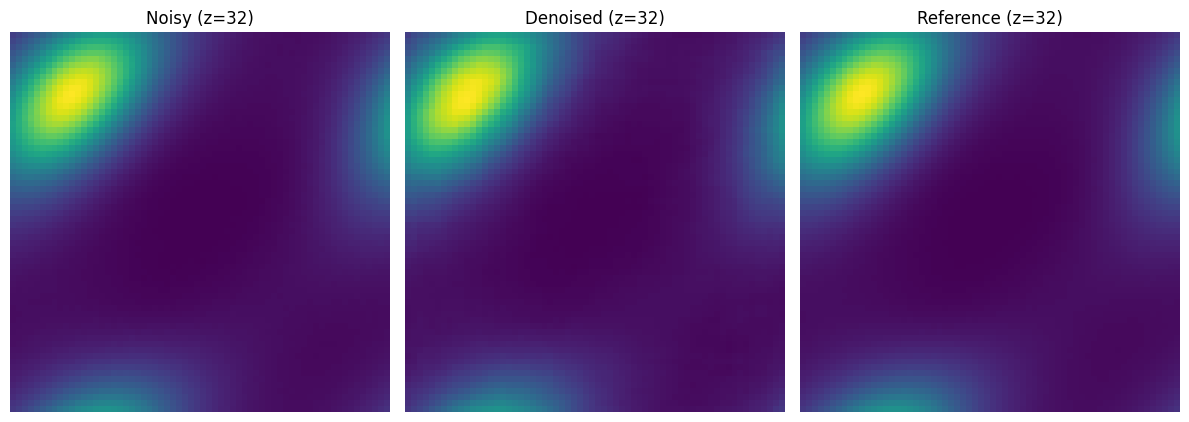

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000003
JSD   (denoised vs ref):  0.000108
(64, 64, 64) (64, 64, 64) (64, 64, 64)


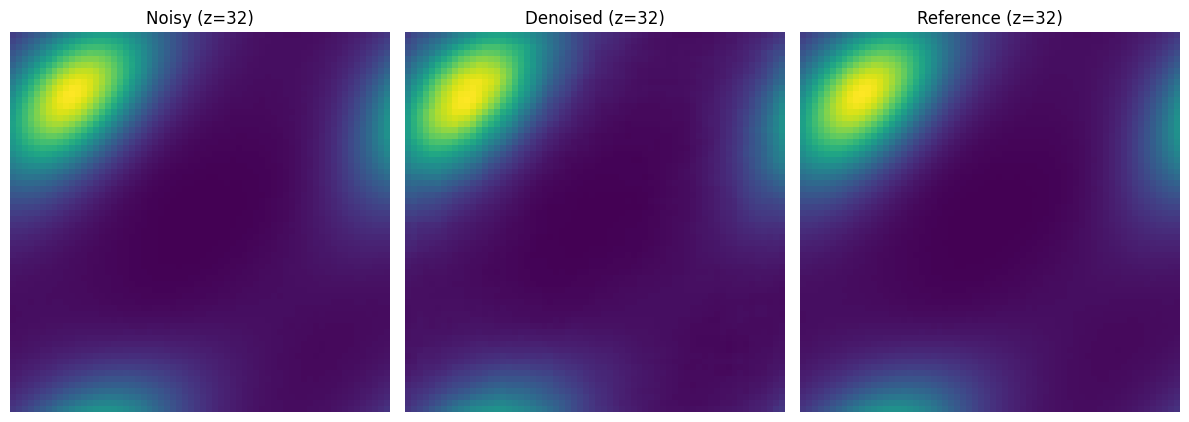

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step

>>> Evaluation Metrics
2-norm (noisy vs ref):     0.0001
2-norm (denoised vs ref): 0.0006
JSD   (noisy vs ref):     0.000002
JSD   (denoised vs ref):  0.000109
(64, 64, 64) (64, 64, 64) (64, 64, 64)


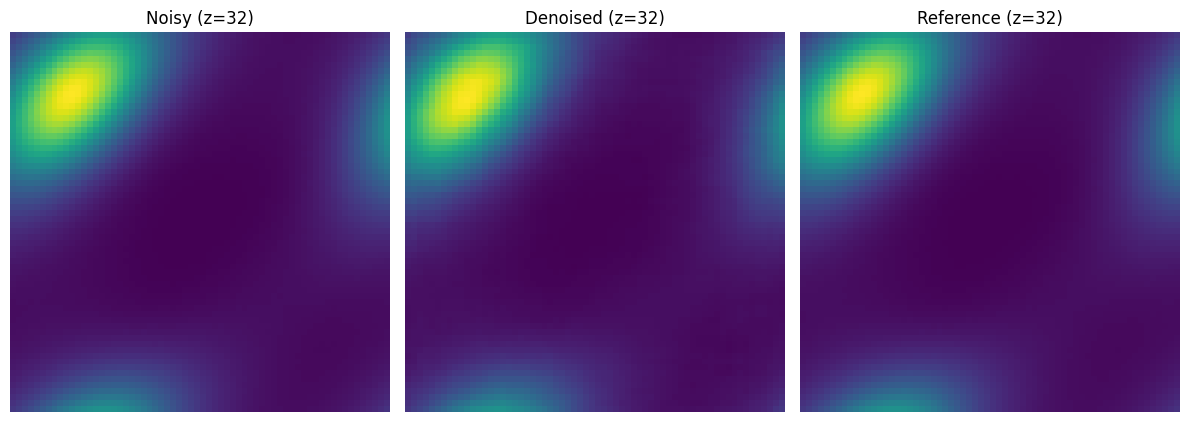

In [18]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py
import csv

# Enable unsafe deserialization for custom keras objects
keras = tf.keras
keras.config.enable_unsafe_deserialization()

# Import your custom layers/losses and the CAE_3D_test_pipeline

# Global model variable used by CAE_3D_test_pipeline
CAE_3D_mod = None

# ==== Paths ====
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")
noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_dmc_mix_mean*.h5")))

# Directory containing *_CAE_3D.keras models
model_dir = "/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/CAE_3D_Models"
model_files = sorted(glob.glob(os.path.join(model_dir, "*CAE_3D.keras")))

print(f"Found {len(noisy_files)} noisy files.")
print(f"Found {len(model_files)} CAE_3D models.")

# ==== Reference JSD ====
results_ref = []
with h5py.File(ref_path, 'r') as file:
    ref_d_full = file['density'][:]

for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d_full, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))

# ==== Process each CAE_3D model ====
all_results = {}

for model_path in model_files:
    model_name = os.path.basename(model_path).replace(".keras", "")
    print(f"\n=== Running model: {model_name} ===")

    # Load model and assign to global used in CAE_3D_test_pipeline
    CAE_3D_mod = keras.models.load_model(
        model_path,
        custom_objects={
            "RenormalizeToEight": RenormalizeToEight,
            "jensen_shannon_divergence_loss": jensen_shannon_divergence_loss
        }
    )

    model_results = []
    for noisy_path in noisy_files:
        match = re.search(r"(\d+)\.h5$", noisy_path)
        if not match:
            continue
        sample_num = int(match.group(1))

        with h5py.File(noisy_path, 'r') as file:
            test_d = file['density'][:]

        # Call your existing function
        _, jsd_denoised = CAE_3D_test_pipeline(test_d, ref_d_full)
        model_results.append((sample_num, jsd_denoised))

    all_results[model_name] = np.array(sorted(model_results, key=lambda x: x[0]))



In [14]:

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2/density_tot_ref_mean.h5', 'r') as file:
    DMC_ref = file['density'][:]
DFT_vs_DMC = D_JS(DMC_ref, dft_d)
print(DFT_vs_DMC)   


5.6950720518379134e-05


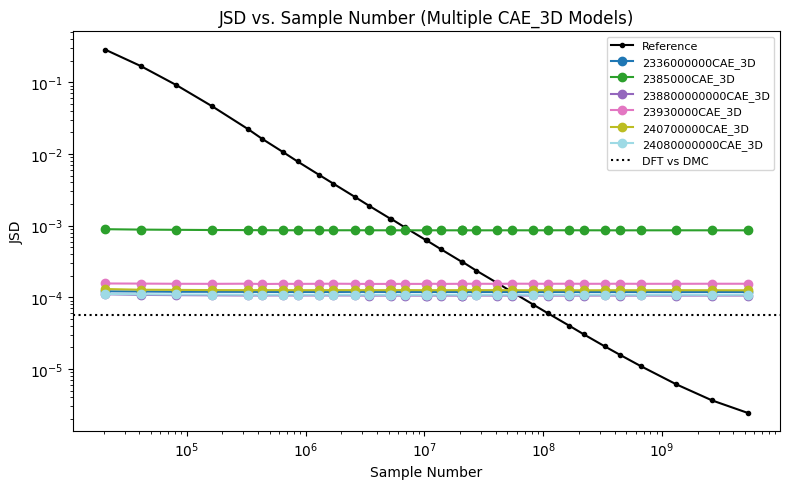

In [15]:
# === Plot ===
plt.figure(figsize=(8, 5))

# Plot reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot all CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
import glob
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py


# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/dmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_dmc_mix_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")





Found 33 noisy files.


In [21]:
import sys
import os
qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

ref_path = '/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5' #DFT
with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]

#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= ref_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    
print(model_results_FFT)

[(20488, np.float64(0.006953821724768818)), (40963, np.float64(0.0038959552275584057)), (81895, np.float64(0.001858427216930839)), (163804, np.float64(0.0019085354847745966)), (327565, np.float64(0.001009498254475325)), (427938, np.float64(0.0005418261389285614)), (652279, np.float64(0.0004920695696081415)), (856341, np.float64(0.0003063891431852876)), (1305628, np.float64(0.0002690236578657221)), (1718334, np.float64(0.00019602132515872826)), (2600974, np.float64(0.0001369690721162883)), (3430082, np.float64(9.181469265332228e-05)), (5156914, np.float64(7.110105757031185e-05)), (5221839, np.float64(7.418354766595316e-05)), (6859080, np.float64(4.2575118390108004e-05)), (10306478, np.float64(3.636175678321775e-05)), (10460209, np.float64(3.428569405078004e-05)), (13716305, np.float64(2.7782589165820164e-05)), (20619634, np.float64(1.8876702016349827e-05)), (20928124, np.float64(2.1440155410986507e-05)), (27440029, np.float64(1.4593444773292156e-05)), (41261398, np.float64(1.05536149985

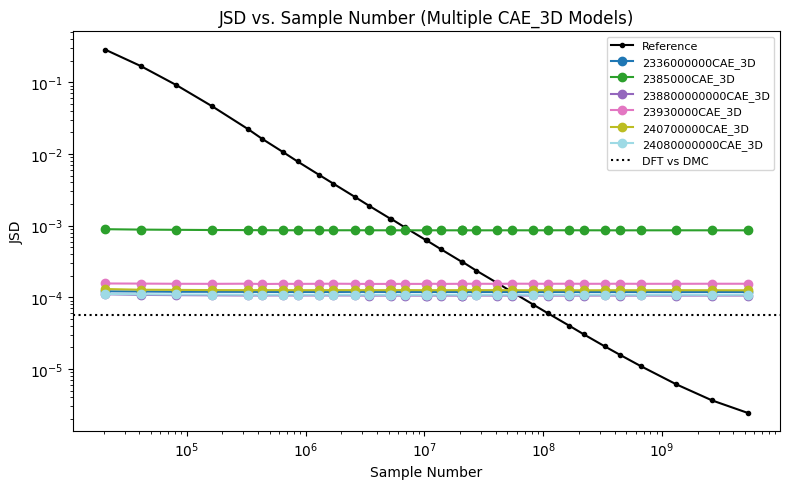

In [19]:
# === Plot ===
plt.figure(figsize=(8, 5))

# Plot reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot all CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.title("JSD vs. Sample Number (Multiple CAE_3D Models)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [23]:
import numpy as np

# Convert FFT results to a sorted numpy array
model_results_FFT.sort() # Sort by sample_num (the first element of the tuple)
fft_array = np.array(model_results_FFT)

# Assuming you ran a similar loop for BM4D:
# model_results_BM4D.sort()
# bm4d_array = np.array(model_results_BM4D)


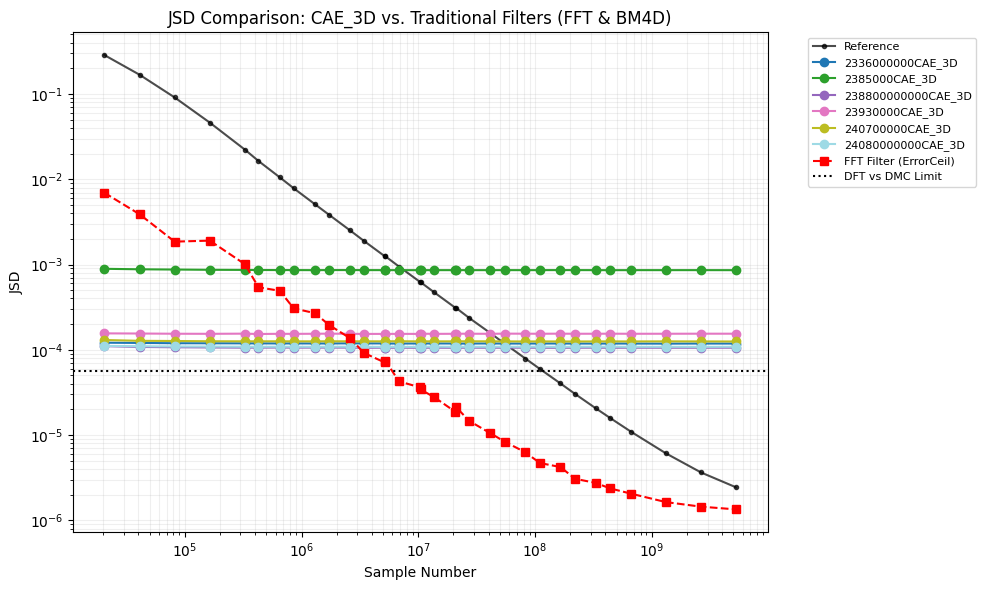

In [24]:
# === Plot ===
plt.figure(figsize=(10, 6)) # Slightly wider for more labels

# 1. Plot original Reference (DFT/DMC)
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference", alpha=0.7)

# 2. Plot all CAE_3D models (Your existing loop)
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

# 3. ADD THE FFT DATA
plt.loglog(fft_array[:, 0], fft_array[:, 1],
           marker="s", linestyle="--", color="red", label="FFT Filter (ErrorCeil)")

# 4. ADD THE BM4D DATA (If you have it)
if 'bm4d_array' in locals():
    plt.loglog(bm4d_array[:, 0], bm4d_array[:, 1],
               marker="D", linestyle="--", color="blue", label="BM4D Filter")

# Formatting
plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC Limit")
plt.title("JSD Comparison: CAE_3D vs. Traditional Filters (FFT & BM4D)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8) # Legend outside if it's too crowded
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()
